<a href="https://colab.research.google.com/github/sethkipsangmutuba/Comp-Graphics-Animation/blob/main/CBD4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ray Tracing

##Seth Kipsang

## 4.1 The Basic Ray-Tracing Algorithm

## 4.2 Perspective

## 4.3 Computing Viewing Rays

## 4.4 Ray-Object Intersection

## 4.5 Shading

## 4.6 A Ray-Tracing Program

## 4.7 Shadows

## 4.8 Ideal Specular Reflection

## 4.9 Historical Notes

# 4. Ray Tracing

## Definition

**Ray tracing** is a **3D rendering technique** that converts a scene containing **geometric objects** into a **2D raster image** from a specific viewpoint.

---

## Rendering Concept

Rendering determines how **3D objects contribute to 2D pixels**. Two general approaches are:

### 1. Object-Order Rendering

- **Processes each object first.**
- Determines which pixels are affected by that object.
- Updates the affected pixels.

### 2. Image-Order Rendering

- **Processes each pixel first.**
- Determines which objects affect that pixel.
- Computes the pixel's final color.

---

## Ray Tracing as Image-Order Rendering

**Ray tracing processes an image pixel by pixel:**

1. **Generate a ray** from the camera through a pixel.
2. **Trace the ray** into the 3D scene.
3. **Find the nearest object** intersected by the ray.
4. **Determine the visible surface.**
5. **Compute the pixel's color.**

---

## Engineering Significance

Ray tracing naturally supports realistic effects such as **shadows and reflections**, making it powerful for **realistic rendering**, although it can require **substantial computational effort**.

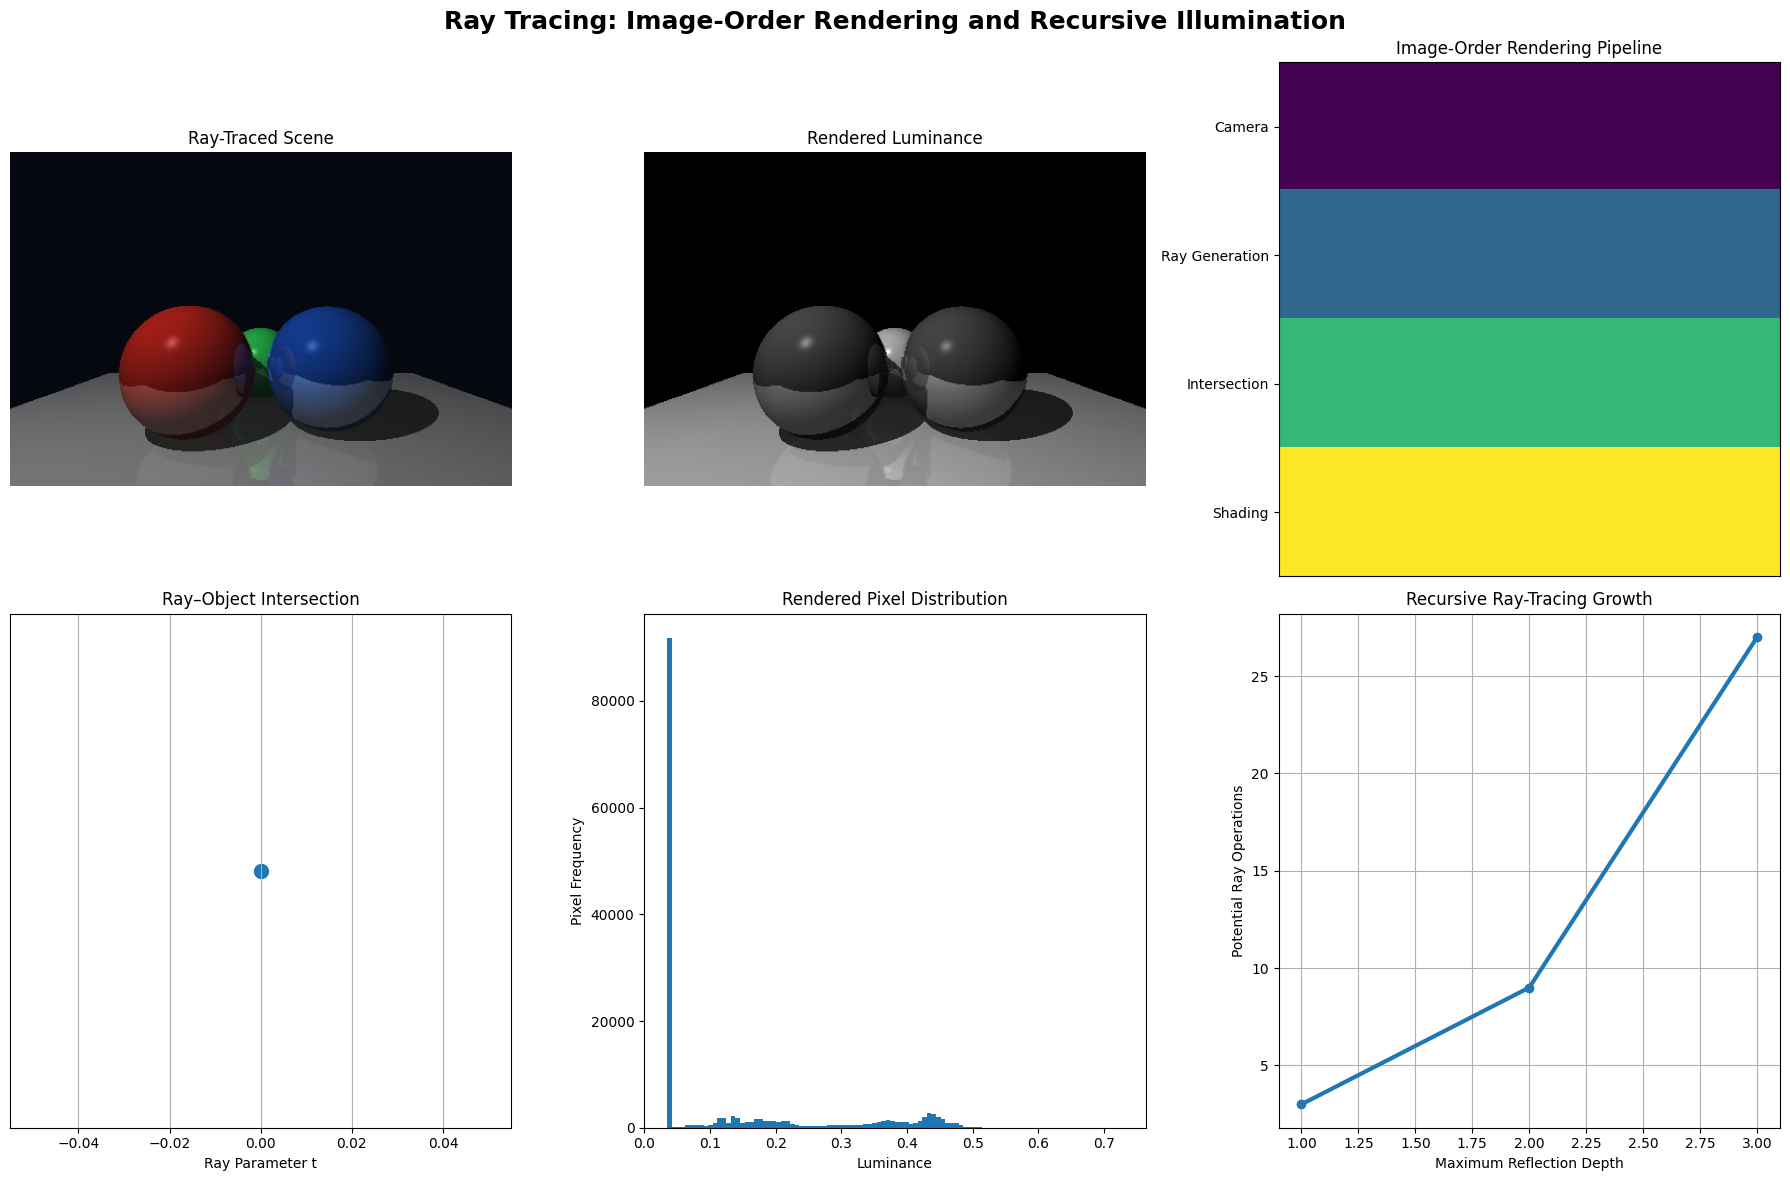

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Ray Tracing: Image-Order Rendering
# ==========================================================

WIDTH, HEIGHT = 480, 320
FOV = np.radians(60)
MAX_DEPTH = 2
EPSILON = 1e-4

camera = np.array([0.0, 0.8, 4.5])

objects = [
    {
        "center": np.array([-1.1, 0.0, 0.0]),
        "radius": 1.0,
        "color": np.array([0.85, 0.15, 0.10]),
        "reflectivity": 0.35
    },
    {
        "center": np.array([1.1, 0.0, -0.3]),
        "radius": 1.0,
        "color": np.array([0.10, 0.35, 0.85]),
        "reflectivity": 0.45
    },
    {
        "center": np.array([0.0, -0.15, -1.8]),
        "radius": 0.75,
        "color": np.array([0.15, 0.75, 0.30]),
        "reflectivity": 0.25
    }
]

light_position = np.array([-3.0, 5.0, 4.0])
light_color = np.ones(3)

# ==========================================================
# Geometry
# ==========================================================

def normalize(v):
    return v / np.linalg.norm(v)


def ray_sphere_intersection(origin, direction, sphere):
    oc = origin - sphere["center"]

    a = np.dot(direction, direction)
    b = 2.0 * np.dot(oc, direction)
    c = np.dot(oc, oc) - sphere["radius"] ** 2

    discriminant = b * b - 4 * a * c

    if discriminant < 0:
        return None

    sqrt_d = np.sqrt(discriminant)

    t1 = (-b - sqrt_d) / (2 * a)
    t2 = (-b + sqrt_d) / (2 * a)

    distances = [t for t in (t1, t2) if t > EPSILON]

    return min(distances) if distances else None


def intersect_scene(origin, direction):
    closest = np.inf
    hit_object = None

    for obj in objects:

        t = ray_sphere_intersection(
            origin,
            direction,
            obj
        )

        if t is not None and t < closest:
            closest = t
            hit_object = obj

    # Ground plane: y = -1
    if abs(direction[1]) > EPSILON:

        t_plane = (-1.0 - origin[1]) / direction[1]

        if EPSILON < t_plane < closest:

            point = origin + t_plane * direction

            if abs(point[0]) < 5 and -5 < point[2] < 3:

                hit_object = {
                    "center": None,
                    "radius": None,
                    "color": np.array([0.55, 0.55, 0.55]),
                    "reflectivity": 0.20,
                    "plane": True
                }

                closest = t_plane

    if hit_object is None:
        return None

    point = origin + closest * direction

    if hit_object.get("plane", False):
        normal = np.array([0.0, 1.0, 0.0])
    else:
        normal = normalize(
            point - hit_object["center"]
        )

    return closest, point, normal, hit_object


# ==========================================================
# Shadow Computation
# ==========================================================

def is_shadowed(point):
    to_light = light_position - point
    distance = np.linalg.norm(to_light)

    direction = normalize(to_light)

    origin = point + direction * EPSILON

    for obj in objects:

        t = ray_sphere_intersection(
            origin,
            direction,
            obj
        )

        if t is not None and t < distance:
            return True

    return False


# ==========================================================
# Ray Tracing
# ==========================================================

def trace_ray(origin, direction, depth=0):

    hit = intersect_scene(origin, direction)

    if hit is None:
        return np.array([0.025, 0.035, 0.06])

    _, point, normal, obj = hit

    base_color = obj["color"]

    # Ambient illumination
    ambient = 0.12 * base_color

    # Lighting direction
    light_direction = normalize(
        light_position - point
    )

    diffuse_strength = max(
        np.dot(normal, light_direction),
        0.0
    )

    # Shadow
    shadow = is_shadowed(point)

    if shadow:
        diffuse_strength *= 0.20

    diffuse = (
        diffuse_strength *
        base_color *
        light_color
    )

    # Specular reflection
    view_direction = normalize(
        camera - point
    )

    reflected_light = normalize(
        2 * normal *
        np.dot(normal, light_direction)
        - light_direction
    )

    specular_strength = max(
        np.dot(view_direction, reflected_light),
        0.0
    ) ** 64

    specular = 0.35 * specular_strength

    local_color = ambient + diffuse + specular

    # Recursive reflection
    reflectivity = obj["reflectivity"]

    if depth < MAX_DEPTH and reflectivity > 0:

        reflection_direction = normalize(
            direction -
            2 * np.dot(direction, normal) * normal
        )

        reflection_origin = (
            point +
            reflection_direction * EPSILON
        )

        reflected_color = trace_ray(
            reflection_origin,
            reflection_direction,
            depth + 1
        )

        local_color = (
            (1 - reflectivity) * local_color +
            reflectivity * reflected_color
        )

    return np.clip(local_color, 0, 1)


# ==========================================================
# Camera Ray Generation
# ==========================================================

aspect_ratio = WIDTH / HEIGHT

focal_length = 1 / np.tan(FOV / 2)

x = np.linspace(
    -aspect_ratio,
    aspect_ratio,
    WIDTH
)

y = np.linspace(
    1,
    -1,
    HEIGHT
)

xx, yy = np.meshgrid(x, y)

directions = np.stack(
    (
        xx,
        yy,
        -focal_length * np.ones_like(xx)
    ),
    axis=-1
)

directions /= np.linalg.norm(
    directions,
    axis=-1,
    keepdims=True
)

# ==========================================================
# Primary Ray Image
# ==========================================================

image = np.zeros(
    (HEIGHT, WIDTH, 3)
)

for row in range(HEIGHT):

    for col in range(WIDTH):

        image[row, col] = trace_ray(
            camera,
            directions[row, col]
        )

# ==========================================================
# Rendering Diagnostics
# ==========================================================

luminance = (
    0.2126 * image[:, :, 0] +
    0.7152 * image[:, :, 1] +
    0.0722 * image[:, :, 2]
)

# ==========================================================
# Ray–Sphere Intersection Demonstration
# ==========================================================

origin_demo = camera
direction_demo = normalize(
    np.array([0.0, 0.0, -1.0])
)

intersection_distances = []

for obj in objects:

    t = ray_sphere_intersection(
        origin_demo,
        direction_demo,
        obj
    )

    if t is not None:
        intersection_distances.append(t)

intersection_distances = (
    intersection_distances
    if intersection_distances
    else [0]
)

# ==========================================================
# Three Subplots per Row
# ==========================================================

fig = plt.figure(figsize=(18, 12))

# ----------------------------------------------------------
# 1. Rendered Image
# ----------------------------------------------------------

ax1 = plt.subplot(2, 3, 1)

ax1.imshow(image)

ax1.set_title(
    "Ray-Traced Scene"
)

ax1.axis("off")

# ----------------------------------------------------------
# 2. Luminance
# ----------------------------------------------------------

ax2 = plt.subplot(2, 3, 2)

ax2.imshow(
    luminance,
    cmap="gray"
)

ax2.set_title(
    "Rendered Luminance"
)

ax2.axis("off")

# ----------------------------------------------------------
# 3. Image-Order Pipeline
# ----------------------------------------------------------

ax3 = plt.subplot(2, 3, 3)

pipeline = np.array([
    [0.10, 0.10, 0.10],
    [0.35, 0.35, 0.35],
    [0.60, 0.60, 0.60],
    [0.85, 0.85, 0.85]
])

ax3.imshow(
    pipeline,
    aspect="auto"
)

ax3.set_yticks(
    range(4)
)

ax3.set_yticklabels([
    "Camera",
    "Ray Generation",
    "Intersection",
    "Shading"
])

ax3.set_xticks([])

ax3.set_title(
    "Image-Order Rendering Pipeline"
)

# ----------------------------------------------------------
# 4. Ray–Sphere Intersection
# ----------------------------------------------------------

ax4 = plt.subplot(2, 3, 4)

ax4.scatter(
    intersection_distances,
    np.zeros(len(intersection_distances)),
    s=100
)

ax4.set_xlabel(
    "Ray Parameter t"
)

ax4.set_yticks([])

ax4.set_title(
    "Ray–Object Intersection"
)

ax4.grid(True)

# ----------------------------------------------------------
# 5. Pixel Intensity Distribution
# ----------------------------------------------------------

ax5 = plt.subplot(2, 3, 5)

ax5.hist(
    luminance.ravel(),
    bins=100
)

ax5.set_xlabel(
    "Luminance"
)

ax5.set_ylabel(
    "Pixel Frequency"
)

ax5.set_title(
    "Rendered Pixel Distribution"
)

# ----------------------------------------------------------
# 6. Computational Structure
# ----------------------------------------------------------

ax6 = plt.subplot(2, 3, 6)

depths = np.arange(1, MAX_DEPTH + 2)

operations = 3 ** depths

ax6.plot(
    depths,
    operations,
    marker="o",
    linewidth=3
)

ax6.set_xlabel(
    "Maximum Reflection Depth"
)

ax6.set_ylabel(
    "Potential Ray Operations"
)

ax6.set_title(
    "Recursive Ray-Tracing Growth"
)

ax6.grid(True)

# ==========================================================
# Final Layout
# ==========================================================

plt.suptitle(
    "Ray Tracing: Image-Order Rendering and Recursive Illumination",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 4.1 The Basic Ray-Tracing Algorithm

### Definition

A **ray tracer** renders a **3D scene one pixel at a time**. For each pixel, it determines which object is visible along the **viewing ray from the camera**.

---

## Basic Principle

The **nearest object intersected by the ray is visible** because it blocks objects behind it.

---

## Three Main Stages

### 1. Ray Generation

- **Create a viewing ray for each pixel.**
- Determine the ray's **origin and direction** from the camera.

### 2. Ray Intersection

- **Test the ray against scene objects.**
- **Find the closest intersection.**
- Determine the **surface normal** at the intersection.

### 3. Shading

- Use the **intersection point, surface normal, and lighting information**.
- **Compute the final pixel color.**

---

## Basic Algorithm

```text
For each pixel:
    Generate viewing ray
    Find closest object intersected by ray
    Find surface normal
    Compute pixel color using shading
    Store pixel color


### **Core Concept**

**Ray Generation → Intersection → Shading**

This three-stage structure forms the foundation of a **basic ray-tracing system**.

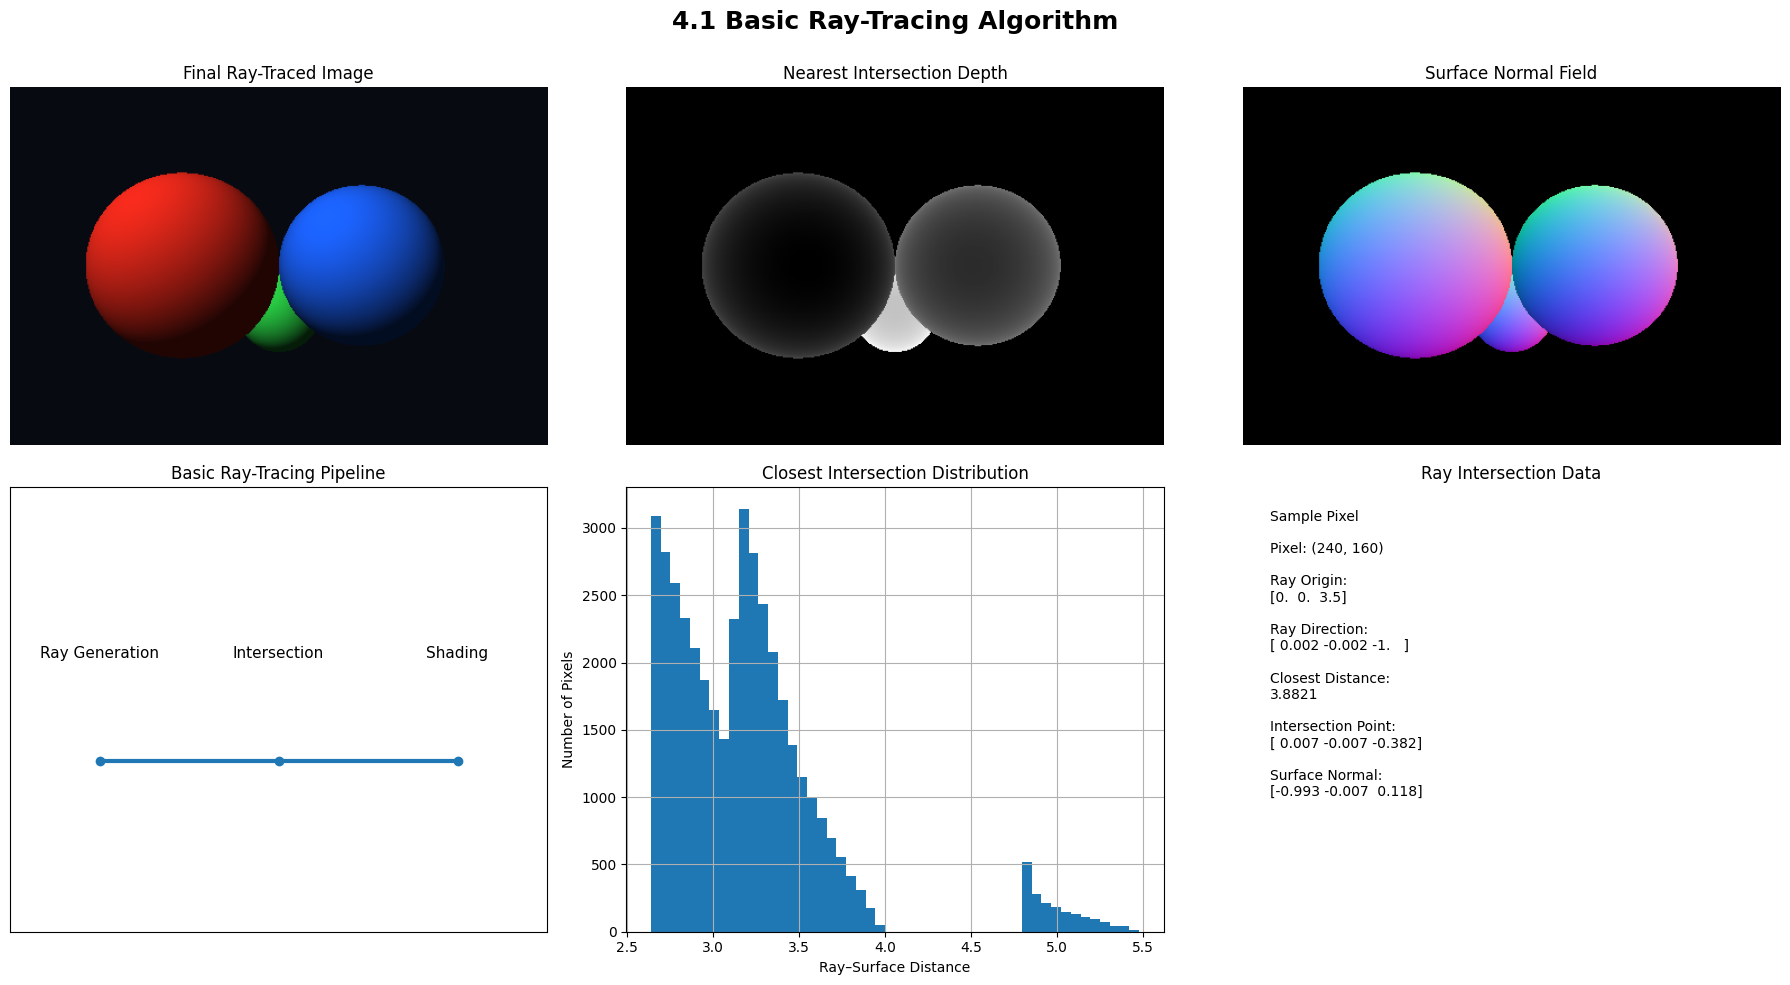

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 4.1 BASIC RAY-TRACING ALGORITHM
# Ray Generation → Intersection → Shading
# ==========================================================

WIDTH = 480
HEIGHT = 320

FOV = np.radians(60.0)
ASPECT = WIDTH / HEIGHT

CAMERA = np.array([0.0, 0.0, 3.5])

BACKGROUND = np.array([0.03, 0.04, 0.07])

LIGHT_POSITION = np.array([-3.0, 4.0, 5.0])
LIGHT_COLOR = np.ones(3)

EPSILON = 1e-5


# ==========================================================
# Scene
# ==========================================================

spheres = [
    {
        "center": np.array([-1.0, 0.0, 0.0]),
        "radius": 1.0,
        "color": np.array([0.85, 0.15, 0.10])
    },
    {
        "center": np.array([1.0, 0.0, -0.5]),
        "radius": 1.0,
        "color": np.array([0.10, 0.35, 0.90])
    },
    {
        "center": np.array([0.0, -0.75, -2.0]),
        "radius": 0.75,
        "color": np.array([0.15, 0.75, 0.25])
    }
]


# ==========================================================
# Vector Utilities
# ==========================================================

def normalize(vector):

    magnitude = np.linalg.norm(vector)

    if magnitude == 0:
        return vector

    return vector / magnitude


# ==========================================================
# Stage 1: Ray Generation
# ==========================================================

def generate_ray(pixel_x, pixel_y):

    screen_x = (
        (pixel_x + 0.5) / WIDTH * 2 - 1
    ) * ASPECT

    screen_y = (
        1 - (pixel_y + 0.5) / HEIGHT * 2
    )

    direction = np.array([
        screen_x,
        screen_y,
        -1 / np.tan(FOV / 2)
    ])

    direction = normalize(direction)

    return CAMERA, direction


# ==========================================================
# Stage 2: Ray-Sphere Intersection
# ==========================================================

def intersect_sphere(origin, direction, sphere):

    oc = origin - sphere["center"]

    a = np.dot(direction, direction)

    b = 2.0 * np.dot(oc, direction)

    c = (
        np.dot(oc, oc)
        - sphere["radius"] ** 2
    )

    discriminant = b**2 - 4*a*c

    if discriminant < 0:
        return None

    sqrt_discriminant = np.sqrt(discriminant)

    t1 = (
        -b - sqrt_discriminant
    ) / (2*a)

    t2 = (
        -b + sqrt_discriminant
    ) / (2*a)

    valid = [
        t for t in (t1, t2)
        if t > EPSILON
    ]

    if not valid:
        return None

    return min(valid)


def find_closest_intersection(origin, direction):

    closest_distance = np.inf
    closest_sphere = None

    for sphere in spheres:

        distance = intersect_sphere(
            origin,
            direction,
            sphere
        )

        if (
            distance is not None
            and distance < closest_distance
        ):

            closest_distance = distance
            closest_sphere = sphere

    if closest_sphere is None:
        return None

    point = (
        origin
        + closest_distance * direction
    )

    normal = normalize(
        point - closest_sphere["center"]
    )

    return (
        closest_distance,
        point,
        normal,
        closest_sphere
    )


# ==========================================================
# Stage 3: Shading
# ==========================================================

def shade(point, normal, sphere):

    light_direction = normalize(
        LIGHT_POSITION - point
    )

    diffuse = max(
        np.dot(normal, light_direction),
        0.0
    )

    ambient = 0.15

    color = sphere["color"] * (
        ambient + diffuse
    )

    return np.clip(
        color,
        0,
        1
    )


# ==========================================================
# Basic Ray Tracer
# ==========================================================

image = np.zeros(
    (HEIGHT, WIDTH, 3)
)

intersection_depth = np.zeros(
    (HEIGHT, WIDTH)
)

surface_normals = np.zeros(
    (HEIGHT, WIDTH, 3)
)

for y in range(HEIGHT):

    for x in range(WIDTH):

        # --------------------------------------------------
        # Stage 1: Ray Generation
        # --------------------------------------------------

        origin, direction = generate_ray(
            x,
            y
        )

        # --------------------------------------------------
        # Stage 2: Intersection
        # --------------------------------------------------

        hit = find_closest_intersection(
            origin,
            direction
        )

        # No object intersected
        if hit is None:

            image[y, x] = BACKGROUND

            continue

        distance, point, normal, sphere = hit

        intersection_depth[y, x] = distance

        surface_normals[y, x] = (
            normal + 1
        ) / 2

        # --------------------------------------------------
        # Stage 3: Shading
        # --------------------------------------------------

        image[y, x] = shade(
            point,
            normal,
            sphere
        )


# ==========================================================
# Normalize Depth for Visualization
# ==========================================================

depth_display = intersection_depth.copy()

valid_depth = depth_display > 0

if np.any(valid_depth):

    near = depth_display[valid_depth].min()
    far = depth_display[valid_depth].max()

    depth_display[valid_depth] = (
        depth_display[valid_depth] - near
    ) / (far - near + EPSILON)


# ==========================================================
# Pixel-Level Ray Demonstration
# ==========================================================

sample_x = WIDTH // 2
sample_y = HEIGHT // 2

sample_origin, sample_direction = generate_ray(
    sample_x,
    sample_y
)

sample_hit = find_closest_intersection(
    sample_origin,
    sample_direction
)


# ==========================================================
# Visualization
# ==========================================================

fig = plt.figure(figsize=(18, 10))

# ----------------------------------------------------------
# 1. Final Render
# ----------------------------------------------------------

ax1 = plt.subplot(2, 3, 1)

ax1.imshow(image)

ax1.set_title(
    "Final Ray-Traced Image"
)

ax1.axis("off")


# ----------------------------------------------------------
# 2. Intersection Depth
# ----------------------------------------------------------

ax2 = plt.subplot(2, 3, 2)

ax2.imshow(
    depth_display,
    cmap="gray"
)

ax2.set_title(
    "Nearest Intersection Depth"
)

ax2.axis("off")


# ----------------------------------------------------------
# 3. Surface Normals
# ----------------------------------------------------------

ax3 = plt.subplot(2, 3, 3)

ax3.imshow(
    surface_normals
)

ax3.set_title(
    "Surface Normal Field"
)

ax3.axis("off")


# ----------------------------------------------------------
# 4. Three-Stage Algorithm
# ----------------------------------------------------------

ax4 = plt.subplot(2, 3, 4)

stages = [
    "Ray Generation",
    "Intersection",
    "Shading"
]

values = [1, 2, 3]

ax4.plot(
    values,
    [1, 1, 1],
    marker="o",
    linewidth=3
)

for x, stage in zip(values, stages):

    ax4.text(
        x,
        1.03,
        stage,
        ha="center",
        fontsize=11
    )

ax4.set_xlim(0.5, 3.5)
ax4.set_ylim(0.95, 1.08)

ax4.set_xticks([])
ax4.set_yticks([])

ax4.set_title(
    "Basic Ray-Tracing Pipeline"
)

ax4.grid(False)


# ----------------------------------------------------------
# 5. Ray Intersection Distances
# ----------------------------------------------------------

ax5 = plt.subplot(2, 3, 5)

distances = intersection_depth[
    intersection_depth > 0
]

ax5.hist(
    distances,
    bins=50
)

ax5.set_xlabel(
    "Ray–Surface Distance"
)

ax5.set_ylabel(
    "Number of Pixels"
)

ax5.set_title(
    "Closest Intersection Distribution"
)

ax5.grid(True)


# ----------------------------------------------------------
# 6. Sample Ray Information
# ----------------------------------------------------------

ax6 = plt.subplot(2, 3, 6)

ax6.axis("off")

if sample_hit is not None:

    distance, point, normal, sphere = sample_hit

    information = (
        "Sample Pixel\n\n"
        f"Pixel: ({sample_x}, {sample_y})\n\n"
        f"Ray Origin:\n"
        f"{np.round(sample_origin, 3)}\n\n"
        f"Ray Direction:\n"
        f"{np.round(sample_direction, 3)}\n\n"
        f"Closest Distance:\n"
        f"{distance:.4f}\n\n"
        f"Intersection Point:\n"
        f"{np.round(point, 3)}\n\n"
        f"Surface Normal:\n"
        f"{np.round(normal, 3)}"
    )

else:

    information = (
        "Sample Pixel\n\n"
        "No object intersected."
    )

ax6.text(
    0.05,
    0.95,
    information,
    verticalalignment="top",
    fontsize=10
)

ax6.set_title(
    "Ray Intersection Data"
)


# ==========================================================
# Final Layout
# ==========================================================

plt.suptitle(
    "4.1 Basic Ray-Tracing Algorithm",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 4.2 Perspective

### Definition

**Perspective projection** is a method of representing a **3D scene as a 2D image** so that objects appear **smaller as their distance from the viewpoint increases**. It produces a **natural-looking representation** similar to human vision and photography.

---

## 1. Parallel Projection

**Projection lines are parallel** as they travel from the 3D scene to the image plane.

### Types

- **Orthographic**: Projection lines are perpendicular to the image plane.
- **Oblique**: Projection lines meet the image plane at an angle.

### Advantages

- **Parallel lines remain parallel.**
- **Preserves the size and shape** of objects parallel to the image plane.
- Useful in **engineering, mechanical, and architectural drawings**.

---

## 2. Perspective Projection

**Projection lines converge at a single viewpoint (camera/eye).**

### Key Characteristics

- **Objects farther away appear smaller.**
- **Parallel lines may appear to converge toward vanishing points.**
- Produces **natural-looking images**.
- Widely used in **computer graphics, photography, games, and animation**.

---

## **Core Concept**

**3D Scene → Projection → 2D Image**

- **Perspective**: projection toward a **single viewpoint**.
- **Parallel**: projection along **parallel directions**.

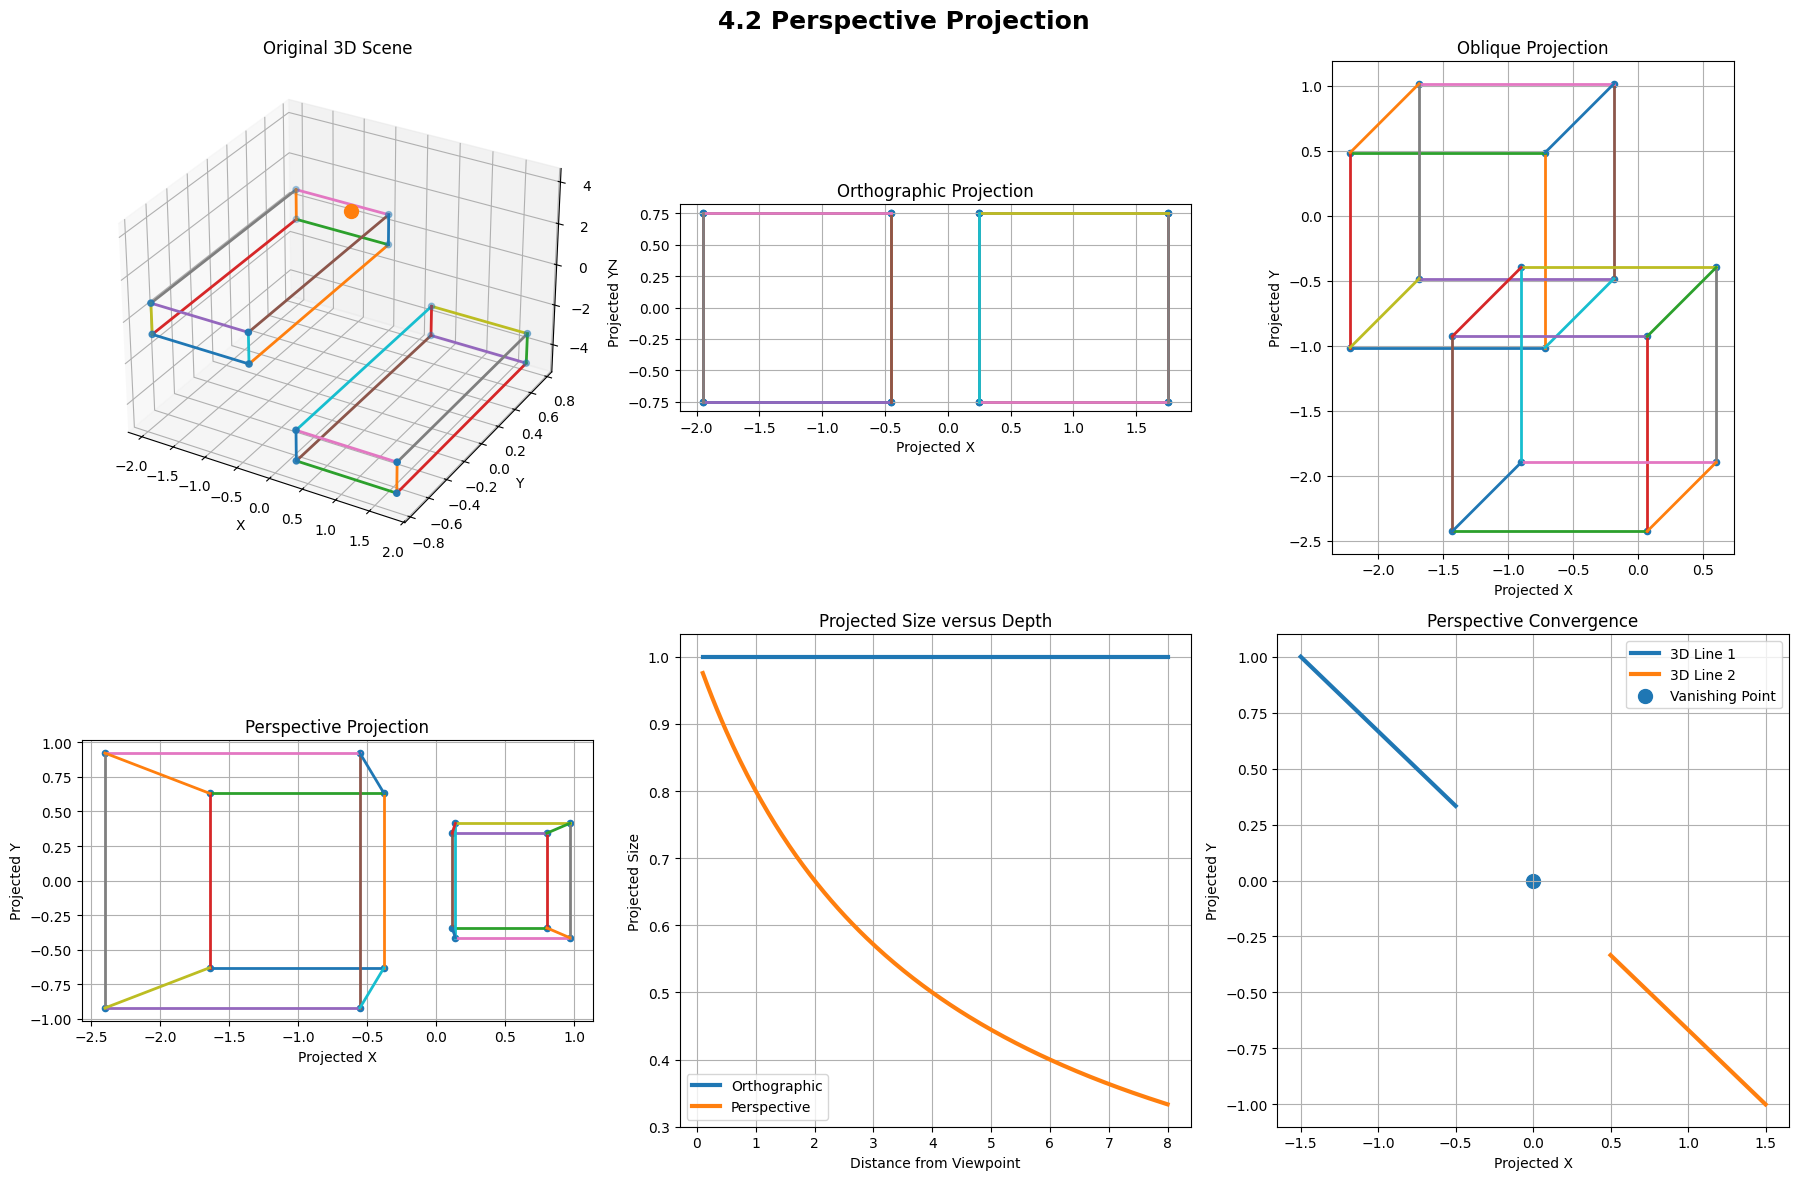

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 4.2 PERSPECTIVE PROJECTION
# Parallel, Orthographic, Oblique and Perspective Projection
# ==========================================================

# ----------------------------------------------------------
# 3D Cube
# ----------------------------------------------------------

def create_cube(center, size):

    x, y, z = center
    s = size / 2

    vertices = np.array([
        [x-s, y-s, z-s],
        [x+s, y-s, z-s],
        [x+s, y+s, z-s],
        [x-s, y+s, z-s],
        [x-s, y-s, z+s],
        [x+s, y-s, z+s],
        [x+s, y+s, z+s],
        [x-s, y+s, z+s]
    ])

    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7)
    ]

    return vertices, edges


near_cube, edges = create_cube(
    center=(-1.2, 0, 0),
    size=1.5
)

far_cube, _ = create_cube(
    center=(1.0, 0, -4),
    size=1.5
)

points_3d = np.vstack([
    near_cube,
    far_cube
])


# ==========================================================
# Projection Models
# ==========================================================

def orthographic_projection(points):

    return points[:, :2]


def oblique_projection(
    points,
    angle=45,
    depth_scale=0.5
):

    theta = np.radians(angle)

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    projected_x = (
        x + depth_scale * z * np.cos(theta)
    )

    projected_y = (
        y + depth_scale * z * np.sin(theta)
    )

    return np.column_stack([
        projected_x,
        projected_y
    ])


def perspective_projection(
    points,
    focal_length=4.0
):

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    depth = focal_length - z

    projected_x = (
        focal_length * x / depth
    )

    projected_y = (
        focal_length * y / depth
    )

    return np.column_stack([
        projected_x,
        projected_y
    ])


# ==========================================================
# Generate Projections
# ==========================================================

orthographic = orthographic_projection(
    points_3d
)

oblique = oblique_projection(
    points_3d
)

perspective = perspective_projection(
    points_3d
)


# ==========================================================
# Draw Projected Cubes
# ==========================================================

def draw_scene(
    ax,
    projected_points,
    title
):

    for offset in [0, 8]:

        for start, end in edges:

            p1 = projected_points[
                offset + start
            ]

            p2 = projected_points[
                offset + end
            ]

            ax.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                linewidth=2
            )

    ax.scatter(
        projected_points[:, 0],
        projected_points[:, 1],
        s=20
    )

    ax.set_title(title)

    ax.set_xlabel("Projected X")
    ax.set_ylabel("Projected Y")

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.grid(True)


# ==========================================================
# Perspective Scaling with Depth
# ==========================================================

depths = np.linspace(
    0.1,
    8,
    200
)

focal_length = 4.0
object_size = 1.0

perspective_size = (
    focal_length * object_size
    / (focal_length + depths)
)

orthographic_size = np.ones_like(
    depths
)


# ==========================================================
# Vanishing-Point Demonstration
# ==========================================================

z_values = np.linspace(
    -8,
    0,
    200
)

# Two parallel 3D lines.
# Both have constant x but different y values.

line_1 = np.column_stack([
    -1.5 * np.ones_like(z_values),
    1.0 * np.ones_like(z_values),
    z_values
])

line_2 = np.column_stack([
    1.5 * np.ones_like(z_values),
    -1.0 * np.ones_like(z_values),
    z_values
])

# Perspective projection of the two lines

perspective_line_1 = perspective_projection(
    line_1,
    focal_length
)

perspective_line_2 = perspective_projection(
    line_2,
    focal_length
)


# ==========================================================
# Visualization
# Three Subplots per Row
# ==========================================================

fig = plt.figure(
    figsize=(18, 12)
)


# ----------------------------------------------------------
# 1. Original 3D Scene
# ----------------------------------------------------------

ax1 = plt.subplot(
    2, 3, 1,
    projection="3d"
)

for cube in [near_cube, far_cube]:

    for start, end in edges:

        p1 = cube[start]
        p2 = cube[end]

        ax1.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            [p1[2], p2[2]],
            linewidth=2
        )

ax1.scatter(
    points_3d[:, 0],
    points_3d[:, 1],
    points_3d[:, 2],
    s=20
)

ax1.scatter(
    [0],
    [0],
    [4],
    s=100
)

ax1.set_title(
    "Original 3D Scene"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")


# ----------------------------------------------------------
# 2. Orthographic Projection
# ----------------------------------------------------------

ax2 = plt.subplot(
    2, 3, 2
)

draw_scene(
    ax2,
    orthographic,
    "Orthographic Projection"
)


# ----------------------------------------------------------
# 3. Oblique Projection
# ----------------------------------------------------------

ax3 = plt.subplot(
    2, 3, 3
)

draw_scene(
    ax3,
    oblique,
    "Oblique Projection"
)


# ----------------------------------------------------------
# 4. Perspective Projection
# ----------------------------------------------------------

ax4 = plt.subplot(
    2, 3, 4
)

draw_scene(
    ax4,
    perspective,
    "Perspective Projection"
)


# ----------------------------------------------------------
# 5. Object Size versus Depth
# ----------------------------------------------------------

ax5 = plt.subplot(
    2, 3, 5
)

ax5.plot(
    depths,
    orthographic_size,
    linewidth=3,
    label="Orthographic"
)

ax5.plot(
    depths,
    perspective_size,
    linewidth=3,
    label="Perspective"
)

ax5.set_xlabel(
    "Distance from Viewpoint"
)

ax5.set_ylabel(
    "Projected Size"
)

ax5.set_title(
    "Projected Size versus Depth"
)

ax5.legend()

ax5.grid(True)


# ----------------------------------------------------------
# 6. Perspective Convergence
# ----------------------------------------------------------

ax6 = plt.subplot(
    2, 3, 6
)

ax6.plot(
    perspective_line_1[:, 0],
    perspective_line_1[:, 1],
    linewidth=3,
    label="3D Line 1"
)

ax6.plot(
    perspective_line_2[:, 0],
    perspective_line_2[:, 1],
    linewidth=3,
    label="3D Line 2"
)

ax6.scatter(
    [0],
    [0],
    s=100,
    label="Vanishing Point"
)

ax6.set_xlabel(
    "Projected X"
)

ax6.set_ylabel(
    "Projected Y"
)

ax6.set_title(
    "Perspective Convergence"
)

ax6.legend()

ax6.grid(True)


# ==========================================================
# Final Layout
# ==========================================================

plt.suptitle(
    "4.2 Perspective Projection",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## **4.3 Computing Viewing Rays**

### **Core Concept**

A **viewing ray** represents the path from the camera viewpoint through a point on the image plane and into the 3D scene.

The basic components required are:

- **Viewpoint $e$** — the camera/eye position.
- **Image plane** — the plane through which the scene is viewed.
- **Point $s$** — a selected point on the image plane.
- **Ray direction** — the direction from $e$ toward $s$.

For parallel views, the **view direction** is used instead of a single viewpoint.

---

### **4.3.1 Mathematical Representation of a Viewing Ray**

A ray requires two things:

1. **Origin** — where the ray starts.
2. **Direction** — where the ray travels.

A 3D parametric line provides a convenient mathematical representation:

$$
p(t)=e+t(s-e)
$$

where:

- $p(t)$ = a point along the ray
- $e$ = ray origin/viewpoint
- $s$ = point on the image plane
- $s-e$ = ray direction
- $t$ = ray parameter

Thus,

$$
\text{Ray direction}=s-e
$$

The expression $s-e$ tells us how to move from the viewpoint toward the image-plane point.

---

### **4.3.2 Meaning of the Parameter $t$**

The parameter $t$ controls the position along the ray.

Starting from:

$$
p(t)=e+t(s-e)
$$

#### **At $t=0$**

Substitute $t=0$:

$$
p(0)=e+0(s-e)
$$

$$
p(0)=e
$$

Therefore:

$$
p(0)=e
$$

The ray is at its **origin**, the viewpoint.

---

#### **At $t=1$**

Substitute $t=1$:

$$
p(1)=e+1(s-e)
$$

Distribute:

$$
p(1)=e+s-e
$$

Cancel $e-e$:

$$
p(1)=s
$$

The ray therefore reaches the **image-plane point**.

---

### **4.3.3 Geometric Meaning of $0<t<1$**

For a value such as $t=0.5$:

$$
p(0.5)=e+0.5(s-e)
$$

This gives the point **halfway between $e$ and $s$**.

Generally:

$$
0<t<1
$$

means the point lies **between the viewpoint and the image plane**.

For $t>1$, the ray continues **beyond the image plane into the scene**.

---

### **Key Relationship**

$$
p(0)=e
$$

and

$$
p(1)=s
$$

Therefore, the equation

$$
p(t)=e+t(s-e)
$$

provides the **mathematical foundation for generating viewing rays in ray tracing**.

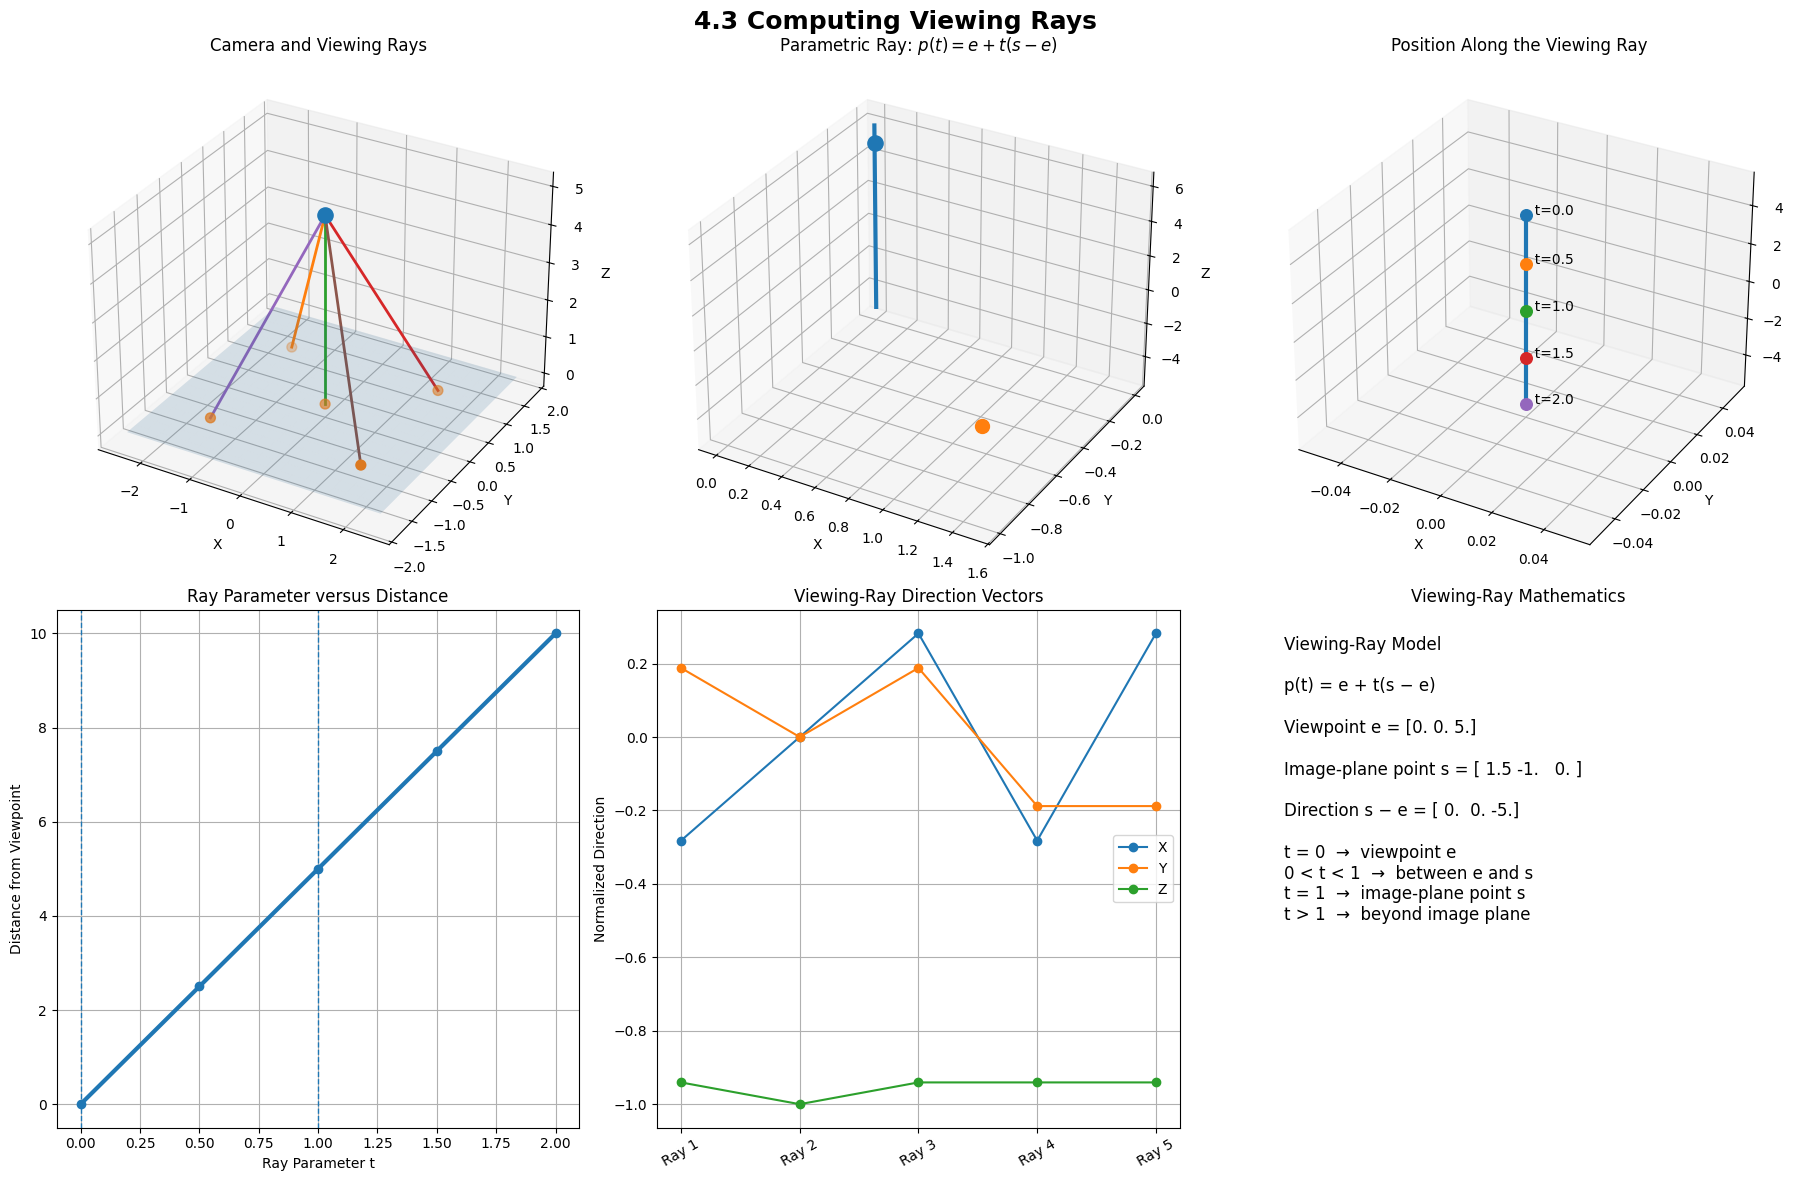

VIEWING-RAY VERIFICATION

Viewpoint e:
[0. 0. 5.]

Selected image-plane point s:
[ 1.5 -1.   0. ]

Ray direction s - e:
[ 0.  0. -5.]

Parametric points:
t = 0.0  p(t) = [0. 0. 5.]
t = 0.5  p(t) = [0.  0.  2.5]
t = 1.0  p(t) = [0. 0. 0.]
t = 1.5  p(t) = [ 0.   0.  -2.5]
t = 2.0  p(t) = [ 0.  0. -5.]


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 4.3 COMPUTING VIEWING RAYS
# p(t) = e + t(s - e)
# ==========================================================

# ----------------------------------------------------------
# Camera / Viewpoint
# ----------------------------------------------------------

e = np.array([0.0, 0.0, 5.0])

# Image plane: z = 0
image_plane_z = 0.0

# Selected points on the image plane
s_points = np.array([
    [-1.5,  1.0, image_plane_z],
    [ 0.0,  0.0, image_plane_z],
    [ 1.5,  1.0, image_plane_z],
    [-1.5, -1.0, image_plane_z],
    [ 1.5, -1.0, image_plane_z]
])


# ==========================================================
# Viewing-Ray Construction
# ==========================================================

def viewing_ray(e, s):
    direction = s - e
    return e, direction


def ray_point(e, direction, t):
    return e + t * direction


# ==========================================================
# Generate Viewing Rays
# ==========================================================

rays = []

for s in s_points:

    origin, direction = viewing_ray(e, s)

    rays.append({
        "origin": origin,
        "direction": direction,
        "image_point": s
    })


# ==========================================================
# Direction Normalization
# ==========================================================

normalized_directions = []

for ray in rays:

    direction = ray["direction"]

    normalized_direction = (
        direction /
        np.linalg.norm(direction)
    )

    normalized_directions.append(
        normalized_direction
    )

normalized_directions = np.array(
    normalized_directions
)


# ==========================================================
# Demonstrate t Values
# ==========================================================

s = s_points[1]

origin, direction = viewing_ray(e, s)

t_values = [
    0.0,
    0.5,
    1.0,
    1.5,
    2.0
]

points_t = np.array([
    ray_point(
        origin,
        direction,
        t
    )
    for t in t_values
])


# ==========================================================
# 3D Visualization
# ==========================================================

fig = plt.figure(
    figsize=(18, 12)
)

# ----------------------------------------------------------
# 1. Camera, Image Plane and Viewing Rays
# ----------------------------------------------------------

ax1 = plt.subplot(
    2, 3, 1,
    projection="3d"
)

# Image plane
xx, yy = np.meshgrid(
    np.linspace(-2.5, 2.5, 20),
    np.linspace(-1.8, 1.8, 20)
)

zz = np.zeros_like(xx)

ax1.plot_surface(
    xx,
    yy,
    zz,
    alpha=0.15
)

# Camera
ax1.scatter(
    e[0],
    e[1],
    e[2],
    s=120
)

# Image-plane points
ax1.scatter(
    s_points[:, 0],
    s_points[:, 1],
    s_points[:, 2],
    s=50
)

# Viewing rays
for ray in rays:

    s = ray["image_point"]

    ax1.plot(
        [e[0], s[0]],
        [e[1], s[1]],
        [e[2], s[2]],
        linewidth=2
    )

ax1.set_title(
    "Camera and Viewing Rays"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")


# ----------------------------------------------------------
# 2. Parametric Ray
# ----------------------------------------------------------

ax2 = plt.subplot(
    2, 3, 2,
    projection="3d"
)

# Extended ray
t_plot = np.linspace(
    -0.2,
    2.0,
    100
)

ray_points = np.array([
    ray_point(
        origin,
        direction,
        t
    )
    for t in t_plot
])

ax2.plot(
    ray_points[:, 0],
    ray_points[:, 1],
    ray_points[:, 2],
    linewidth=3
)

ax2.scatter(
    e[0],
    e[1],
    e[2],
    s=120
)

ax2.scatter(
    s[0],
    s[1],
    s[2],
    s=100
)

ax2.set_title(
    r"Parametric Ray: $p(t)=e+t(s-e)$"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")


# ----------------------------------------------------------
# 3. Meaning of t
# ----------------------------------------------------------

ax3 = plt.subplot(
    2, 3, 3,
    projection="3d"
)

ax3.plot(
    points_t[:, 0],
    points_t[:, 1],
    points_t[:, 2],
    linewidth=3
)

for point, t in zip(
    points_t,
    t_values
):

    ax3.scatter(
        point[0],
        point[1],
        point[2],
        s=70
    )

    ax3.text(
        point[0],
        point[1],
        point[2],
        f"  t={t}",
        fontsize=10
    )

ax3.set_title(
    "Position Along the Viewing Ray"
)

ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")


# ----------------------------------------------------------
# 4. Parameter t and Distance
# ----------------------------------------------------------

ax4 = plt.subplot(2, 3, 4)

distances = [
    np.linalg.norm(
        point - e
    )
    for point in points_t
]

ax4.plot(
    t_values,
    distances,
    marker="o",
    linewidth=3
)

ax4.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax4.axvline(
    1,
    linestyle="--",
    linewidth=1
)

ax4.set_xlabel(
    "Ray Parameter t"
)

ax4.set_ylabel(
    "Distance from Viewpoint"
)

ax4.set_title(
    "Ray Parameter versus Distance"
)

ax4.grid(True)


# ----------------------------------------------------------
# 5. Direction Components
# ----------------------------------------------------------

ax5 = plt.subplot(2, 3, 5)

components = normalized_directions

labels = [
    "Ray 1",
    "Ray 2",
    "Ray 3",
    "Ray 4",
    "Ray 5"
]

x = np.arange(
    len(labels)
)

ax5.plot(
    x,
    components[:, 0],
    marker="o",
    label="X"
)

ax5.plot(
    x,
    components[:, 1],
    marker="o",
    label="Y"
)

ax5.plot(
    x,
    components[:, 2],
    marker="o",
    label="Z"
)

ax5.set_xticks(x)

ax5.set_xticklabels(
    labels,
    rotation=30
)

ax5.set_ylabel(
    "Normalized Direction"
)

ax5.set_title(
    "Viewing-Ray Direction Vectors"
)

ax5.legend()

ax5.grid(True)


# ----------------------------------------------------------
# 6. Mathematical Summary
# ----------------------------------------------------------

ax6 = plt.subplot(2, 3, 6)

ax6.axis("off")

summary = (
    "Viewing-Ray Model\n\n"
    "p(t) = e + t(s − e)\n\n"
    f"Viewpoint e = {np.round(e, 2)}\n\n"
    f"Image-plane point s = {np.round(s, 2)}\n\n"
    f"Direction s − e = "
    f"{np.round(direction, 2)}\n\n"
    "t = 0  →  viewpoint e\n"
    "0 < t < 1  →  between e and s\n"
    "t = 1  →  image-plane point s\n"
    "t > 1  →  beyond image plane"
)

ax6.text(
    0.05,
    0.95,
    summary,
    verticalalignment="top",
    fontsize=12
)

ax6.set_title(
    "Viewing-Ray Mathematics"
)


# ==========================================================
# Final Layout
# ==========================================================

plt.suptitle(
    "4.3 Computing Viewing Rays",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ==========================================================
# Numerical Verification
# ==========================================================

print("VIEWING-RAY VERIFICATION")
print("=" * 60)

print("\nViewpoint e:")
print(e)

print("\nSelected image-plane point s:")
print(s)

print("\nRay direction s - e:")
print(direction)

print("\nParametric points:")

for t, point in zip(
    t_values,
    points_t
):

    print(
        f"t = {t:3.1f}  "
        f"p(t) = {np.round(point, 4)}"
    )

## **4.3.1 Orthographic Views**

### **Core Concept**

In an **orthographic view**, all viewing rays are **parallel** and have the same direction:

$$
d=-w
$$

Unlike perspective projection, the rays do not converge at a single viewpoint.

---

### **Camera Coordinate Frame**

The camera uses three perpendicular unit vectors:

- $u$ = horizontal/right direction
- $v$ = vertical/up direction
- $w$ = camera viewing direction
- $e$ = origin/reference point of the camera frame
- $d$ = direction of a viewing ray

The **ray-starting plane** is defined by $e$, $u$, and $v$.

---

### **Image Boundaries**

The image is defined by four boundaries:

- $l$ = left edge
- $r$ = right edge
- $b$ = bottom edge
- $t$ = top edge

The boundaries are measured from $e$:

- $l,r$ are measured along $u$
- $b,t$ are measured along $v$

Usually:

$$
l<0<r,\qquad b<0<t
$$

Thus, an image point has coordinates:

$$
(u,v)
$$

where:

- $u$ = horizontal position within the image
- $v$ = vertical position within the image

with:

$$
l\leq u\leq r
$$

$$
b\leq v\leq t
$$

---

### **Ray Origin**

For an image position $(u,v)$, the ray starts at:

$$
o=e+uu+vv
$$

where:

- $o$ = origin of the particular viewing ray
- $e$ = camera-frame origin
- $uu$ = horizontal displacement
- $vv$ = vertical displacement

---

### **Ray Direction**

Every orthographic ray has the **same direction**:

$$
d=-w
$$

Therefore, the complete ray is:

$$
p(s)=o+sd
$$

Substituting $o$ and $d$:

$$
p(s)=e+uu+vv-sw
$$

where:

- $p(s)$ = point along the viewing ray
- $s$ = distance/parameter along the ray
- $s\geq0$ = movement from the ray origin into the scene

---

### **Essential Relationship**

$$
\text{Different }(u,v)
\rightarrow
\text{Different ray origins}
\rightarrow
\text{Same direction }-w
$$

**Therefore, orthographic projection is characterized by parallel viewing rays.**

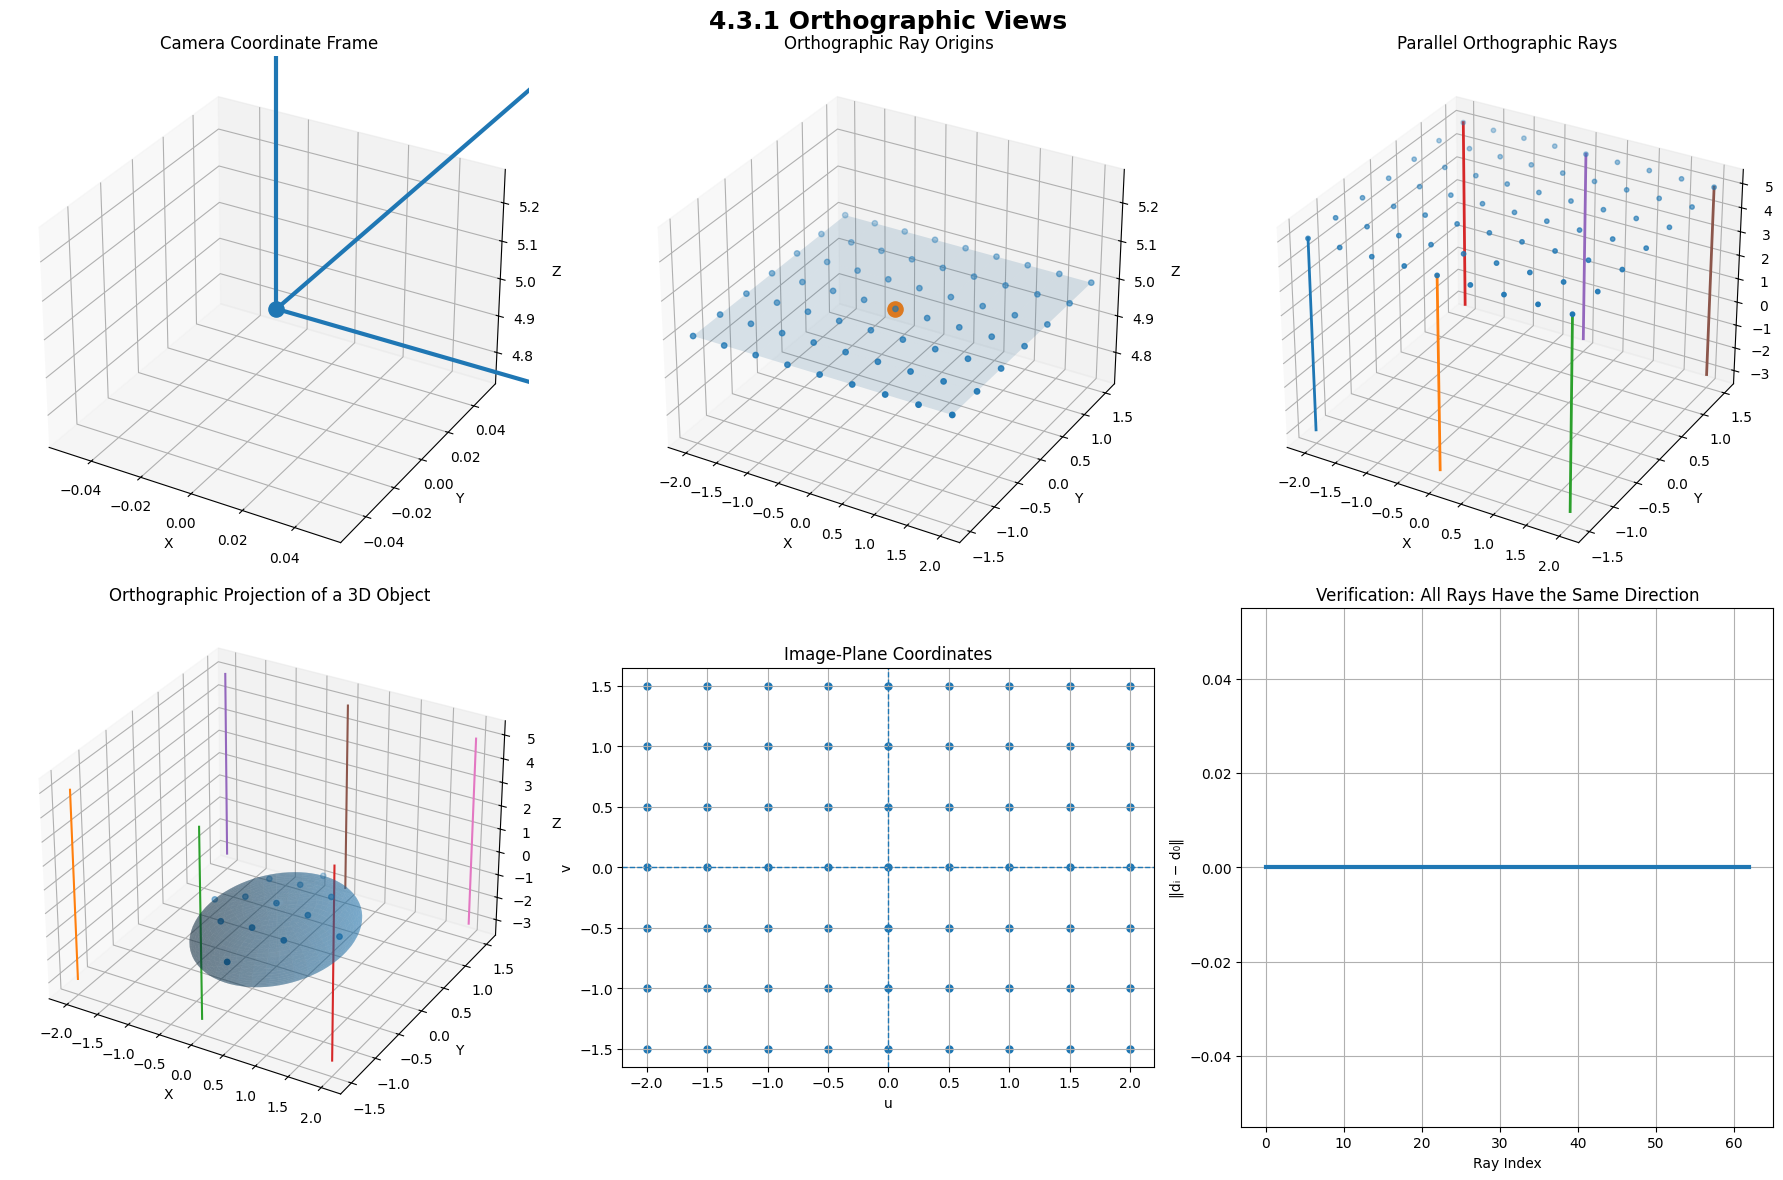

ORTHOGRAPHIC VIEW VERIFICATION

Camera origin e:
[0. 0. 5.]

Camera basis vectors:
u = [1. 0. 0.]
v = [0. 1. 0.]
w = [0. 0. 1.]

Ray direction:
d = -w = [-0. -0. -1.]

Image boundaries:
l = -2.0, r = 2.0
b = -1.5, t = 1.5

Number of rays:
63

Camera-frame orthogonality matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Maximum difference between ray directions:
0.000000000000

Conclusion:
All viewing rays are parallel and have the identical direction d = -w.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 4.3.1 ORTHOGRAPHIC VIEWS
#
# Ray:
#     p(s) = o + s d
#
# Origin:
#     o = e + u*u_hat + v*v_hat
#
# Direction:
#     d = -w_hat
# ==========================================================

# ----------------------------------------------------------
# Camera Coordinate Frame
# ----------------------------------------------------------

e = np.array([0.0, 0.0, 5.0])

u_hat = np.array([1.0, 0.0, 0.0])   # Camera right
v_hat = np.array([0.0, 1.0, 0.0])   # Camera up
w_hat = np.array([0.0, 0.0, 1.0])   # Camera viewing reference

d = -w_hat                           # Common ray direction


# ==========================================================
# Verify Orthonormal Camera Frame
# ==========================================================

camera_frame = np.array([
    u_hat,
    v_hat,
    w_hat
])

orthogonality = camera_frame @ camera_frame.T


# ==========================================================
# Image Boundaries
# ==========================================================

left = -2.0
right = 2.0

bottom = -1.5
top = 1.5

# Image-plane resolution
nx = 9
ny = 7

u_values = np.linspace(
    left,
    right,
    nx
)

v_values = np.linspace(
    bottom,
    top,
    ny
)


# ==========================================================
# Generate Orthographic Ray Origins
# ==========================================================

ray_origins = []
ray_directions = []

for v in v_values:

    for u in u_values:

        # o = e + u*u_hat + v*v_hat

        origin = (
            e
            + u * u_hat
            + v * v_hat
        )

        ray_origins.append(origin)
        ray_directions.append(d)

ray_origins = np.array(ray_origins)
ray_directions = np.array(ray_directions)


# ==========================================================
# Generate Ray Paths
# ==========================================================

s_values = np.linspace(
    0,
    8,
    100
)

ray_paths = []

selected_indices = [
    0,
    nx // 2,
    nx - 1,
    (ny - 1) * nx,
    (ny - 1) * nx + nx // 2,
    (ny - 1) * nx + nx - 1
]

for index in selected_indices:

    origin = ray_origins[index]

    path = np.array([
        origin + s * d
        for s in s_values
    ])

    ray_paths.append(path)


# ==========================================================
# 3D Scene for Intersection Demonstration
# ==========================================================

sphere_center = np.array([
    0.0,
    0.0,
    -2.0
])

sphere_radius = 1.1


# ==========================================================
# Ray-Sphere Intersection
# ==========================================================

def ray_sphere_intersection(
    origin,
    direction,
    center,
    radius
):

    oc = origin - center

    a = np.dot(
        direction,
        direction
    )

    b = 2 * np.dot(
        oc,
        direction
    )

    c = (
        np.dot(oc, oc)
        - radius ** 2
    )

    discriminant = (
        b ** 2
        - 4 * a * c
    )

    if discriminant < 0:
        return None

    sqrt_discriminant = np.sqrt(
        discriminant
    )

    t1 = (
        -b - sqrt_discriminant
    ) / (2 * a)

    t2 = (
        -b + sqrt_discriminant
    ) / (2 * a)

    valid = [
        t for t in (t1, t2)
        if t >= 0
    ]

    if not valid:
        return None

    return min(valid)


# ==========================================================
# Calculate Visible Intersections
# ==========================================================

intersection_points = []

for origin in ray_origins:

    s = ray_sphere_intersection(
        origin,
        d,
        sphere_center,
        sphere_radius
    )

    if s is not None:

        intersection = (
            origin + s * d
        )

        intersection_points.append(
            intersection
        )

intersection_points = np.array(
    intersection_points
)


# ==========================================================
# Visualization
# Three Subplots per Row
# ==========================================================

fig = plt.figure(
    figsize=(18, 12)
)


# ----------------------------------------------------------
# 1. Camera Coordinate Frame
# ----------------------------------------------------------

ax1 = plt.subplot(
    2, 3, 1,
    projection="3d"
)

ax1.scatter(
    *e,
    s=120
)

ax1.quiver(
    *e,
    *u_hat,
    length=1.5,
    linewidth=3
)

ax1.quiver(
    *e,
    *v_hat,
    length=1.5,
    linewidth=3
)

ax1.quiver(
    *e,
    *w_hat,
    length=1.5,
    linewidth=3
)

ax1.text(
    *(e + 1.6 * u_hat),
    "u"
)

ax1.text(
    *(e + 1.6 * v_hat),
    "v"
)

ax1.text(
    *(e + 1.6 * w_hat),
    "w"
)

ax1.set_title(
    "Camera Coordinate Frame"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")


# ----------------------------------------------------------
# 2. Image Plane and Ray Origins
# ----------------------------------------------------------

ax2 = plt.subplot(
    2, 3, 2,
    projection="3d"
)

xx, yy = np.meshgrid(
    u_values,
    v_values
)

zz = np.full_like(
    xx,
    e[2]
)

ax2.plot_surface(
    xx,
    yy,
    zz,
    alpha=0.15
)

ax2.scatter(
    ray_origins[:, 0],
    ray_origins[:, 1],
    ray_origins[:, 2],
    s=15
)

ax2.scatter(
    *e,
    s=120
)

ax2.set_title(
    "Orthographic Ray Origins"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")


# ----------------------------------------------------------
# 3. Parallel Viewing Rays
# ----------------------------------------------------------

ax3 = plt.subplot(
    2, 3, 3,
    projection="3d"
)

for path in ray_paths:

    ax3.plot(
        path[:, 0],
        path[:, 1],
        path[:, 2],
        linewidth=2
    )

ax3.scatter(
    ray_origins[:, 0],
    ray_origins[:, 1],
    ray_origins[:, 2],
    s=10
)

ax3.set_title(
    "Parallel Orthographic Rays"
)

ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")


# ----------------------------------------------------------
# 4. Ray-Sphere Intersection
# ----------------------------------------------------------

ax4 = plt.subplot(
    2, 3, 4,
    projection="3d"
)

# Sphere
phi = np.linspace(
    0,
    np.pi,
    40
)

theta = np.linspace(
    0,
    2 * np.pi,
    80
)

sphere_x = (
    sphere_center[0]
    + sphere_radius
    * np.outer(
        np.sin(phi),
        np.cos(theta)
    )
)

sphere_y = (
    sphere_center[1]
    + sphere_radius
    * np.outer(
        np.sin(phi),
        np.sin(theta)
    )
)

sphere_z = (
    sphere_center[2]
    + sphere_radius
    * np.outer(
        np.cos(phi),
        np.ones_like(theta)
    )
)

ax4.plot_surface(
    sphere_x,
    sphere_y,
    sphere_z,
    alpha=0.35
)

for path in ray_paths:

    ax4.plot(
        path[:, 0],
        path[:, 1],
        path[:, 2],
        linewidth=1.5
    )

if len(intersection_points) > 0:

    ax4.scatter(
        intersection_points[:, 0],
        intersection_points[:, 1],
        intersection_points[:, 2],
        s=15
    )

ax4.set_title(
    "Orthographic Projection of a 3D Object"
)

ax4.set_xlabel("X")
ax4.set_ylabel("Y")
ax4.set_zlabel("Z")


# ----------------------------------------------------------
# 5. Image Coordinates (u,v)
# ----------------------------------------------------------

ax5 = plt.subplot(
    2, 3, 5
)

U, V = np.meshgrid(
    u_values,
    v_values
)

ax5.scatter(
    U.ravel(),
    V.ravel(),
    s=25
)

ax5.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax5.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax5.set_xlabel("u")
ax5.set_ylabel("v")

ax5.set_title(
    "Image-Plane Coordinates"
)

ax5.set_aspect(
    "equal"
)

ax5.grid(True)


# ----------------------------------------------------------
# 6. Direction Consistency
# ----------------------------------------------------------

ax6 = plt.subplot(
    2, 3, 6
)

direction_variation = np.linalg.norm(
    ray_directions - ray_directions[0],
    axis=1
)

ax6.plot(
    direction_variation,
    linewidth=3
)

ax6.set_xlabel(
    "Ray Index"
)

ax6.set_ylabel(
    "‖dᵢ − d₀‖"
)

ax6.set_title(
    "Verification: All Rays Have the Same Direction"
)

ax6.grid(True)


# ==========================================================
# Final Layout
# ==========================================================

plt.suptitle(
    "4.3.1 Orthographic Views",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ==========================================================
# Numerical Verification
# ==========================================================

print("=" * 65)
print("ORTHOGRAPHIC VIEW VERIFICATION")
print("=" * 65)

print("\nCamera origin e:")
print(e)

print("\nCamera basis vectors:")
print("u =", u_hat)
print("v =", v_hat)
print("w =", w_hat)

print("\nRay direction:")
print("d = -w =", d)

print("\nImage boundaries:")
print(f"l = {left}, r = {right}")
print(f"b = {bottom}, t = {top}")

print("\nNumber of rays:")
print(len(ray_origins))

print("\nCamera-frame orthogonality matrix:")
print(
    np.round(
        orthogonality,
        4
    )
)

print(
    "\nMaximum difference between ray directions:"
)

print(
    f"{np.max(direction_variation):.12f}"
)

print(
    "\nConclusion:"
)

if np.max(direction_variation) < 1e-12:

    print(
        "All viewing rays are parallel and have "
        "the identical direction d = -w."
    )

else:

    print(
        "Ray directions are not identical."
    )

## **4.3.2 Perspective Views**

### **Core Concept**

In a **perspective view**, all viewing rays begin at the **same viewpoint**, but each pixel has a **different ray direction**.

This is the key difference from orthographic projection:

$$
\text{Perspective: same origin, different directions}
$$

---

### **Perspective Camera Setup**

The main components are:

- $e$ = **viewpoint/eye position**, where all rays originate
- $u$ = **horizontal camera direction**
- $v$ = **vertical camera direction**
- $w$ = **camera viewing direction**
- $d$ = **image-plane distance**
- $u$ = **horizontal position of the pixel on the image plane**
- $v$ = **vertical position of the pixel on the image plane**

Unlike orthographic projection, the image plane is **not located at $e$**. It is placed a distance $d$ in front of the viewpoint.

---

### **Image-Plane Distance $d$**

The distance

$$
d
$$

is called the **image-plane distance**.

It is often loosely called the **focal length** because changing $d$ has a similar effect to changing the focal length of a real camera.

---

### **Computing the Ray Direction**

For a pixel at image coordinates $(u,v)$, the viewing-ray direction is:

$$
\text{ray.direction}=-dw+uu+vv
$$

The three terms have clear meanings:

$$
-dw
$$

moves the ray forward toward the image plane,

$$
uu
$$

moves it horizontally according to the pixel's $u$-coordinate,

and

$$
vv
$$

moves it vertically according to the pixel's $v$-coordinate.

Thus:

$$
\text{Ray direction}
=
\text{forward component}
+
\text{horizontal component}
+
\text{vertical component}
$$

---

### **Ray Origin**

Every perspective ray starts at the **same viewpoint**:

$$
\text{ray.origin}=e
$$

Therefore:

$$
\text{Ray origin}=e,\qquad
\text{Ray direction}=-dw+uu+vv
$$

---

### **Perspective vs Orthographic**

| Projection | Ray Origin | Ray Direction |
|---|---|---|
| **Orthographic** | Different for each pixel | Same |
| **Perspective** | Same $e$ | Different for each pixel |

So:

$$
\text{Orthographic: different origins, same direction}
$$

$$
\text{Perspective: same origin, different directions}
$$

---

### **Oblique Perspective Views**

For an **oblique perspective view**, the image-plane normal and projection direction can be specified separately.

The term

$$
-dw
$$

is replaced by:

$$
dd
$$

where:

- $d$ = specified projection direction
- $d$ = image-plane distance

Thus the ray direction becomes:

$$
\text{ray.direction}=dd+uu+vv
$$

The fundamental perspective idea remains unchanged: **all rays originate from the same viewpoint, while their directions vary according to the pixel position.**

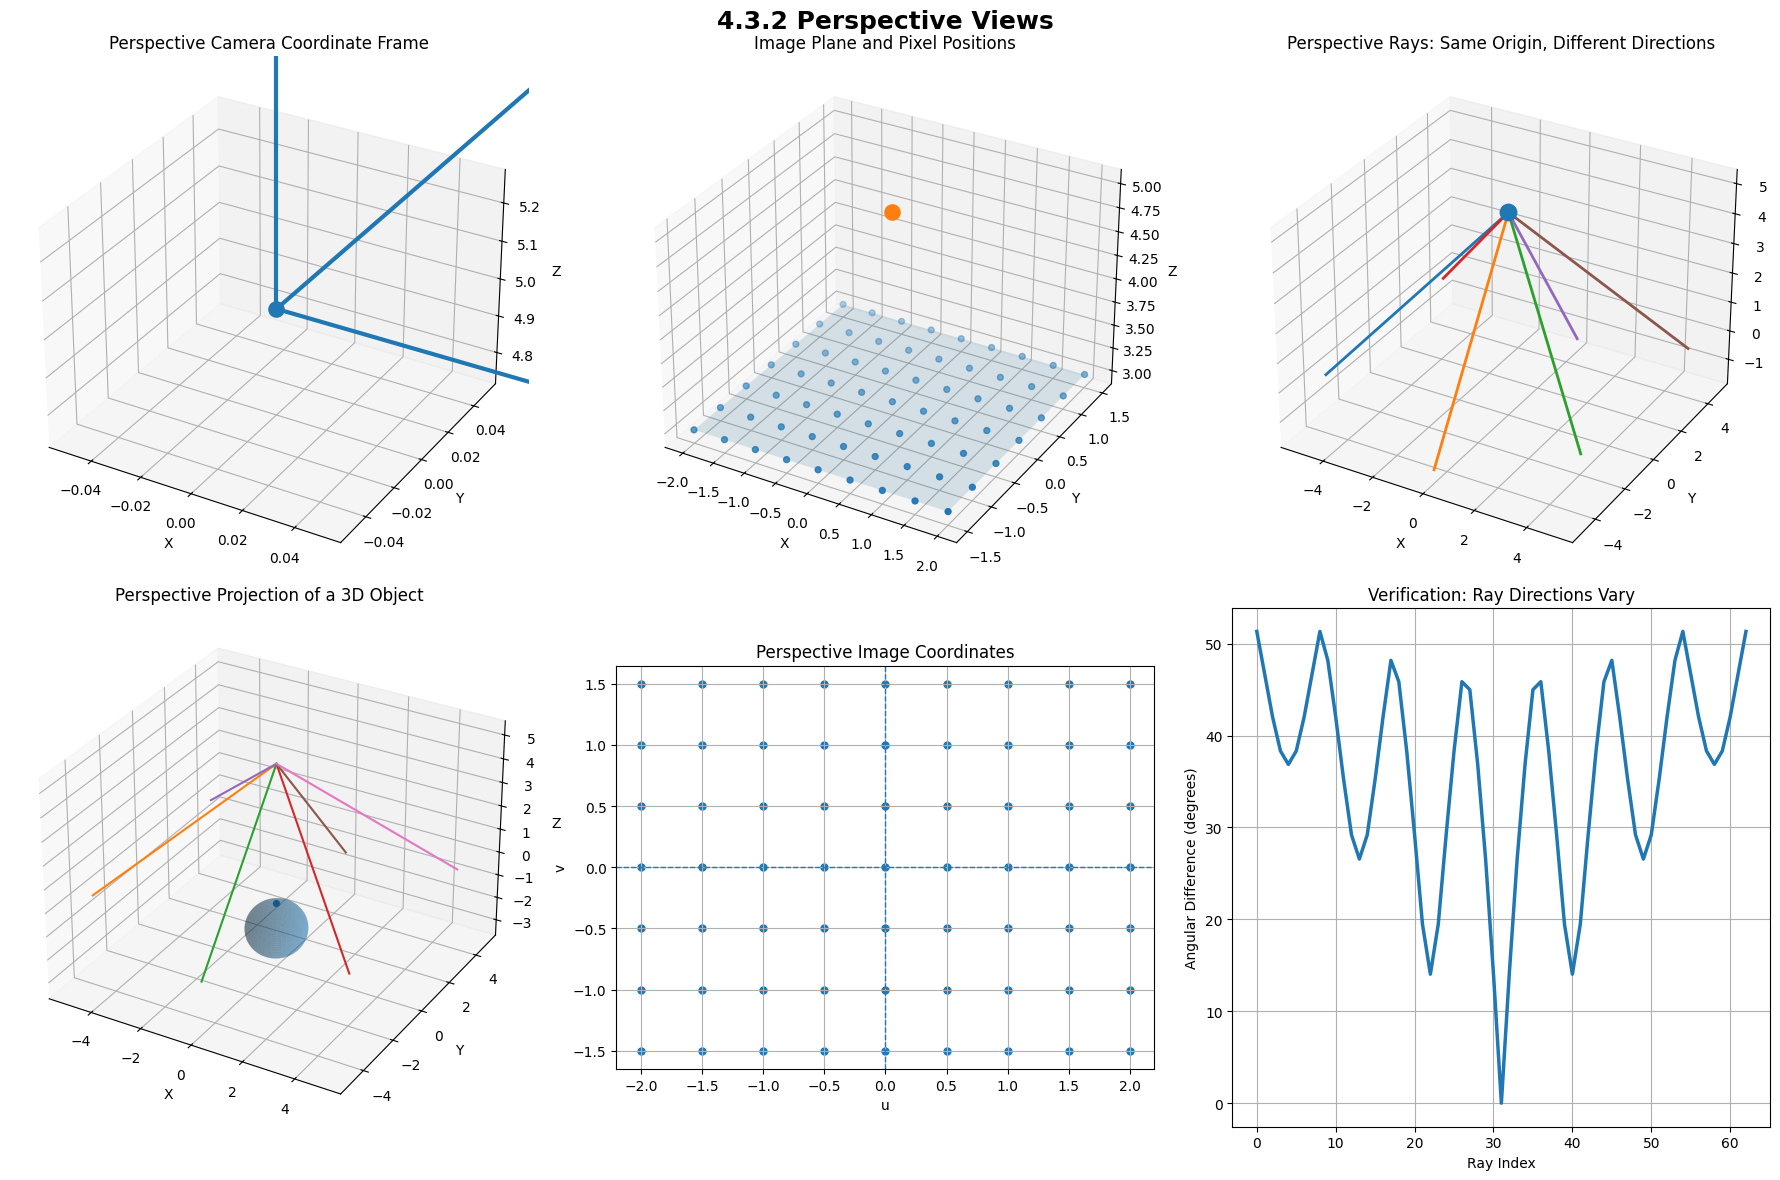

PERSPECTIVE VIEW VERIFICATION

Viewpoint e:
[0. 0. 5.]

Camera basis vectors:
u = [1. 0. 0.]
v = [0. 1. 0.]
w = [0. 0. 1.]

Image-plane distance:
f = 2.0

Image-plane center:
[0. 0. 3.]

Number of rays:
63

Maximum difference between ray origins:
0.000000000000

Maximum difference between normalized ray directions:
1.561737618886

Central ray direction:
[ 0.  0. -1.]

Corner ray direction:
[-0.6247 -0.4685 -0.6247]

CONCLUSION
Perspective projection verified:
• All rays originate at the same viewpoint e.
• Ray directions vary with image position (u, v).
• Perspective projection therefore produces converging viewing rays.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 4.3.2 PERSPECTIVE VIEWS
#
# Ray origin:
#     o = e
#
# Ray direction:
#     d = -f*w_hat + u*u_hat + v*v_hat
#
# Ray:
#     p(s) = e + s*d
# ==========================================================


# ----------------------------------------------------------
# Perspective Camera
# ----------------------------------------------------------

e = np.array([0.0, 0.0, 5.0])

u_hat = np.array([1.0, 0.0, 0.0])   # Camera right
v_hat = np.array([0.0, 1.0, 0.0])   # Camera up
w_hat = np.array([0.0, 0.0, 1.0])   # Camera viewing reference

focal_distance = 2.0


# ==========================================================
# Image-Plane Boundaries
# ==========================================================

left = -2.0
right = 2.0

bottom = -1.5
top = 1.5

nx = 9
ny = 7

u_values = np.linspace(
    left,
    right,
    nx
)

v_values = np.linspace(
    bottom,
    top,
    ny
)


# ==========================================================
# Image Plane
#
# The plane is located a distance f in front of e.
# ==========================================================

image_plane_center = (
    e - focal_distance * w_hat
)


U, V = np.meshgrid(
    u_values,
    v_values
)


# ==========================================================
# Image-Plane Points
# ==========================================================

image_points = np.array([
    image_plane_center
    + u * u_hat
    + v * v_hat
    for u, v in zip(
        U.ravel(),
        V.ravel()
    )
])


# ==========================================================
# Generate Perspective Rays
# ==========================================================

ray_origins = []
ray_directions = []

for point in image_points:

    origin = e

    direction = (
        point - e
    )

    ray_origins.append(
        origin
    )

    ray_directions.append(
        direction
    )

ray_origins = np.array(
    ray_origins
)

ray_directions = np.array(
    ray_directions
)


# ==========================================================
# Normalize Ray Directions
# ==========================================================

ray_directions_normalized = (
    ray_directions
    / np.linalg.norm(
        ray_directions,
        axis=1,
        keepdims=True
    )
)


# ==========================================================
# Generate Ray Paths
# ==========================================================

ray_paths = []

s_values = np.linspace(
    0,
    8,
    100
)

selected_indices = [
    0,
    nx // 2,
    nx - 1,
    (ny - 1) * nx,
    (ny - 1) * nx + nx // 2,
    (ny - 1) * nx + nx - 1
]

for index in selected_indices:

    origin = ray_origins[index]

    direction = (
        ray_directions_normalized[index]
    )

    path = np.array([
        origin + s * direction
        for s in s_values
    ])

    ray_paths.append(
        path
    )


# ==========================================================
# 3D Scene
# ==========================================================

sphere_center = np.array([
    0.0,
    0.0,
    -2.0
])

sphere_radius = 1.1


# ==========================================================
# Ray-Sphere Intersection
# ==========================================================

def ray_sphere_intersection(
    origin,
    direction,
    center,
    radius
):

    oc = origin - center

    a = np.dot(
        direction,
        direction
    )

    b = 2 * np.dot(
        oc,
        direction
    )

    c = (
        np.dot(oc, oc)
        - radius ** 2
    )

    discriminant = (
        b ** 2
        - 4 * a * c
    )

    if discriminant < 0:
        return None

    sqrt_discriminant = np.sqrt(
        discriminant
    )

    t1 = (
        -b - sqrt_discriminant
    ) / (2 * a)

    t2 = (
        -b + sqrt_discriminant
    ) / (2 * a)

    valid = [
        t
        for t in (t1, t2)
        if t >= 0
    ]

    if not valid:
        return None

    return min(valid)


# ==========================================================
# Calculate Visible Intersections
# ==========================================================

intersection_points = []

for origin, direction in zip(
    ray_origins,
    ray_directions_normalized
):

    s = ray_sphere_intersection(
        origin,
        direction,
        sphere_center,
        sphere_radius
    )

    if s is not None:

        intersection = (
            origin
            + s * direction
        )

        intersection_points.append(
            intersection
        )

intersection_points = np.array(
    intersection_points
)


# ==========================================================
# Visualization
# Three Subplots Per Row
# ==========================================================

fig = plt.figure(
    figsize=(18, 12)
)


# ----------------------------------------------------------
# 1. Perspective Camera Coordinate Frame
# ----------------------------------------------------------

ax1 = plt.subplot(
    2, 3, 1,
    projection="3d"
)

ax1.scatter(
    *e,
    s=120
)

ax1.quiver(
    *e,
    *u_hat,
    length=1.5,
    linewidth=3
)

ax1.quiver(
    *e,
    *v_hat,
    length=1.5,
    linewidth=3
)

ax1.quiver(
    *e,
    *w_hat,
    length=1.5,
    linewidth=3
)

ax1.text(
    *(e + 1.6 * u_hat),
    "u"
)

ax1.text(
    *(e + 1.6 * v_hat),
    "v"
)

ax1.text(
    *(e + 1.6 * w_hat),
    "w"
)

ax1.set_title(
    "Perspective Camera Coordinate Frame"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")


# ----------------------------------------------------------
# 2. Image Plane and Pixel Positions
# ----------------------------------------------------------

ax2 = plt.subplot(
    2, 3, 2,
    projection="3d"
)

xx, yy = np.meshgrid(
    u_values,
    v_values
)

zz = np.full_like(
    xx,
    image_plane_center[2]
)

ax2.plot_surface(
    xx,
    yy,
    zz,
    alpha=0.15
)

ax2.scatter(
    image_points[:, 0],
    image_points[:, 1],
    image_points[:, 2],
    s=18
)

ax2.scatter(
    *e,
    s=120
)

ax2.set_title(
    "Image Plane and Pixel Positions"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")


# ----------------------------------------------------------
# 3. Converging Perspective Rays
# ----------------------------------------------------------

ax3 = plt.subplot(
    2, 3, 3,
    projection="3d"
)

for path in ray_paths:

    ax3.plot(
        path[:, 0],
        path[:, 1],
        path[:, 2],
        linewidth=2
    )

ax3.scatter(
    *e,
    s=140
)

ax3.set_title(
    "Perspective Rays: Same Origin, Different Directions"
)

ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")


# ----------------------------------------------------------
# 4. Ray-Sphere Intersection
# ----------------------------------------------------------

ax4 = plt.subplot(
    2, 3, 4,
    projection="3d"
)

phi = np.linspace(
    0,
    np.pi,
    40
)

theta = np.linspace(
    0,
    2 * np.pi,
    80
)

sphere_x = (
    sphere_center[0]
    + sphere_radius
    * np.outer(
        np.sin(phi),
        np.cos(theta)
    )
)

sphere_y = (
    sphere_center[1]
    + sphere_radius
    * np.outer(
        np.sin(phi),
        np.sin(theta)
    )
)

sphere_z = (
    sphere_center[2]
    + sphere_radius
    * np.outer(
        np.cos(phi),
        np.ones_like(theta)
    )
)

ax4.plot_surface(
    sphere_x,
    sphere_y,
    sphere_z,
    alpha=0.35
)

for path in ray_paths:

    ax4.plot(
        path[:, 0],
        path[:, 1],
        path[:, 2],
        linewidth=1.5
    )

if len(intersection_points) > 0:

    ax4.scatter(
        intersection_points[:, 0],
        intersection_points[:, 1],
        intersection_points[:, 2],
        s=18
    )

ax4.set_title(
    "Perspective Projection of a 3D Object"
)

ax4.set_xlabel("X")
ax4.set_ylabel("Y")
ax4.set_zlabel("Z")


# ----------------------------------------------------------
# 5. Image Coordinates (u,v)
# ----------------------------------------------------------

ax5 = plt.subplot(
    2, 3, 5
)

ax5.scatter(
    U.ravel(),
    V.ravel(),
    s=25
)

ax5.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax5.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax5.set_xlabel("u")
ax5.set_ylabel("v")

ax5.set_title(
    "Perspective Image Coordinates"
)

ax5.set_aspect(
    "equal"
)

ax5.grid(True)


# ----------------------------------------------------------
# 6. Direction Variation
# ----------------------------------------------------------

ax6 = plt.subplot(
    2, 3, 6
)

direction_angles = []

reference = (
    ray_directions_normalized[
        len(ray_directions_normalized) // 2
    ]
)

for direction in ray_directions_normalized:

    cosine = np.clip(
        np.dot(
            reference,
            direction
        ),
        -1.0,
        1.0
    )

    angle = np.degrees(
        np.arccos(cosine)
    )

    direction_angles.append(
        angle
    )

direction_angles = np.array(
    direction_angles
)

ax6.plot(
    direction_angles,
    linewidth=2.5
)

ax6.set_xlabel(
    "Ray Index"
)

ax6.set_ylabel(
    "Angular Difference (degrees)"
)

ax6.set_title(
    "Verification: Ray Directions Vary"
)

ax6.grid(True)


# ==========================================================
# Final Layout
# ==========================================================

plt.suptitle(
    "4.3.2 Perspective Views",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ==========================================================
# Numerical Verification
# ==========================================================

print("=" * 65)
print("PERSPECTIVE VIEW VERIFICATION")
print("=" * 65)

print("\nViewpoint e:")
print(e)

print("\nCamera basis vectors:")
print("u =", u_hat)
print("v =", v_hat)
print("w =", w_hat)

print("\nImage-plane distance:")
print(
    f"f = {focal_distance}"
)

print("\nImage-plane center:")
print(
    image_plane_center
)

print("\nNumber of rays:")
print(
    len(ray_origins)
)


# ----------------------------------------------------------
# Verify common ray origin
# ----------------------------------------------------------

origin_variation = np.linalg.norm(
    ray_origins - ray_origins[0],
    axis=1
)

print(
    "\nMaximum difference between ray origins:"
)

print(
    f"{np.max(origin_variation):.12f}"
)


# ----------------------------------------------------------
# Verify different directions
# ----------------------------------------------------------

direction_difference = np.linalg.norm(
    ray_directions_normalized
    - ray_directions_normalized[0],
    axis=1
)

print(
    "\nMaximum difference between normalized "
    "ray directions:"
)

print(
    f"{np.max(direction_difference):.12f}"
)


# ----------------------------------------------------------
# Compare central and corner ray
# ----------------------------------------------------------

center_index = (
    (ny // 2) * nx
    + nx // 2
)

corner_index = 0

print(
    "\nCentral ray direction:"
)

print(
    np.round(
        ray_directions_normalized[
            center_index
        ],
        4
    )
)

print(
    "\nCorner ray direction:"
)

print(
    np.round(
        ray_directions_normalized[
            corner_index
        ],
        4
    )
)


# ==========================================================
# Final Mathematical Conclusion
# ==========================================================

print("\n" + "=" * 65)
print("CONCLUSION")
print("=" * 65)

if (
    np.max(origin_variation) < 1e-12
    and
    np.max(direction_difference) > 1e-6
):

    print(
        "Perspective projection verified:"
    )

    print(
        "• All rays originate at the same viewpoint e."
    )

    print(
        "• Ray directions vary with image position (u, v)."
    )

    print(
        "• Perspective projection therefore produces "
        "converging viewing rays."
    )

# **4.4.1 Ray-Sphere Intersection**

### **Core Concept**

To determine whether a ray intersects a sphere, we substitute the **ray equation into the sphere equation**.

Given:

$$
p(t)=e+td
$$

and an implicit surface:

$$
f(p)=0
$$

an intersection occurs when:

$$
f(p(t))=0
$$

Therefore:

$$
f(e+td)=0
$$

The unknown is $t$.

---

### **Sphere Equation**

A sphere has:

- $c=(x_c,y_c,z_c)$ = center
- $R$ = radius
- $p$ = any point on the sphere

The implicit sphere equation is:

$$
(x-x_c)^2+(y-y_c)^2+(z-z_c)^2-R^2=0
$$

In vector form:

$$
(p-c)\cdot(p-c)-R^2=0
$$

A point $p$ lies on the sphere exactly when this equation equals zero.

---

### **Substitute the Ray**

The ray is:

$$
p(t)=e+td
$$

Substitute this into the sphere equation:

$$
(e+td-c)\cdot(e+td-c)-R^2=0
$$

Rearranging gives:

$$
(d\cdot d)t^2+2d\cdot(e-c)t+(e-c)\cdot(e-c)-R^2=0
$$

This has the standard quadratic form:

$$
At^2+Bt+C=0
$$

where:

$$
A=d\cdot d
$$

$$
B=2d\cdot(e-c)
$$

$$
C=(e-c)\cdot(e-c)-R^2
$$

Thus, the geometric intersection problem has been converted into a **quadratic equation in $t$**.

---

### **Discriminant**

For:

$$
At^2+Bt+C=0
$$

the discriminant is:

$$
\Delta=B^2-4AC
$$

The value of $\Delta$ determines the intersection:

#### **1. $\Delta<0$**

$$
\Delta<0\Rightarrow\text{No real intersection}
$$

The ray **misses the sphere**.

#### **2. $\Delta=0$**

$$
\Delta=0\Rightarrow\text{One intersection}
$$

The ray just touches the sphere.

This is called a **tangent** or grazing intersection.

#### **3. $\Delta>0$**

$$
\Delta>0\Rightarrow\text{Two intersections}
$$

The ray enters the sphere at one point and leaves it at another.

---

### **Solving for $t$**

Using the quadratic formula:

$$
t=\frac{-B\pm\sqrt{B^2-4AC}}{2A}
$$

After substituting the sphere coefficients and simplifying:

$$
t=
\frac{
-d\cdot(e-c)
\pm
\sqrt{[d\cdot(e-c)]^2-(d\cdot d)[(e-c)\cdot(e-c)-R^2]}
}{
d\cdot d
}
$$

The two signs give the **two possible intersection values**.

For ray tracing, we select the **smallest valid $t$** satisfying the required interval, normally:

$$
t>0
$$

---

### **Surface Normal at the Intersection**

Once the intersection point $p$ is known, the sphere's normal vector is:

$$
n=2(p-c)
$$

The **unit normal** is:

$$
\hat{n}=\frac{p-c}{R}
$$

where:

- $n$ = surface normal
- $\hat{n}$ = unit normal
- $p$ = intersection point
- $c$ = sphere center
- $R$ = sphere radius

The normal is important because it is later used in **shading calculations**.

---

### **Ray-Sphere Process**

$$
\text{Ray}
\rightarrow
\text{Substitute into sphere equation}
\rightarrow
\text{Quadratic in }t
\rightarrow
\text{Discriminant}
\rightarrow
\text{Intersection}
\rightarrow
\text{Surface normal}
$$

The central idea is: **ray-sphere intersection converts a geometric problem into solving a quadratic equation for the ray parameter $t$.**

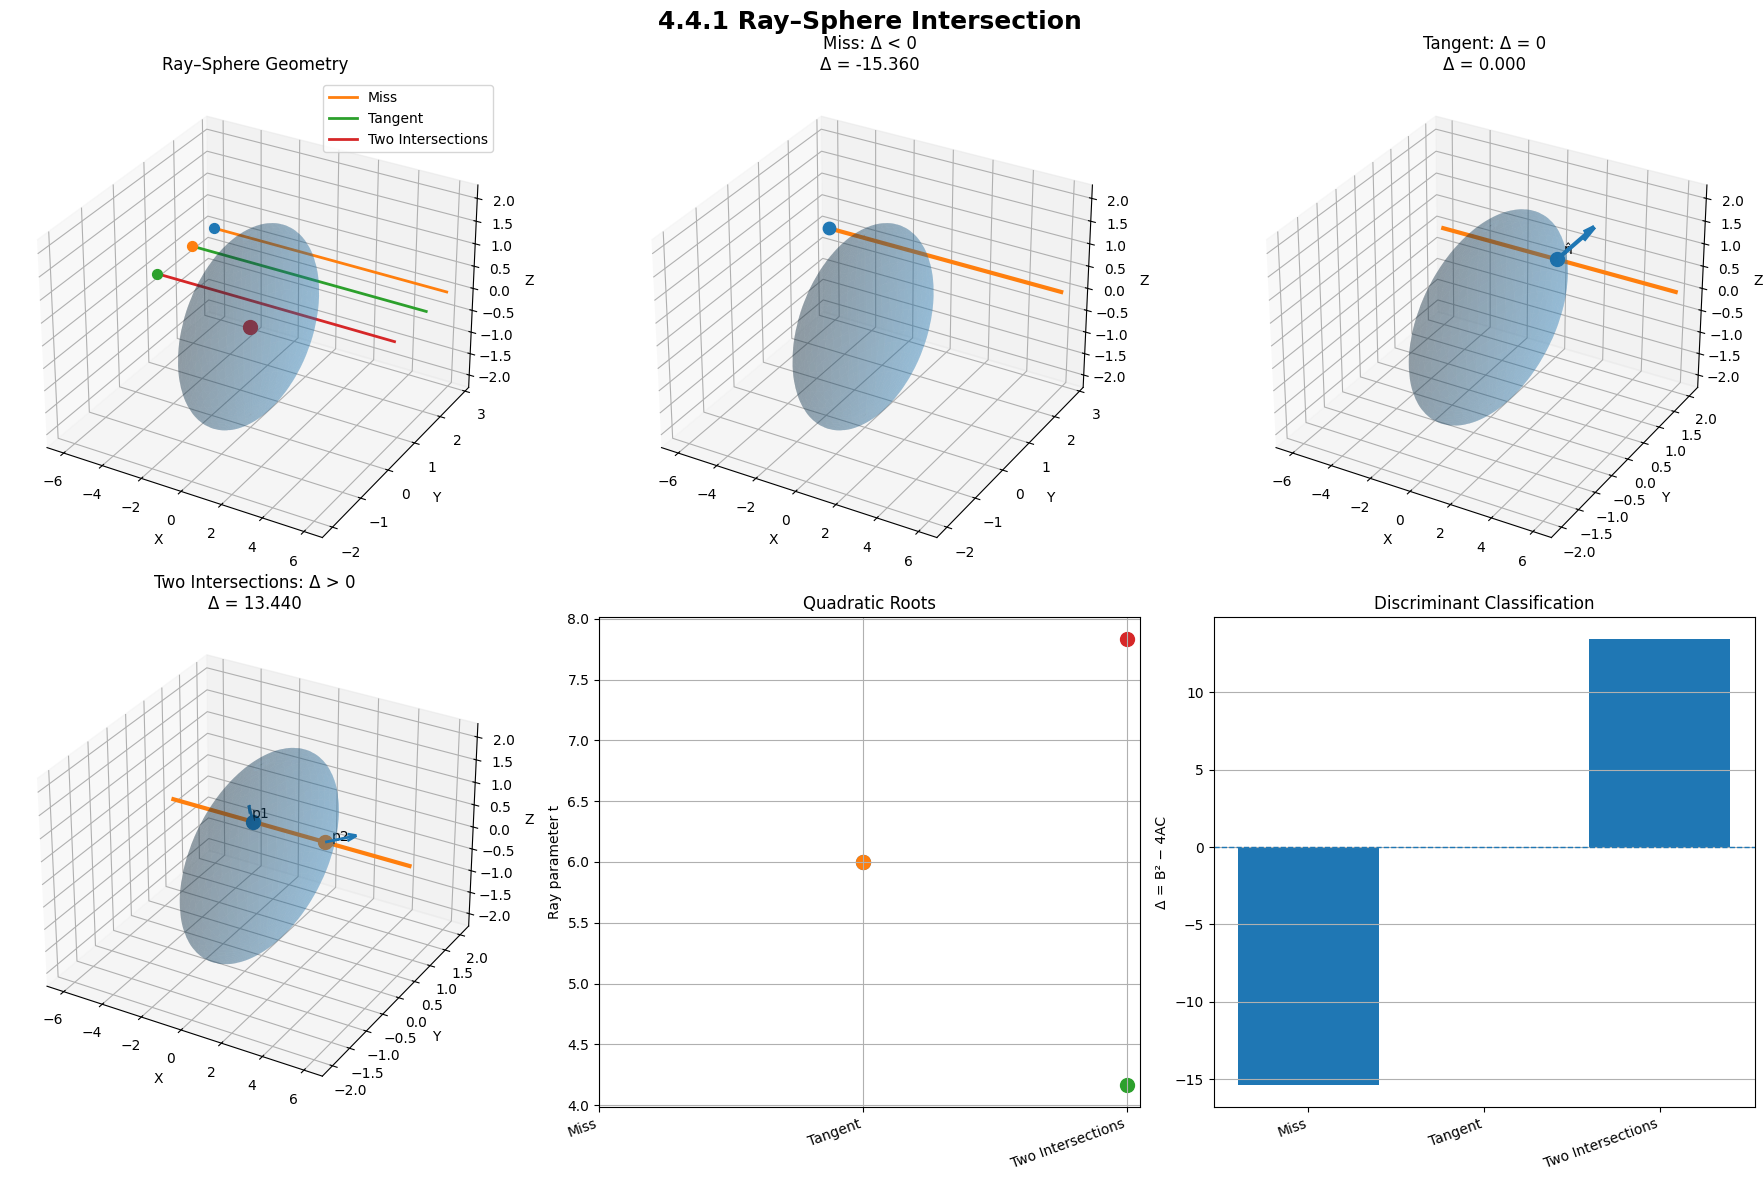

RAY–SPHERE INTERSECTION

Sphere definition
---------------------------------------------------------------------------
Center c = [0. 0. 0.]
Radius R = 2.0

MISS
A = 1.00000000
B = -12.00000000
C = 39.84000000
Δ = -15.36000000
Classification = Miss
Quadratic roots = []
No positive ray parameter t.

TANGENT
A = 1.00000000
B = -12.00000000
C = 36.00000000
Δ = 0.00000000
Classification = Tangent
Quadratic roots = [6. 6.]
Valid t values = [6. 6.]

Intersection 1
p = [0. 2. 0.]
Normal n = [0. 2. 0.]
Unit normal n̂ = [0. 1. 0.]
‖n̂‖ = 1.00000000
Sphere-equation residual = 0.000000000000e+00

Intersection 2
p = [0. 2. 0.]
Normal n = [0. 2. 0.]
Unit normal n̂ = [0. 1. 0.]
‖n̂‖ = 1.00000000
Sphere-equation residual = 0.000000000000e+00

TWO INTERSECTIONS
A = 1.00000000
B = -12.00000000
C = 32.64000000
Δ = 13.44000000
Classification = Two Intersections
Quadratic roots = [4.16696972 7.83303028]
Valid t values = [4.16696972 7.83303028]

Intersection 1
p = [-1.83303028  0.8         0.        ]
Norm

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 4.4.1 RAY–SPHERE INTERSECTION
#
# Ray:
#     p(t) = e + t d
#
# Sphere:
#     ||p - c||² - R² = 0
#
# Quadratic:
#     A t² + B t + C = 0
#
# A = d·d
# B = 2 d·(e-c)
# C = (e-c)·(e-c) - R²
#
# Discriminant:
#     Δ = B² - 4AC
#
# Δ < 0  → Miss
# Δ = 0  → Tangent
# Δ > 0  → Two intersections
# ============================================================


# ============================================================
# 1. SPHERE DEFINITION
# ============================================================

sphere_center = np.array([0.0, 0.0, 0.0])
sphere_radius = 2.0


# ============================================================
# 2. RAY–SPHERE INTERSECTION
# ============================================================

def ray_sphere_intersection(origin, direction, center, radius):

    origin = np.asarray(origin, dtype=float)
    direction = np.asarray(direction, dtype=float)
    center = np.asarray(center, dtype=float)

    direction = direction / np.linalg.norm(direction)

    oc = origin - center

    A = np.dot(direction, direction)

    B = 2.0 * np.dot(
        direction,
        oc
    )

    C = (
        np.dot(oc, oc)
        - radius ** 2
    )

    discriminant = (
        B ** 2
        - 4.0 * A * C
    )

    if discriminant < 0:

        return {
            "A": A,
            "B": B,
            "C": C,
            "discriminant": discriminant,
            "roots": np.array([]),
            "valid_t": np.array([]),
            "points": [],
            "classification": "Miss"
        }

    sqrt_delta = np.sqrt(
        max(discriminant, 0.0)
    )

    t1 = (
        -B - sqrt_delta
    ) / (2.0 * A)

    t2 = (
        -B + sqrt_delta
    ) / (2.0 * A)

    roots = np.array([t1, t2])

    valid_t = roots[roots > 0]

    if np.isclose(discriminant, 0.0):

        classification = "Tangent"

    else:

        classification = "Two Intersections"

    points = [
        origin + t * direction
        for t in valid_t
    ]

    return {
        "A": A,
        "B": B,
        "C": C,
        "discriminant": discriminant,
        "roots": roots,
        "valid_t": valid_t,
        "points": points,
        "classification": classification
    }


# ============================================================
# 3. TEST RAYS
# ============================================================

rays = {

    "Miss": {
        "origin": np.array([-6.0, 2.8, 0.0]),
        "direction": np.array([1.0, 0.0, 0.0])
    },

    "Tangent": {
        "origin": np.array([-6.0, 2.0, 0.0]),
        "direction": np.array([1.0, 0.0, 0.0])
    },

    "Two Intersections": {
        "origin": np.array([-6.0, 0.8, 0.0]),
        "direction": np.array([1.0, 0.0, 0.0])
    }
}


# ============================================================
# 4. COMPUTE INTERSECTIONS
# ============================================================

results = {}

for name, ray in rays.items():

    results[name] = ray_sphere_intersection(
        ray["origin"],
        ray["direction"],
        sphere_center,
        sphere_radius
    )


# ============================================================
# 5. SPHERE SURFACE
# ============================================================

phi = np.linspace(
    0,
    np.pi,
    60
)

theta = np.linspace(
    0,
    2 * np.pi,
    100
)

sphere_x = (
    sphere_center[0]
    + sphere_radius
    * np.outer(
        np.sin(phi),
        np.cos(theta)
    )
)

sphere_y = (
    sphere_center[1]
    + sphere_radius
    * np.outer(
        np.sin(phi),
        np.sin(theta)
    )
)

sphere_z = (
    sphere_center[2]
    + sphere_radius
    * np.outer(
        np.cos(phi),
        np.ones_like(theta)
    )
)


# ============================================================
# 6. RAY PATH
# ============================================================

def generate_ray_path(
    origin,
    direction,
    t_max=12.0,
    samples=300
):

    direction = (
        direction
        / np.linalg.norm(direction)
    )

    t_values = np.linspace(
        0,
        t_max,
        samples
    )

    return np.array([
        origin + t * direction
        for t in t_values
    ])


# ============================================================
# 7. SURFACE NORMAL
# ============================================================

def sphere_normal(
    point,
    center,
    radius
):

    normal = (
        point - center
    )

    unit_normal = (
        normal
        / np.linalg.norm(normal)
    )

    return normal, unit_normal


# ============================================================
# 8. VERIFY SPHERE EQUATION
# ============================================================

def sphere_residual(
    point,
    center,
    radius
):

    return (
        np.dot(
            point - center,
            point - center
        )
        - radius ** 2
    )


# ============================================================
# 9. VISUALIZATION
# ============================================================

fig = plt.figure(
    figsize=(18, 12)
)


# ============================================================
# SUBPLOT 1
# Complete Ray–Sphere Geometry
# ============================================================

ax1 = plt.subplot(
    2,
    3,
    1,
    projection="3d"
)

ax1.plot_surface(
    sphere_x,
    sphere_y,
    sphere_z,
    alpha=0.25
)

for name, ray in rays.items():

    path = generate_ray_path(
        ray["origin"],
        ray["direction"]
    )

    ax1.plot(
        path[:, 0],
        path[:, 1],
        path[:, 2],
        linewidth=2,
        label=name
    )

    ax1.scatter(
        *ray["origin"],
        s=50
    )

ax1.scatter(
    *sphere_center,
    s=100
)

ax1.set_title(
    "Ray–Sphere Geometry"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

ax1.legend()


# ============================================================
# SUBPLOT 2
# Miss: Δ < 0
# ============================================================

ax2 = plt.subplot(
    2,
    3,
    2,
    projection="3d"
)

ax2.plot_surface(
    sphere_x,
    sphere_y,
    sphere_z,
    alpha=0.25
)

ray = rays["Miss"]

path = generate_ray_path(
    ray["origin"],
    ray["direction"]
)

ax2.plot(
    path[:, 0],
    path[:, 1],
    path[:, 2],
    linewidth=3
)

ax2.scatter(
    *ray["origin"],
    s=80
)

delta = results["Miss"]["discriminant"]

ax2.set_title(
    f"Miss: Δ < 0\nΔ = {delta:.3f}"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")


# ============================================================
# SUBPLOT 3
# Tangent: Δ = 0
# ============================================================

ax3 = plt.subplot(
    2,
    3,
    3,
    projection="3d"
)

ax3.plot_surface(
    sphere_x,
    sphere_y,
    sphere_z,
    alpha=0.25
)

ray = rays["Tangent"]

path = generate_ray_path(
    ray["origin"],
    ray["direction"]
)

ax3.plot(
    path[:, 0],
    path[:, 1],
    path[:, 2],
    linewidth=3
)

result = results["Tangent"]

if len(result["points"]) > 0:

    point = result["points"][0]

    normal, unit_normal = sphere_normal(
        point,
        sphere_center,
        sphere_radius
    )

    ax3.scatter(
        *point,
        s=100
    )

    ax3.quiver(
        *point,
        *unit_normal,
        length=1.2,
        linewidth=3
    )

    ax3.text(
        *(point + 0.2 * unit_normal),
        "n̂"
    )

delta = result["discriminant"]

ax3.set_title(
    f"Tangent: Δ = 0\nΔ = {delta:.3f}"
)

ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")


# ============================================================
# SUBPLOT 4
# Two Intersections: Δ > 0
# ============================================================

ax4 = plt.subplot(
    2,
    3,
    4,
    projection="3d"
)

ax4.plot_surface(
    sphere_x,
    sphere_y,
    sphere_z,
    alpha=0.25
)

ray = rays["Two Intersections"]

path = generate_ray_path(
    ray["origin"],
    ray["direction"]
)

ax4.plot(
    path[:, 0],
    path[:, 1],
    path[:, 2],
    linewidth=3
)

result = results["Two Intersections"]

for i, point in enumerate(
    result["points"],
    start=1
):

    normal, unit_normal = sphere_normal(
        point,
        sphere_center,
        sphere_radius
    )

    ax4.scatter(
        *point,
        s=100
    )

    ax4.quiver(
        *point,
        *unit_normal,
        length=1.0,
        linewidth=2
    )

    ax4.text(
        *(point + 0.2 * unit_normal),
        f"p{i}"
    )

delta = result["discriminant"]

ax4.set_title(
    f"Two Intersections: Δ > 0\nΔ = {delta:.3f}"
)

ax4.set_xlabel("X")
ax4.set_ylabel("Y")
ax4.set_zlabel("Z")


# ============================================================
# SUBPLOT 5
# Quadratic Coefficients and Roots
# ============================================================

ax5 = plt.subplot(
    2,
    3,
    5
)

names = list(results.keys())

x = np.arange(
    len(names)
)

for i, name in enumerate(names):

    result = results[name]

    roots = result["roots"]

    for root in roots:

        ax5.scatter(
            i,
            root,
            s=100
        )

ax5.set_xticks(x)

ax5.set_xticklabels(
    names,
    rotation=20,
    ha="right"
)

ax5.set_ylabel("Ray parameter t")

ax5.set_title(
    "Quadratic Roots"
)

ax5.grid(True)


# ============================================================
# SUBPLOT 6
# Discriminant Classification
# ============================================================

ax6 = plt.subplot(
    2,
    3,
    6
)

discriminants = np.array([
    results[name]["discriminant"]
    for name in names
])

ax6.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax6.bar(
    x,
    discriminants
)

ax6.set_xticks(x)

ax6.set_xticklabels(
    names,
    rotation=20,
    ha="right"
)

ax6.set_ylabel(
    "Δ = B² − 4AC"
)

ax6.set_title(
    "Discriminant Classification"
)

ax6.grid(
    axis="y"
)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.suptitle(
    "4.4.1 Ray–Sphere Intersection",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. NUMERICAL VERIFICATION
# ============================================================

print("=" * 75)
print("RAY–SPHERE INTERSECTION")
print("=" * 75)

print("\nSphere definition")
print("-" * 75)

print(
    f"Center c = {sphere_center}"
)

print(
    f"Radius R = {sphere_radius}"
)


for name, result in results.items():

    print("\n" + "=" * 75)

    print(name.upper())

    print("=" * 75)

    print(
        f"A = {result['A']:.8f}"
    )

    print(
        f"B = {result['B']:.8f}"
    )

    print(
        f"C = {result['C']:.8f}"
    )

    print(
        f"Δ = {result['discriminant']:.8f}"
    )

    print(
        f"Classification = {result['classification']}"
    )

    print(
        "Quadratic roots =",
        np.round(
            result["roots"],
            8
        )
    )

    if len(result["valid_t"]) == 0:

        print(
            "No positive ray parameter t."
        )

        continue

    print(
        "Valid t values =",
        np.round(
            result["valid_t"],
            8
        )
    )

    for i, point in enumerate(
        result["points"],
        start=1
    ):

        normal, unit_normal = sphere_normal(
            point,
            sphere_center,
            sphere_radius
        )

        residual = sphere_residual(
            point,
            sphere_center,
            sphere_radius
        )

        print(
            f"\nIntersection {i}"
        )

        print(
            "p =",
            np.round(
                point,
                8
            )
        )

        print(
            "Normal n =",
            np.round(
                normal,
                8
            )
        )

        print(
            "Unit normal n̂ =",
            np.round(
                unit_normal,
                8
            )
        )

        print(
            "‖n̂‖ =",
            f"{np.linalg.norm(unit_normal):.8f}"
        )

        print(
            "Sphere-equation residual =",
            f"{residual:.12e}"
        )


# ============================================================
# 11. CORE MATHEMATICAL VERIFICATION
# ============================================================

print("\n" + "=" * 75)
print("MATHEMATICAL VERIFICATION")
print("=" * 75)

print(
    "\nRay equation:"
)

print(
    "p(t) = e + t d"
)

print(
    "\nSphere equation:"
)

print(
    "||p - c||² - R² = 0"
)

print(
    "\nQuadratic:"
)

print(
    "A t² + B t + C = 0"
)

print(
    "\nCoefficients:"
)

print(
    "A = d·d"
)

print(
    "B = 2d·(e-c)"
)

print(
    "C = (e-c)·(e-c) - R²"
)

print(
    "\nDiscriminant:"
)

print(
    "Δ = B² - 4AC"
)

print(
    "\nInterpretation:"
)

print(
    "Δ < 0  → Ray misses sphere"
)

print(
    "Δ = 0  → Ray is tangent to sphere"
)

print(
    "Δ > 0  → Ray intersects sphere twice"
)

print(
    "\nFor each valid intersection:"
)

print(
    "p = e + t d"
)

print(
    "n = 2(p-c)"
)

print(
    "n̂ = (p-c) / R"
)

print(
    "\nThe implementation therefore connects the"
)

print(
    "geometric ray, quadratic intersection equation,"
)

print(
    "discriminant, intersection point, and surface normal."
)

## **4.4.2 Ray-Triangle Intersection**

**Ray-triangle intersection** determines whether a ray hits a triangle and, if so, where the hit occurs. The method uses **barycentric coordinates**.

Let the ray be

$$
p(t)=e+td
$$

where:

- $e$ = ray origin
- $d$ = ray direction
- $t$ = distance parameter along the ray

Let the triangle vertices be $a,b,c$. A point on the triangle can be written as

$$
p=a+\beta(b-a)+\gamma(c-a)
$$

Therefore, an intersection occurs when

$$
e+td=a+\beta(b-a)+\gamma(c-a)
$$

Here, the three unknowns are:

$$
t,\beta,\gamma
$$

The intersection point is

$$
p=e+td
$$

---

### **Meaning of $\beta$ and $\gamma$**

They determine whether the intersection lies inside the triangle:

$$
\beta>0,\qquad \gamma>0,\qquad \beta+\gamma<1
$$

If these conditions are satisfied, the ray **hits the triangle**. Otherwise, the ray hits the plane outside the triangle.

---

### **Coordinate Equations**

Expanding the equation:

$$
e+td=a+\beta(b-a)+\gamma(c-a)
$$

gives:

$$
x_e+tx_d=x_a+\beta(x_b-x_a)+\gamma(x_c-x_a)
$$

$$
y_e+ty_d=y_a+\beta(y_b-y_a)+\gamma(y_c-y_a)
$$

$$
z_e+tz_d=z_a+\beta(z_b-z_a)+\gamma(z_c-z_a)
$$

These form a **$3\times3$ linear system** for $\beta,\gamma,t$.

---

### **Using Cramer's Rule**

Using Cramer's rule:

$$
\beta=
\frac{
\begin{vmatrix}
x_a-x_e & x_a-x_c & x_d\\
y_a-y_e & y_a-y_c & y_d\\
z_a-z_e & z_a-z_c & z_d
\end{vmatrix}
}{
|A|
}
$$

$$
\gamma=
\frac{
\begin{vmatrix}
x_a-x_b & x_a-x_e & x_d\\
y_a-y_b & y_a-y_e & y_d\\
z_a-z_b & z_a-z_e & z_d
\end{vmatrix}
}{
|A|
}
$$

$$
t=
\frac{
\begin{vmatrix}
x_a-x_b & x_a-x_c & x_a-x_e\\
y_a-y_b & y_a-y_c & y_a-y_e\\
z_a-z_b & z_a-z_c & z_a-z_e
\end{vmatrix}
}{
|A|
}
$$

where

$$
A=
\begin{pmatrix}
x_a-x_b & x_a-x_c & x_d\\
y_a-y_b & y_a-y_c & y_d\\
z_a-z_b & z_a-z_c & z_d
\end{pmatrix}
$$

and $|A|$ is its **determinant**.

---

### **Early-Termination Algorithm**

The intersection test can be implemented efficiently by **rejecting the ray as soon as an invalid value is detected**.

```text
boolean raytri(ray r, vector3 a, vector3 b, vector3 c, interval [t0,t1])

    compute t
    if (t < t0 or t > t1)
        return false

    compute γ
    if (γ < 0 or γ > 1)
        return false

    compute β
    if (β < 0 or β > 1 − γ)
        return false

    return true

**Ray-triangle intersection** converts the geometric problem into solving for **$t,\beta,\gamma$**. The value $t$ locates the **hit along the ray**, while $\beta$ and $\gamma$ determine whether that hit **lies inside the triangle**.

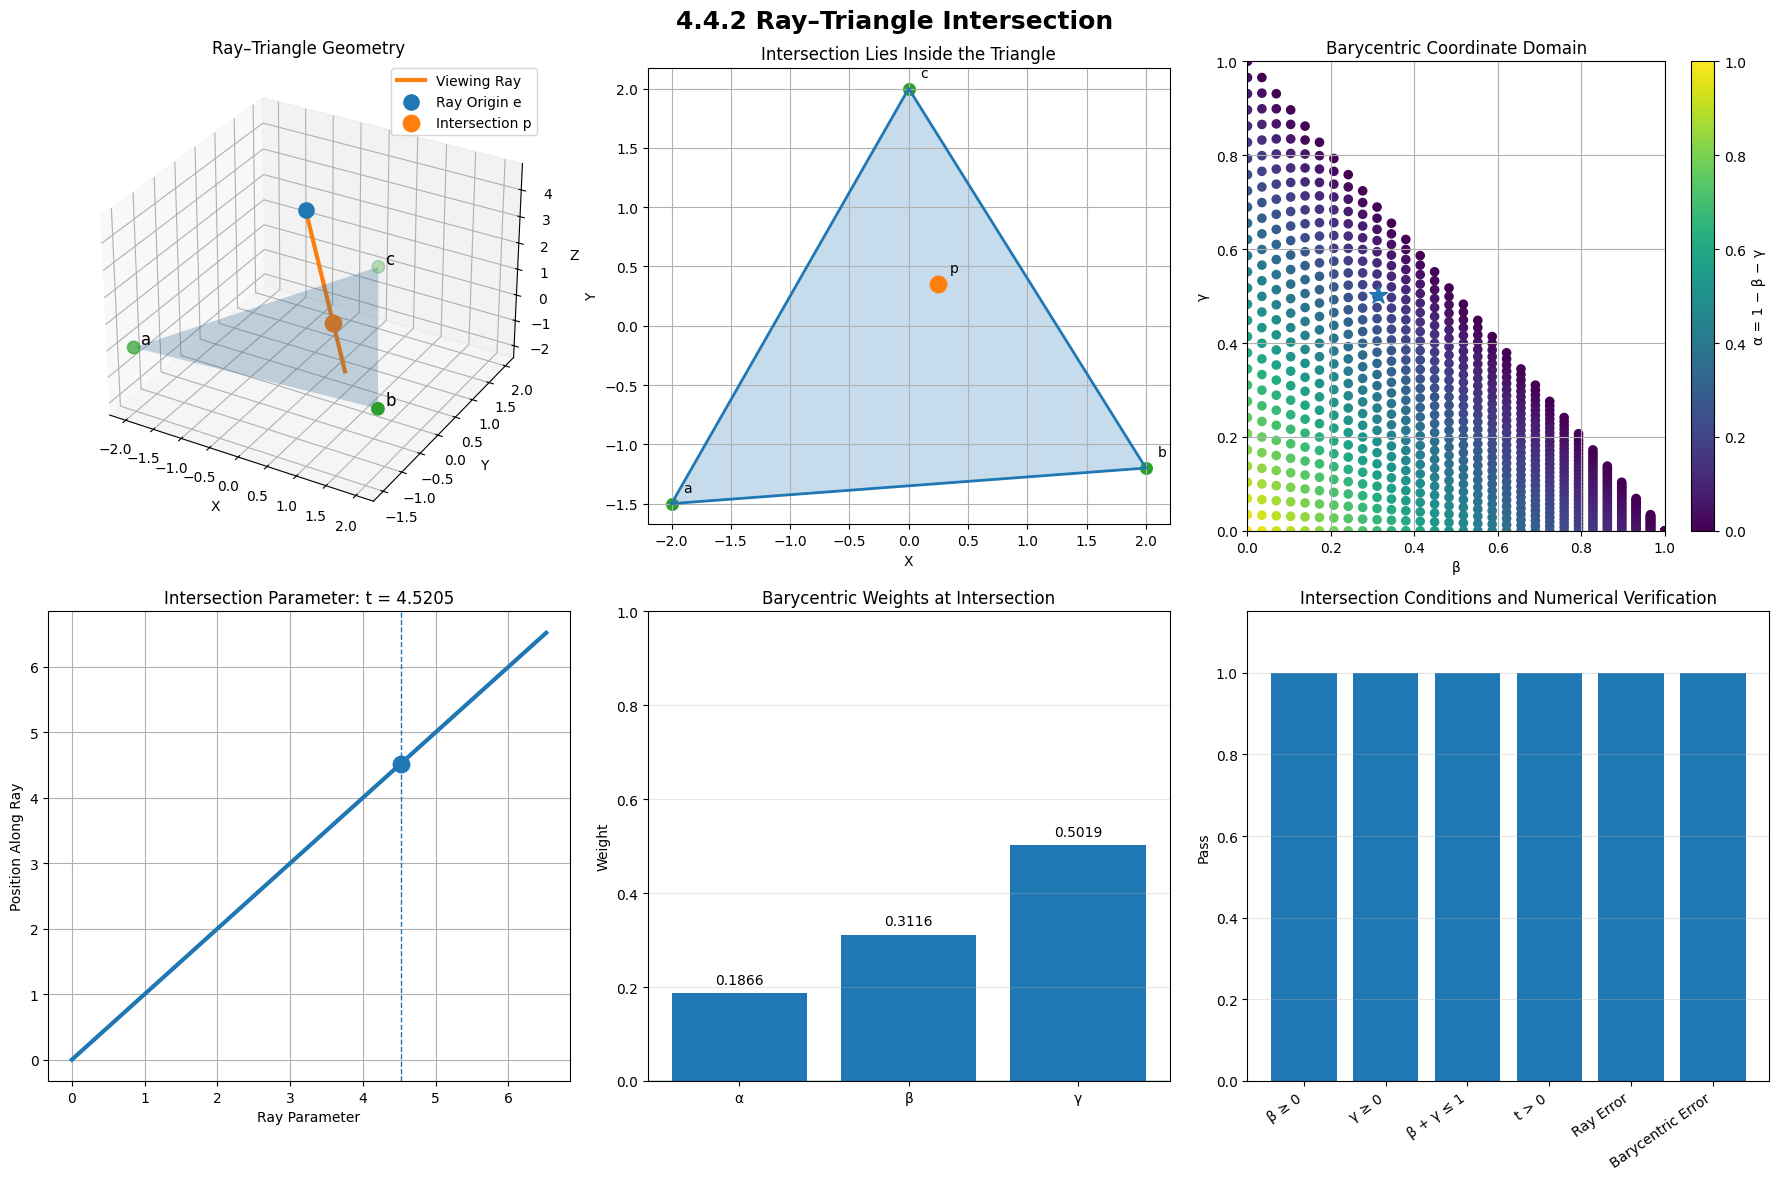

RAY–TRIANGLE INTERSECTION

Triangle vertices:
a = [-2.  -1.5  0. ]
b = [ 2.  -1.2  0. ]
c = [0. 2. 0.]

Ray:
e = [0.  0.  4.5]
d = [ 0.05530351  0.07742491 -0.99546316]

Intersection:
p = [0.25 0.35 0.  ]

Ray parameter:
t = 4.5205088209

Barycentric coordinates:
α = 0.1865671642
β = 0.3115671642
γ = 0.5018656716

Barycentric sum:
α + β + γ = 1.0000000000

Triangle-membership conditions:
β >= 0       : True
γ >= 0       : True
β + γ <= 1   : True

Ray interval:
t_min = 0.0
t_max = 10.0
t in interval: True

Determinant:
det(A) = -13.3392063568

Reconstruction:
Ray point = [0.25 0.35 0.  ]
Barycentric point = [0.25 0.35 0.  ]

Numerical errors:
Ray reconstruction error: 0.000e+00
Barycentric reconstruction error: 2.989e-16

Conclusion:
The ray intersects the triangle.
The intersection is represented by p = e + t d and by the barycentric coordinates αa + βb + γc.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 4.4.2 RAY–TRIANGLE INTERSECTION
#
# Ray:
#     p(t) = e + t d
#
# Triangle:
#     p = a + β(b-a) + γ(c-a)
#
# Intersection:
#     e + t d = a + β(b-a) + γ(c-a)
#
# Unknowns:
#     t, β, γ
#
# Interior condition:
#     β >= 0, γ >= 0, β + γ <= 1
# ============================================================


# ------------------------------------------------------------
# Scene Geometry
# ------------------------------------------------------------

a = np.array([-2.0, -1.5, 0.0])
b = np.array([2.0, -1.2, 0.0])
c = np.array([0.0, 2.0, 0.0])

e = np.array([0.0, 0.0, 4.5])

target = np.array([0.25, 0.35, 0.0])

d = target - e
d = d / np.linalg.norm(d)

t_min = 0.0
t_max = 10.0


# ------------------------------------------------------------
# Ray–Triangle Solver
# ------------------------------------------------------------

def ray_triangle_intersection(
    e, d, a, b, c,
    t_min=0.0,
    t_max=np.inf,
    tolerance=1e-10
):

    edge1 = b - a
    edge2 = c - a

    A = np.column_stack([
        -edge1,
        -edge2,
        d
    ])

    rhs = a - e

    determinant = np.linalg.det(A)

    if abs(determinant) < tolerance:
        return None

    beta, gamma, t = np.linalg.solve(A, rhs)

    if t < t_min or t > t_max:
        return None

    if beta < -tolerance or beta > 1 + tolerance:
        return None

    if gamma < -tolerance or gamma > 1 + tolerance:
        return None

    if beta + gamma > 1 + tolerance:
        return None

    point = e + t * d

    return {
        "t": t,
        "beta": beta,
        "gamma": gamma,
        "alpha": 1 - beta - gamma,
        "point": point,
        "determinant": determinant,
        "matrix": A
    }


hit = ray_triangle_intersection(
    e, d, a, b, c,
    t_min,
    t_max
)


# ------------------------------------------------------------
# Barycentric Verification
# ------------------------------------------------------------

if hit is not None:

    t = hit["t"]
    beta = hit["beta"]
    gamma = hit["gamma"]
    alpha = hit["alpha"]
    intersection = hit["point"]

    barycentric_reconstruction = (
        alpha * a
        + beta * b
        + gamma * c
    )

    ray_reconstruction = e + t * d

    barycentric_error = np.linalg.norm(
        intersection - barycentric_reconstruction
    )

    ray_error = np.linalg.norm(
        intersection - ray_reconstruction
    )

else:

    raise RuntimeError("The selected ray does not intersect the triangle.")


# ------------------------------------------------------------
# Ray Path
# ------------------------------------------------------------

ray_t = np.linspace(
    0,
    min(t_max, t + 2.0),
    150
)

ray_points = np.array([
    e + value * d
    for value in ray_t
])


# ------------------------------------------------------------
# Triangle Surface
# ------------------------------------------------------------

triangle_vertices = np.array([
    a,
    b,
    c
])


# ------------------------------------------------------------
# Barycentric Coordinate Grid
# ------------------------------------------------------------

n = 30

bary_points = []
bary_values = []

for beta_value in np.linspace(0, 1, n):

    for gamma_value in np.linspace(
        0,
        1 - beta_value,
        n
    ):

        alpha_value = (
            1
            - beta_value
            - gamma_value
        )

        point = (
            alpha_value * a
            + beta_value * b
            + gamma_value * c
        )

        bary_points.append(point)
        bary_values.append(
            [
                alpha_value,
                beta_value,
                gamma_value
            ]
        )

bary_points = np.array(bary_points)
bary_values = np.array(bary_values)


# ============================================================
# VISUALIZATION
# Three Subplots per Row
# ============================================================

fig = plt.figure(figsize=(18, 12))


# ------------------------------------------------------------
# 1. 3D Ray–Triangle Geometry
# ------------------------------------------------------------

ax1 = plt.subplot(
    2, 3, 1,
    projection="3d"
)

ax1.plot_trisurf(
    triangle_vertices[:, 0],
    triangle_vertices[:, 1],
    triangle_vertices[:, 2],
    alpha=0.25
)

ax1.plot(
    ray_points[:, 0],
    ray_points[:, 1],
    ray_points[:, 2],
    linewidth=3,
    label="Viewing Ray"
)

ax1.scatter(
    *e,
    s=120,
    label="Ray Origin e"
)

ax1.scatter(
    *intersection,
    s=140,
    label="Intersection p"
)

ax1.scatter(
    triangle_vertices[:, 0],
    triangle_vertices[:, 1],
    triangle_vertices[:, 2],
    s=80
)

for point, label in zip(
    triangle_vertices,
    ["a", "b", "c"]
):

    ax1.text(
        *(point + np.array([0.08, 0.08, 0.08])),
        label,
        fontsize=12
    )

ax1.set_title(
    "Ray–Triangle Geometry"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

ax1.legend()


# ------------------------------------------------------------
# 2. Triangle and Intersection Point
# ------------------------------------------------------------

ax2 = plt.subplot(
    2, 3, 2
)

ax2.fill(
    triangle_vertices[:, 0],
    triangle_vertices[:, 1],
    alpha=0.25
)

ax2.plot(
    np.r_[
        triangle_vertices[:, 0],
        triangle_vertices[0, 0]
    ],
    np.r_[
        triangle_vertices[:, 1],
        triangle_vertices[0, 1]
    ],
    linewidth=2
)

ax2.scatter(
    intersection[0],
    intersection[1],
    s=140
)

ax2.text(
    intersection[0] + 0.1,
    intersection[1] + 0.1,
    "p"
)

ax2.scatter(
    triangle_vertices[:, 0],
    triangle_vertices[:, 1],
    s=70
)

for point, label in zip(
    triangle_vertices,
    ["a", "b", "c"]
):

    ax2.text(
        point[0] + 0.1,
        point[1] + 0.1,
        label
    )

ax2.set_title(
    "Intersection Lies Inside the Triangle"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")

ax2.set_aspect("equal")
ax2.grid(True)


# ------------------------------------------------------------
# 3. Barycentric Coordinates
# ------------------------------------------------------------

ax3 = plt.subplot(
    2, 3, 3
)

scatter = ax3.scatter(
    bary_values[:, 1],
    bary_values[:, 2],
    c=bary_values[:, 0],
    s=35
)

ax3.scatter(
    beta,
    gamma,
    s=180,
    marker="*"
)

ax3.set_xlabel("β")
ax3.set_ylabel("γ")

ax3.set_title(
    "Barycentric Coordinate Domain"
)

ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)

ax3.grid(True)

plt.colorbar(
    scatter,
    ax=ax3,
    label="α = 1 − β − γ"
)


# ------------------------------------------------------------
# 4. Ray Parameter t
# ------------------------------------------------------------

ax4 = plt.subplot(
    2, 3, 4
)

ax4.plot(
    ray_t,
    ray_t,
    linewidth=3
)

ax4.scatter(
    t,
    t,
    s=140
)

ax4.axvline(
    t,
    linestyle="--",
    linewidth=1
)

ax4.set_xlabel("Ray Parameter")
ax4.set_ylabel("Position Along Ray")

ax4.set_title(
    f"Intersection Parameter: t = {t:.4f}"
)

ax4.grid(True)


# ------------------------------------------------------------
# 5. Barycentric Weights
# ------------------------------------------------------------

ax5 = plt.subplot(
    2, 3, 5
)

labels = [
    "α",
    "β",
    "γ"
]

weights = [
    alpha,
    beta,
    gamma
]

bars = ax5.bar(
    labels,
    weights
)

ax5.axhline(
    0,
    linewidth=1
)

ax5.set_ylim(
    0,
    max(1.0, max(weights) * 1.25)
)

ax5.set_ylabel("Weight")

ax5.set_title(
    "Barycentric Weights at Intersection"
)

ax5.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    weights
):

    ax5.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )


# ------------------------------------------------------------
# 6. Numerical Verification
# ------------------------------------------------------------

ax6 = plt.subplot(
    2, 3, 6
)

verification_labels = [
    "β ≥ 0",
    "γ ≥ 0",
    "β + γ ≤ 1",
    "t > 0",
    "Ray Error",
    "Barycentric Error"
]

verification_values = [
    beta >= 0,
    gamma >= 0,
    beta + gamma <= 1,
    t > 0,
    ray_error < 1e-10,
    barycentric_error < 1e-10
]

verification_numeric = [
    1 if value else 0
    for value in verification_values
]

ax6.bar(
    np.arange(
        len(verification_labels)
    ),
    verification_numeric
)

ax6.set_xticks(
    np.arange(
        len(verification_labels)
    )
)

ax6.set_xticklabels(
    verification_labels,
    rotation=35,
    ha="right"
)

ax6.set_ylim(
    0,
    1.15
)

ax6.set_ylabel("Pass")

ax6.set_title(
    "Intersection Conditions and Numerical Verification"
)

ax6.grid(
    axis="y",
    alpha=0.3
)


# ============================================================
# Layout
# ============================================================

plt.suptitle(
    "4.4.2 Ray–Triangle Intersection",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ============================================================
# Numerical Results
# ============================================================

print("=" * 70)
print("RAY–TRIANGLE INTERSECTION")
print("=" * 70)

print("\nTriangle vertices:")
print("a =", a)
print("b =", b)
print("c =", c)

print("\nRay:")
print("e =", e)
print("d =", d)

print("\nIntersection:")
print("p =", intersection)

print("\nRay parameter:")
print(f"t = {t:.10f}")

print("\nBarycentric coordinates:")
print(f"α = {alpha:.10f}")
print(f"β = {beta:.10f}")
print(f"γ = {gamma:.10f}")

print("\nBarycentric sum:")
print(
    f"α + β + γ = "
    f"{alpha + beta + gamma:.10f}"
)

print("\nTriangle-membership conditions:")
print(f"β >= 0       : {beta >= 0}")
print(f"γ >= 0       : {gamma >= 0}")
print(f"β + γ <= 1   : {beta + gamma <= 1}")

print("\nRay interval:")
print(f"t_min = {t_min}")
print(f"t_max = {t_max}")
print(f"t in interval: {t_min <= t <= t_max}")

print("\nDeterminant:")
print(
    f"det(A) = {hit['determinant']:.10f}"
)

print("\nReconstruction:")
print(
    "Ray point =",
    ray_reconstruction
)

print(
    "Barycentric point =",
    barycentric_reconstruction
)

print("\nNumerical errors:")
print(
    f"Ray reconstruction error: "
    f"{ray_error:.3e}"
)

print(
    f"Barycentric reconstruction error: "
    f"{barycentric_error:.3e}"
)

print("\nConclusion:")

if (
    beta >= 0
    and gamma >= 0
    and beta + gamma <= 1
    and t_min <= t <= t_max
):

    print(
        "The ray intersects the triangle."
    )

    print(
        "The intersection is represented by "
        "p = e + t d and by the barycentric "
        "coordinates αa + βb + γc."
    )

else:

    print(
        "The ray does not intersect the triangle."
    )

## **4.4.3 Ray-Polygon Intersection**

**Ray-polygon intersection** determines whether a ray hits a **planar polygon**.

Let the polygon have vertices

$$
p_1,p_2,\ldots,p_m
$$

and surface normal $n$. The ray is

$$
p=e+td
$$

where:

- $e$ = ray origin
- $d$ = ray direction
- $t$ = distance along the ray
- $n$ = polygon surface normal
- $p_1$ = any vertex of the polygon

---

## **1. Find the Ray-Plane Intersection**

The polygon lies on the plane

$$
(p-p_1)\cdot n=0
$$

Substitute the ray $p=e+td$:

$$
(e+td-p_1)\cdot n=0
$$

Solving for $t$:

$$
t=\frac{(p_1-e)\cdot n}{d\cdot n}
$$

Then calculate the intersection point:

$$
p=e+td
$$

If

$$
d\cdot n=0
$$

the ray is **parallel to the polygon's plane**, so there is no ordinary intersection.

---

## **2. Test Whether the Point Is Inside the Polygon**

Finding the plane intersection is **not enough**. The point $p$ must also lie **inside the polygon**.

Project the polygon and $p$ onto a suitable coordinate plane, such as:

- **$xy$-plane**
- **$yz$-plane**
- **$zx$-plane**

Then cast a **2D ray from $p$** and count how many times it crosses the polygon boundary.

$$
\text{odd intersections}\Rightarrow\text{inside}
$$

$$
\text{even intersections}\Rightarrow\text{outside}
$$

For convenience, the 2D ray can be taken along the $x$-axis:

$$
\begin{bmatrix}
x\\
y
\end{bmatrix}
=
\begin{bmatrix}
x_p\\
y_p
\end{bmatrix}
+
s
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad s>0
$$

---

## **3. Choose a Suitable Projection Plane**

The **$xy$-projection can become degenerate** if the polygon projects to a line. Therefore, choose the coordinate plane whose axes are most suitable based on the surface normal.

```text
if |n_z| > |n_x| and |n_z| > |n_y|
    use x, y

else if |n_y| > |n_x|
    use x, z

else
    use y, z

Here:

- $x_n,y_n,z_n$ = components of the polygon normal $n$
- `index0`, `index1` = selected coordinate indices for projection.

### **Key Idea**

Ray-polygon intersection has **two stages**:

$$
\text{Ray}
\rightarrow
\text{Plane Intersection}
\rightarrow
\text{Inside-Polygon Test}
$$

First find where the ray meets the polygon's plane. Then determine whether that point is actually **inside the polygon**. If yes, the ray **hits the polygon**; otherwise, it **misses**.

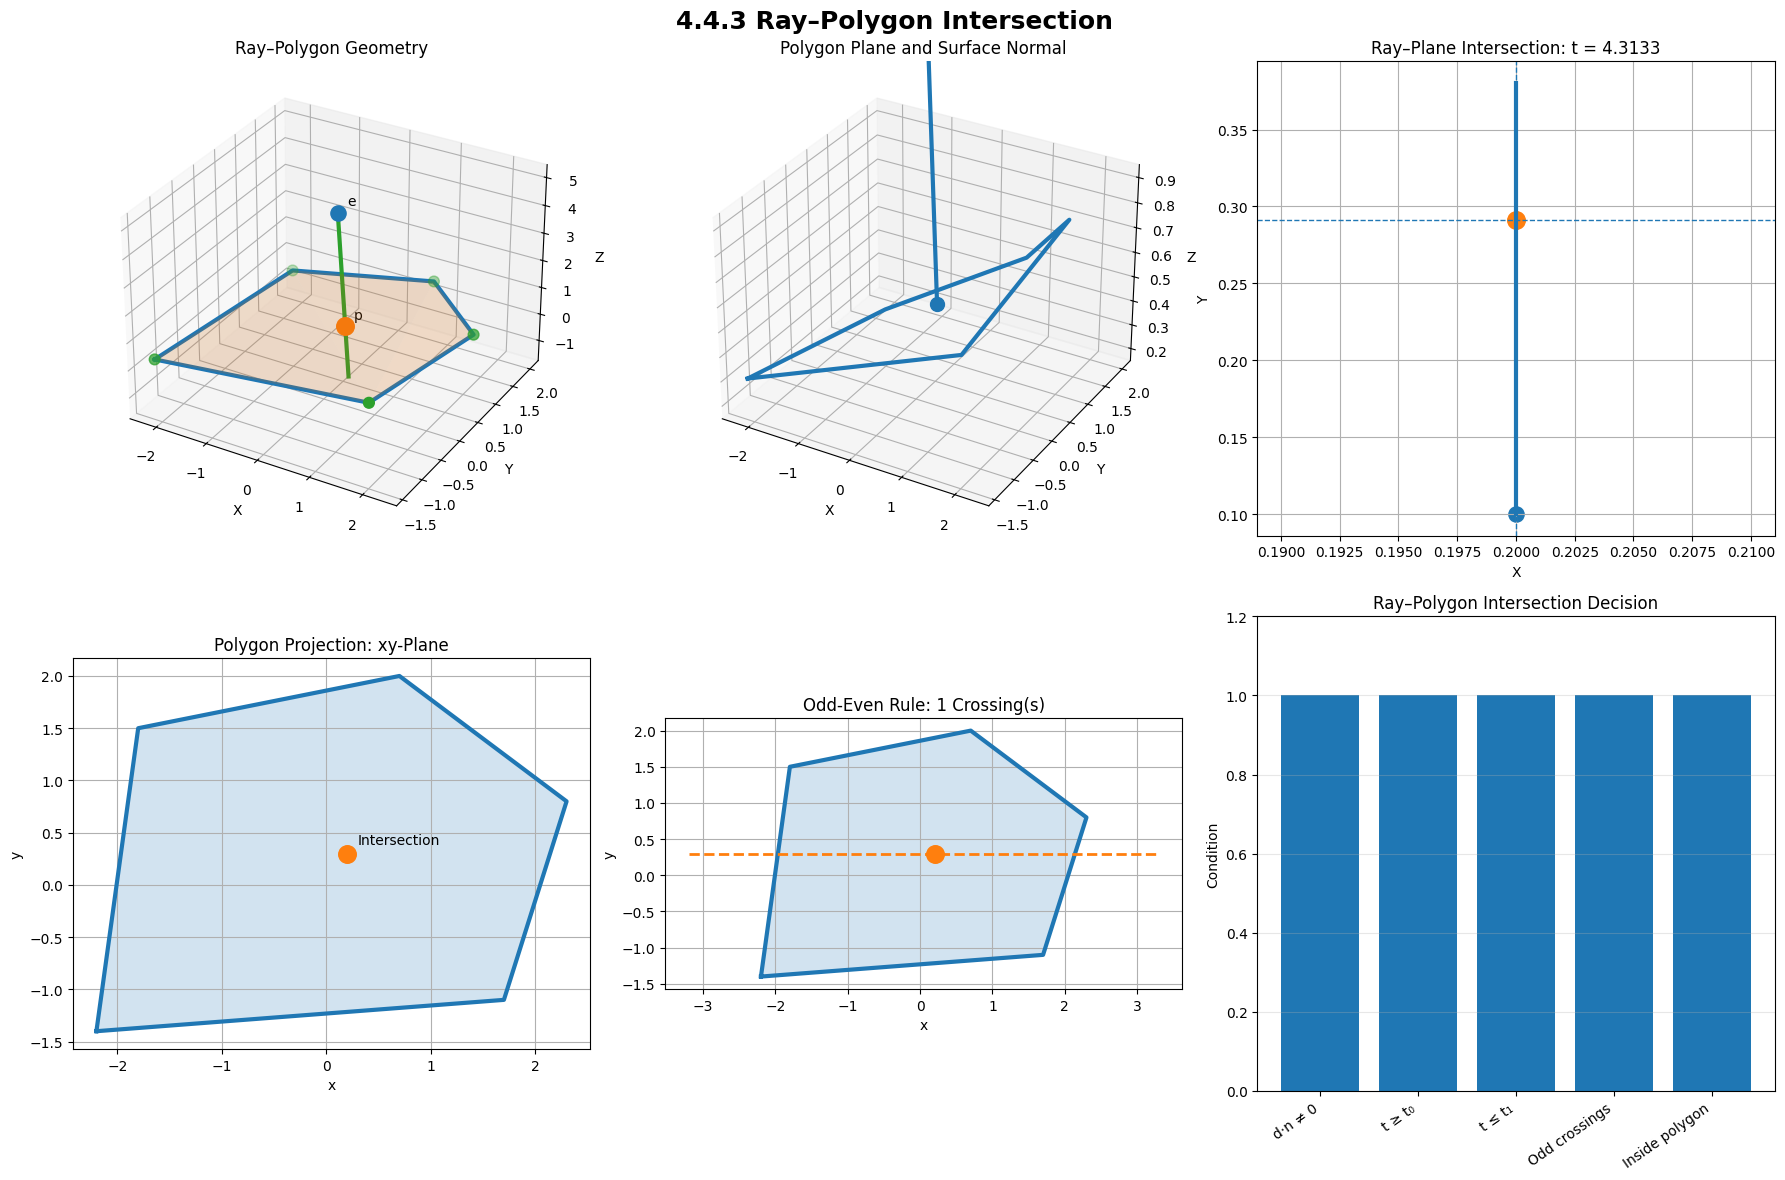

RAY–POLYGON INTERSECTION

Polygon vertices:
p1 = [-2.2 -1.4  0.3]
p2 = [ 1.7 -1.1  0.6]
p3 = [2.3 0.8 0.9]
p4 = [0.7 2.  0.5]
p5 = [-1.8  1.5  0.2]

Surface normal:
n = [-0.06563443 -0.13537102  0.98861864]

Ray origin:
e = [0.2 0.1 5. ]

Ray direction:
d = [ 0.          0.04440061 -0.99901381]

Ray-plane denominator:
d · n = -0.9936542238

Selected projection:
xy

Ray parameter:
t = 4.3132996652

Intersection point:
[0.2        0.29151315 0.69095408]

2D crossings:
1

Ray-plane intersection:
True

Inside polygon:
True

Ray–polygon result:
Intersection inside polygon

Centroid test:
Inside = True, crossings = 1

Outside-point test:
Inside = False, crossings = 0

Conclusion:
The ray intersects the polygon: the ray first intersects the polygon's supporting plane and the resulting point lies inside the polygon under the odd-even rule.


In [9]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 4.4.3 RAY–POLYGON INTERSECTION
#
# Ray:
#     p(t) = e + t d
#
# Polygon plane:
#     (p - p1) · n = 0
#
# Plane intersection:
#     t = ((p1 - e) · n) / (d · n)
#
# Polygon membership:
#     Project to the most suitable coordinate plane and apply
#     the 2D odd-even rule.
# ============================================================


# ------------------------------------------------------------
# Polygon Geometry
# ------------------------------------------------------------

polygon = np.array([
    [-2.2, -1.4, 0.3],
    [ 1.7, -1.1, 0.6],
    [ 2.3,  0.8, 0.9],
    [ 0.7,  2.0, 0.5],
    [-1.8,  1.5, 0.2]
])

p1 = polygon[0]

edge1 = polygon[1] - polygon[0]
edge2 = polygon[2] - polygon[0]

n = np.cross(edge1, edge2)
n = n / np.linalg.norm(n)


# ------------------------------------------------------------
# Ray
# ------------------------------------------------------------

e = np.array([
    0.2,
    0.1,
    5.0
])

target = np.array([
    0.2,
    0.3,
    0.5
])

d = target - e
d = d / np.linalg.norm(d)

t_min = 0.0
t_max = 20.0


# ============================================================
# Projection Selection
# ============================================================

def choose_projection(normal):

    nx, ny, nz = np.abs(normal)

    if nz > nx and nz > ny:
        return "xy", (0, 1)

    elif ny > nx:
        return "xz", (0, 2)

    else:
        return "yz", (1, 2)


projection_name, projection_axes = choose_projection(n)


# ============================================================
# 2D Point-In-Polygon: Odd-Even Rule
# ============================================================

def point_in_polygon_2d(point, polygon_2d):

    x, y = point

    inside = False
    crossings = 0

    n_vertices = len(polygon_2d)

    for i in range(n_vertices):

        j = (i - 1) % n_vertices

        xi, yi = polygon_2d[i]
        xj, yj = polygon_2d[j]

        crosses = (
            (yi > y) != (yj > y)
        )

        if crosses:

            x_intersection = (
                xj
                + (y - yj)
                * (xi - xj)
                / (yi - yj)
            )

            if x < x_intersection:

                crossings += 1
                inside = not inside

    return inside, crossings


# ============================================================
# Ray–Polygon Intersection
# ============================================================

def ray_polygon_intersection(
    origin,
    direction,
    polygon,
    normal,
    t_min=0.0,
    t_max=np.inf,
    tolerance=1e-10
):

    p1 = polygon[0]

    denominator = np.dot(
        direction,
        normal
    )

    if abs(denominator) < tolerance:

        return {
            "hit": False,
            "reason": "Ray is parallel to polygon plane",
            "t": None,
            "point": None,
            "crossings": 0
        }

    t = np.dot(
        p1 - origin,
        normal
    ) / denominator

    if t < t_min or t > t_max:

        return {
            "hit": False,
            "reason": "Plane intersection outside ray interval",
            "t": t,
            "point": origin + t * direction,
            "crossings": 0
        }

    intersection = (
        origin
        + t * direction
    )

    projection_name, axes = choose_projection(
        normal
    )

    polygon_2d = polygon[:, axes]
    point_2d = intersection[list(axes)]

    inside, crossings = point_in_polygon_2d(
        point_2d,
        polygon_2d
    )

    return {
        "hit": inside,
        "reason": (
            "Intersection inside polygon"
            if inside
            else "Intersection outside polygon"
        ),
        "t": t,
        "point": intersection,
        "point_2d": point_2d,
        "polygon_2d": polygon_2d,
        "crossings": crossings,
        "projection": projection_name,
        "denominator": denominator
    }


result = ray_polygon_intersection(
    e,
    d,
    polygon,
    n,
    t_min,
    t_max
)


intersection = result["point"]


# ============================================================
# Ray Path
# ============================================================

if intersection is not None:

    ray_end = (
        intersection
        + 2.0 * d
    )

else:

    ray_end = (
        e
        + 10.0 * d
    )

ray_t = np.linspace(
    0,
    np.linalg.norm(ray_end - e),
    150
)

ray_points = np.array([
    e + value * d
    for value in ray_t
])


# ============================================================
# Polygon Plane Surface
# ============================================================

polygon_closed = np.vstack([
    polygon,
    polygon[0]
])


# ============================================================
# Point-In-Polygon Demonstration
# ============================================================

projection_axes = choose_projection(n)[1]

polygon_2d = polygon[:, projection_axes]

if intersection is not None:

    intersection_2d = (
        intersection[list(projection_axes)]
    )

else:

    intersection_2d = None


# ============================================================
# Additional Test Points
# ============================================================

centroid = np.mean(
    polygon,
    axis=0
)

outside_point = (
    centroid
    + np.array([4.0, 3.0, 0.0])
)

inside_2d, inside_crossings = point_in_polygon_2d(
    centroid[list(projection_axes)],
    polygon_2d
)

outside_2d, outside_crossings = point_in_polygon_2d(
    outside_point[list(projection_axes)],
    polygon_2d
)


# ============================================================
# Visualization
# Three Subplots per Row
# ============================================================

fig = plt.figure(
    figsize=(18, 12)
)


# ------------------------------------------------------------
# 1. 3D Polygon and Ray
# ------------------------------------------------------------

ax1 = plt.subplot(
    2, 3, 1,
    projection="3d"
)

ax1.plot(
    polygon_closed[:, 0],
    polygon_closed[:, 1],
    polygon_closed[:, 2],
    linewidth=3
)

ax1.plot_trisurf(
    polygon[:, 0],
    polygon[:, 1],
    polygon[:, 2],
    alpha=0.20
)

ax1.plot(
    ray_points[:, 0],
    ray_points[:, 1],
    ray_points[:, 2],
    linewidth=3
)

ax1.scatter(
    *e,
    s=120
)

ax1.text(
    *(e + np.array([0.1, 0.1, 0.2])),
    "e"
)

if intersection is not None:

    ax1.scatter(
        *intersection,
        s=160
    )

    ax1.text(
        *(intersection + np.array([
            0.1,
            0.1,
            0.2
        ])),
        "p"
    )

ax1.scatter(
    polygon[:, 0],
    polygon[:, 1],
    polygon[:, 2],
    s=60
)

ax1.set_title(
    "Ray–Polygon Geometry"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")


# ------------------------------------------------------------
# 2. Polygon Surface Normal
# ------------------------------------------------------------

ax2 = plt.subplot(
    2, 3, 2,
    projection="3d"
)

ax2.plot(
    polygon_closed[:, 0],
    polygon_closed[:, 1],
    polygon_closed[:, 2],
    linewidth=3
)

center = np.mean(
    polygon,
    axis=0
)

ax2.scatter(
    *center,
    s=100
)

ax2.quiver(
    center[0],
    center[1],
    center[2],
    n[0],
    n[1],
    n[2],
    length=2.0,
    linewidth=3
)

ax2.text(
    *(center + 2.1 * n),
    "n"
)

ax2.set_title(
    "Polygon Plane and Surface Normal"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")


# ------------------------------------------------------------
# 3. Ray–Plane Intersection
# ------------------------------------------------------------

ax3 = plt.subplot(
    2, 3, 3
)

ax3.plot(
    ray_points[:, 0],
    ray_points[:, 1],
    linewidth=3
)

ax3.scatter(
    e[0],
    e[1],
    s=120
)

if intersection is not None:

    ax3.scatter(
        intersection[0],
        intersection[1],
        s=160
    )

    ax3.axvline(
        intersection[0],
        linestyle="--",
        linewidth=1
    )

    ax3.axhline(
        intersection[1],
        linestyle="--",
        linewidth=1
    )

ax3.set_xlabel("X")
ax3.set_ylabel("Y")

ax3.set_title(
    f"Ray–Plane Intersection: t = {result['t']:.4f}"
)

ax3.grid(True)


# ------------------------------------------------------------
# 4. Selected Projection Plane
# ------------------------------------------------------------

ax4 = plt.subplot(
    2, 3, 4
)

ax4.fill(
    polygon_2d[:, 0],
    polygon_2d[:, 1],
    alpha=0.20
)

polygon_2d_closed = np.vstack([
    polygon_2d,
    polygon_2d[0]
])

ax4.plot(
    polygon_2d_closed[:, 0],
    polygon_2d_closed[:, 1],
    linewidth=3
)

if intersection_2d is not None:

    ax4.scatter(
        intersection_2d[0],
        intersection_2d[1],
        s=160
    )

    ax4.text(
        intersection_2d[0] + 0.1,
        intersection_2d[1] + 0.1,
        "Intersection"
    )

ax4.set_xlabel(
    projection_name[0]
)

ax4.set_ylabel(
    projection_name[1]
)

ax4.set_title(
    f"Polygon Projection: {projection_name}-Plane"
)

ax4.set_aspect(
    "equal"
)

ax4.grid(True)


# ------------------------------------------------------------
# 5. Odd-Even Crossing Demonstration
# ------------------------------------------------------------

ax5 = plt.subplot(
    2, 3, 5
)

ax5.fill(
    polygon_2d[:, 0],
    polygon_2d[:, 1],
    alpha=0.20
)

ax5.plot(
    polygon_2d_closed[:, 0],
    polygon_2d_closed[:, 1],
    linewidth=3
)

if intersection_2d is not None:

    y = intersection_2d[1]

    x_start = (
        np.min(polygon_2d[:, 0])
        - 1
    )

    x_end = (
        np.max(polygon_2d[:, 0])
        + 1
    )

    ax5.plot(
        [x_start, x_end],
        [y, y],
        linestyle="--",
        linewidth=2
    )

    ax5.scatter(
        intersection_2d[0],
        intersection_2d[1],
        s=160
    )

ax5.set_xlabel(
    projection_name[0]
)

ax5.set_ylabel(
    projection_name[1]
)

ax5.set_title(
    f"Odd-Even Rule: {result['crossings']} Crossing(s)"
)

ax5.set_aspect(
    "equal"
)

ax5.grid(True)


# ------------------------------------------------------------
# 6. Intersection Decision
# ------------------------------------------------------------

ax6 = plt.subplot(
    2, 3, 6
)

labels = [
    "d·n ≠ 0",
    "t ≥ t₀",
    "t ≤ t₁",
    "Odd crossings",
    "Inside polygon"
]

values = [
    abs(result["denominator"]) > 1e-10,
    result["t"] is not None
    and result["t"] >= t_min,
    result["t"] is not None
    and result["t"] <= t_max,
    result["crossings"] % 2 == 1,
    result["hit"]
]

numeric = [
    int(value)
    for value in values
]

ax6.bar(
    np.arange(len(labels)),
    numeric
)

ax6.set_xticks(
    np.arange(len(labels))
)

ax6.set_xticklabels(
    labels,
    rotation=35,
    ha="right"
)

ax6.set_ylim(
    0,
    1.2
)

ax6.set_ylabel(
    "Condition"
)

ax6.set_title(
    "Ray–Polygon Intersection Decision"
)

ax6.grid(
    axis="y",
    alpha=0.3
)


# ============================================================
# Final Layout
# ============================================================

plt.suptitle(
    "4.4.3 Ray–Polygon Intersection",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ============================================================
# Numerical Verification
# ============================================================

print("=" * 70)
print("RAY–POLYGON INTERSECTION")
print("=" * 70)

print("\nPolygon vertices:")
for i, vertex in enumerate(polygon, 1):
    print(f"p{i} = {vertex}")

print("\nSurface normal:")
print("n =", n)

print("\nRay origin:")
print("e =", e)

print("\nRay direction:")
print("d =", d)

print("\nRay-plane denominator:")
print(
    f"d · n = {result['denominator']:.10f}"
)

print("\nSelected projection:")
print(
    result["projection"]
)

print("\nRay parameter:")
print(
    f"t = {result['t']:.10f}"
)

print("\nIntersection point:")
print(
    intersection
)

print("\n2D crossings:")
print(
    result["crossings"]
)

print("\nRay-plane intersection:")
print(
    result["t"] is not None
)

print("\nInside polygon:")
print(
    result["hit"]
)

print("\nRay–polygon result:")
print(
    result["reason"]
)

print("\nCentroid test:")
print(
    f"Inside = {inside_2d}, "
    f"crossings = {inside_crossings}"
)

print("\nOutside-point test:")
print(
    f"Inside = {outside_2d}, "
    f"crossings = {outside_crossings}"
)

print("\nConclusion:")

if result["hit"]:

    print(
        "The ray intersects the polygon: "
        "the ray first intersects the polygon's "
        "supporting plane and the resulting point "
        "lies inside the polygon under the odd-even rule."
    )

else:

    print(
        "The ray does not intersect the polygon."
    )

## **4.4.4 Intersecting a Group of Objects**

A realistic scene contains **multiple objects**. When a ray passes through the scene, the ray tracer must find the **closest object hit by the ray**.

A group of objects can therefore be treated as a **single object**. The ray is tested against every object in the group, and the intersection with the **smallest valid $t$** is selected.

---

### **Algorithm**

```text
hit = false

for each object o in the group do
    if o is hit at ray parameter t
       and t ∈ [t0, t1] then

        hit = true
        hitobject = o
        t1 = t

return hit

### **Meaning of Symbols**

- $o$ = current object being tested
- $t$ = intersection distance along the ray
- $[t_0,t_1]$ = allowed intersection interval
- `hit` = indicates whether any object was intersected
- `hitobject` = closest object found

---

### **Why Set $t_1=t$?**

Suppose the ray first hits an object at

$$
t=10
$$

Then $t_1$ becomes $10$. Any later intersection must satisfy

$$
t<10
$$

to replace the current object. Therefore, the final result is always the **nearest visible object**.

---

### **Key Idea**

$$
\text{Ray}
\rightarrow
\text{Test all objects}
\rightarrow
\text{Keep smallest valid }t
$$

This provides the **basic mechanism for determining which object is visible at each pixel**.

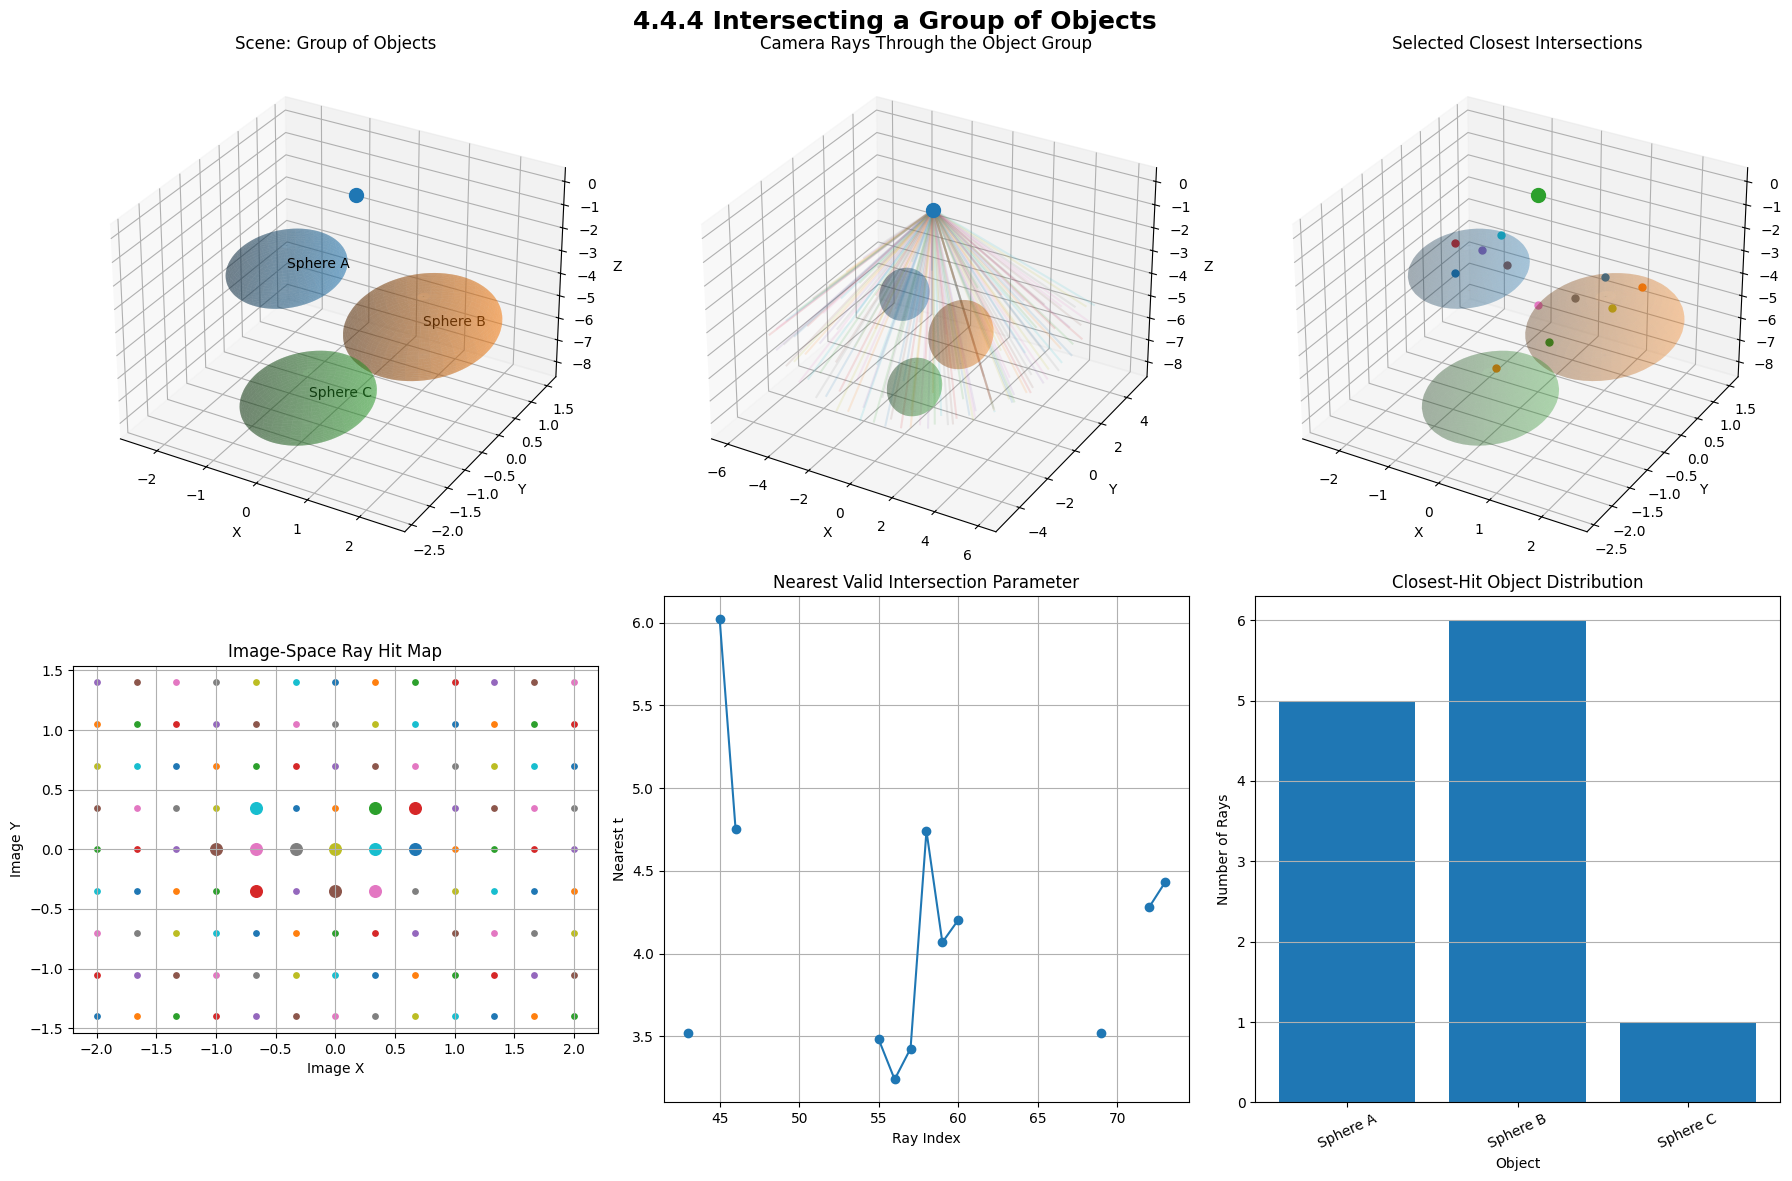

GROUP INTERSECTION ANALYSIS

Objects in group: 3
Rays evaluated:   117
Rays with hits:   12

Hit distribution:
Sphere A    :   5 rays
Sphere B    :   6 rays
Sphere C    :   1 rays

Closest-hit principle:
Nearest selected object: Sphere A
Minimum valid t: 3.240159
Intersection point: [-1.1254  0.     -3.0385]

Algorithm verification:
Each ray is tested against every object; the smallest valid t is retained.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 4.4.4 INTERSECTING A GROUP OF OBJECTS
#
# A group is treated as a composite object.
# For each ray:
#
#   1. Test every object.
#   2. Reject intersections outside [t0, t1].
#   3. Retain the smallest valid t.
#   4. Return the corresponding object and hit point.
# ==========================================================


# ==========================================================
# Scene Objects
# ==========================================================

objects = [
    {
        "name": "Sphere A",
        "type": "sphere",
        "center": np.array([-1.4, 0.0, -4.0]),
        "radius": 1.0
    },
    {
        "name": "Sphere B",
        "type": "sphere",
        "center": np.array([1.2, 0.2, -5.2]),
        "radius": 1.3
    },
    {
        "name": "Sphere C",
        "type": "sphere",
        "center": np.array([0.0, -1.3, -7.0]),
        "radius": 1.1
    }
]


# ==========================================================
# Ray-Sphere Intersection
# ==========================================================

def ray_sphere_intersection(
    origin,
    direction,
    center,
    radius,
    t0,
    t1
):

    oc = origin - center

    A = np.dot(direction, direction)

    B = 2.0 * np.dot(
        direction,
        oc
    )

    C = (
        np.dot(oc, oc)
        - radius ** 2
    )

    discriminant = (
        B ** 2
        - 4.0 * A * C
    )

    if discriminant < 0:
        return None

    sqrt_discriminant = np.sqrt(
        discriminant
    )

    roots = [
        (-B - sqrt_discriminant) / (2.0 * A),
        (-B + sqrt_discriminant) / (2.0 * A)
    ]

    valid = [
        t for t in roots
        if t0 <= t <= t1
    ]

    if not valid:
        return None

    return min(valid)


# ==========================================================
# Object Intersection
# ==========================================================

def intersect_object(
    origin,
    direction,
    obj,
    t0,
    t1
):

    if obj["type"] == "sphere":

        return ray_sphere_intersection(
            origin,
            direction,
            obj["center"],
            obj["radius"],
            t0,
            t1
        )

    return None


# ==========================================================
# Group Intersection
# ==========================================================

def intersect_group(
    origin,
    direction,
    objects,
    t0=0.001,
    t1=np.inf
):

    hit = False
    hit_object = None
    hit_t = t1

    for obj in objects:

        t = intersect_object(
            origin,
            direction,
            obj,
            t0,
            hit_t
        )

        if t is not None:

            hit = True
            hit_object = obj
            hit_t = t

    if not hit:
        return None

    hit_point = (
        origin
        + hit_t * direction
    )

    return {
        "object": hit_object,
        "t": hit_t,
        "point": hit_point
    }


# ==========================================================
# Camera
# ==========================================================

camera = np.array([
    0.0,
    0.0,
    0.0
])

look_at = np.array([
    0.0,
    0.0,
    -5.0
])

forward = (
    look_at - camera
)

forward = forward / np.linalg.norm(
    forward
)

up_reference = np.array([
    0.0,
    1.0,
    0.0
])

right = np.cross(
    forward,
    up_reference
)

right = right / np.linalg.norm(
    right
)

up = np.cross(
    right,
    forward
)

up = up / np.linalg.norm(
    up
)


# ==========================================================
# Generate Camera Rays
# ==========================================================

image_width = 13
image_height = 9

focal_length = 1.8

x_values = np.linspace(
    -2.0,
    2.0,
    image_width
)

y_values = np.linspace(
    -1.4,
    1.4,
    image_height
)

rays = []

for y in y_values:

    for x in x_values:

        direction = (
            focal_length * forward
            + x * right
            + y * up
        )

        direction = (
            direction
            / np.linalg.norm(direction)
        )

        rays.append(
            (x, y, direction)
        )


# ==========================================================
# Evaluate Every Camera Ray Against the Group
# ==========================================================

ray_results = []

for x, y, direction in rays:

    result = intersect_group(
        camera,
        direction,
        objects
    )

    if result is None:

        ray_results.append({
            "x": x,
            "y": y,
            "hit": False,
            "object": None,
            "t": np.inf,
            "point": None
        })

    else:

        ray_results.append({
            "x": x,
            "y": y,
            "hit": True,
            "object": result["object"]["name"],
            "t": result["t"],
            "point": result["point"]
        })


# ==========================================================
# Hit Statistics
# ==========================================================

total_rays = len(ray_results)

hit_results = [
    r for r in ray_results
    if r["hit"]
]

object_names = [
    obj["name"]
    for obj in objects
]

hit_counts = {
    name: sum(
        r["object"] == name
        for r in hit_results
    )
    for name in object_names
}


# ==========================================================
# Visualization
# Three Subplots per Row
# ==========================================================

fig = plt.figure(
    figsize=(18, 12)
)


# ==========================================================
# 1. Complete 3D Scene
# ==========================================================

ax1 = plt.subplot(
    2, 3, 1,
    projection="3d"
)

for obj in objects:

    center = obj["center"]
    radius = obj["radius"]

    phi = np.linspace(
        0,
        np.pi,
        40
    )

    theta = np.linspace(
        0,
        2 * np.pi,
        80
    )

    X = (
        center[0]
        + radius
        * np.outer(
            np.sin(phi),
            np.cos(theta)
        )
    )

    Y = (
        center[1]
        + radius
        * np.outer(
            np.sin(phi),
            np.sin(theta)
        )
    )

    Z = (
        center[2]
        + radius
        * np.outer(
            np.cos(phi),
            np.ones_like(theta)
        )
    )

    ax1.plot_surface(
        X,
        Y,
        Z,
        alpha=0.35
    )

    ax1.text(
        *center,
        obj["name"]
    )


ax1.scatter(
    *camera,
    s=100
)

ax1.set_title(
    "Scene: Group of Objects"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")


# ==========================================================
# 2. Camera Rays and Objects
# ==========================================================

ax2 = plt.subplot(
    2, 3, 2,
    projection="3d"
)

for obj in objects:

    center = obj["center"]
    radius = obj["radius"]

    phi = np.linspace(
        0,
        np.pi,
        25
    )

    theta = np.linspace(
        0,
        2 * np.pi,
        50
    )

    X = (
        center[0]
        + radius
        * np.outer(
            np.sin(phi),
            np.cos(theta)
        )
    )

    Y = (
        center[1]
        + radius
        * np.outer(
            np.sin(phi),
            np.sin(theta)
        )
    )

    Z = (
        center[2]
        + radius
        * np.outer(
            np.cos(phi),
            np.ones_like(theta)
        )
    )

    ax2.plot_surface(
        X,
        Y,
        Z,
        alpha=0.25
    )


ray_length = 8.0

for x, y, direction in rays:

    end = (
        camera
        + ray_length * direction
    )

    ax2.plot(
        [camera[0], end[0]],
        [camera[1], end[1]],
        [camera[2], end[2]],
        alpha=0.12
    )

ax2.scatter(
    *camera,
    s=100
)

ax2.set_title(
    "Camera Rays Through the Object Group"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")


# ==========================================================
# 3. Closest-Hit Points
# ==========================================================

ax3 = plt.subplot(
    2, 3, 3,
    projection="3d"
)

for obj in objects:

    center = obj["center"]
    radius = obj["radius"]

    phi = np.linspace(
        0,
        np.pi,
        25
    )

    theta = np.linspace(
        0,
        2 * np.pi,
        50
    )

    X = (
        center[0]
        + radius
        * np.outer(
            np.sin(phi),
            np.cos(theta)
        )
    )

    Y = (
        center[1]
        + radius
        * np.outer(
            np.sin(phi),
            np.sin(theta)
        )
    )

    Z = (
        center[2]
        + radius
        * np.outer(
            np.cos(phi),
            np.ones_like(theta)
        )
    )

    ax3.plot_surface(
        X,
        Y,
        Z,
        alpha=0.20
    )


for result in hit_results:

    point = result["point"]

    ax3.scatter(
        point[0],
        point[1],
        point[2],
        s=25
    )

ax3.scatter(
    *camera,
    s=100
)

ax3.set_title(
    "Selected Closest Intersections"
)

ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")


# ==========================================================
# 4. Image-Space Hit Map
# ==========================================================

ax4 = plt.subplot(
    2, 3, 4
)

for result in ray_results:

    x = result["x"]
    y = result["y"]

    if result["hit"]:

        ax4.scatter(
            x,
            y,
            s=70
        )

    else:

        ax4.scatter(
            x,
            y,
            s=15
        )

ax4.set_title(
    "Image-Space Ray Hit Map"
)

ax4.set_xlabel("Image X")
ax4.set_ylabel("Image Y")

ax4.set_aspect(
    "equal"
)

ax4.grid(True)


# ==========================================================
# 5. Closest t for Each Ray
# ==========================================================

ax5 = plt.subplot(
    2, 3, 5
)

t_values = [
    r["t"]
    if r["hit"]
    else np.nan
    for r in ray_results
]

ax5.plot(
    t_values,
    marker="o",
    linewidth=1.5
)

ax5.set_title(
    "Nearest Valid Intersection Parameter"
)

ax5.set_xlabel(
    "Ray Index"
)

ax5.set_ylabel(
    "Nearest t"
)

ax5.grid(True)


# ==========================================================
# 6. Object Hit Distribution
# ==========================================================

ax6 = plt.subplot(
    2, 3, 6
)

ax6.bar(
    list(hit_counts.keys()),
    list(hit_counts.values())
)

ax6.set_title(
    "Closest-Hit Object Distribution"
)

ax6.set_xlabel(
    "Object"
)

ax6.set_ylabel(
    "Number of Rays"
)

ax6.tick_params(
    axis="x",
    rotation=25
)

ax6.grid(
    axis="y"
)


# ==========================================================
# Layout
# ==========================================================

plt.suptitle(
    "4.4.4 Intersecting a Group of Objects",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ==========================================================
# Numerical Verification
# ==========================================================

print("=" * 70)
print("GROUP INTERSECTION ANALYSIS")
print("=" * 70)

print(f"\nObjects in group: {len(objects)}")
print(f"Rays evaluated:   {total_rays}")
print(f"Rays with hits:   {len(hit_results)}")

print("\nHit distribution:")

for name, count in hit_counts.items():

    print(
        f"{name:<12}: {count:>3} rays"
    )

print("\nClosest-hit principle:")

if hit_results:

    nearest = min(
        hit_results,
        key=lambda r: r["t"]
    )

    print(
        f"Nearest selected object: "
        f"{nearest['object']}"
    )

    print(
        f"Minimum valid t: "
        f"{nearest['t']:.6f}"
    )

    print(
        f"Intersection point: "
        f"{np.round(nearest['point'], 4)}"
    )

print("\nAlgorithm verification:")
print(
    "Each ray is tested against every object; "
    "the smallest valid t is retained."
)

## **4.5 Shading**

After the ray tracer finds the **visible surface** for a pixel, it must determine the pixel's **color**. This process is called **shading**.

**Shading models** simulate how **light interacts with a surface**. The complexity depends on the application, ranging from simple calculations to advanced numerical models.

A basic shading model uses a **point light source** and four important quantities:

- $l$ = **light direction**, a unit vector pointing from the surface toward the light.
- $v$ = **view direction**, a unit vector pointing from the surface toward the camera.
- $n$ = **surface normal**, a unit vector perpendicular to the surface.
- **Surface properties** = characteristics such as color and shininess.

The basic process is:

$$
\text{Visible Surface}+\text{Light}+\text{Surface Properties}
\rightarrow
\text{Pixel Color}
$$

Thus, **intersection determines what surface is visible, while shading determines how that surface appears.**

## **4.5.1 Lambertian Shading**

**Lambertian shading** is the simplest model for describing **diffuse reflection** from a surface. It states that illumination depends on the angle between the **surface normal** and the **light direction**.

- **Surface facing the light directly** → **maximum illumination**
- **Surface perpendicular to the light** → **zero illumination**
- **Intermediate angle** → illumination decreases according to the **cosine of the angle $\theta$**

The Lambertian equation is:

$$
L=k_d I\max(0,n\cdot l)
$$

### **Meaning of Symbols**

- $L$ = resulting pixel color
- $k_d$ = **diffuse coefficient or surface color**
- $I$ = **light intensity**
- $n$ = **unit surface normal**
- $l$ = **unit direction from the surface toward the light**
- $n\cdot l$ = **dot product**, equal to $\cos\theta$

The $\max(0,\ldots)$ prevents surfaces facing away from the light from receiving **negative illumination**.

---

### **Computing the Light Direction**

If the light position is $q$ and the surface intersection point is $p$:

$$
l=\frac{q-p}{\|q-p\|}
$$

The normalization is essential because $n$, $l$, and $v$ must be **unit vectors**.

The calculation is performed independently for the **red, green, and blue channels**.

$$
\text{Pixel Color}
=
\text{Surface Color}
\times
\text{Light Intensity}
\times
\max(0,n\cdot l)
$$

### **Core Concept**

**Lambertian shading makes a surface brightest when it directly faces the light and progressively darker as the surface turns away from the light.**

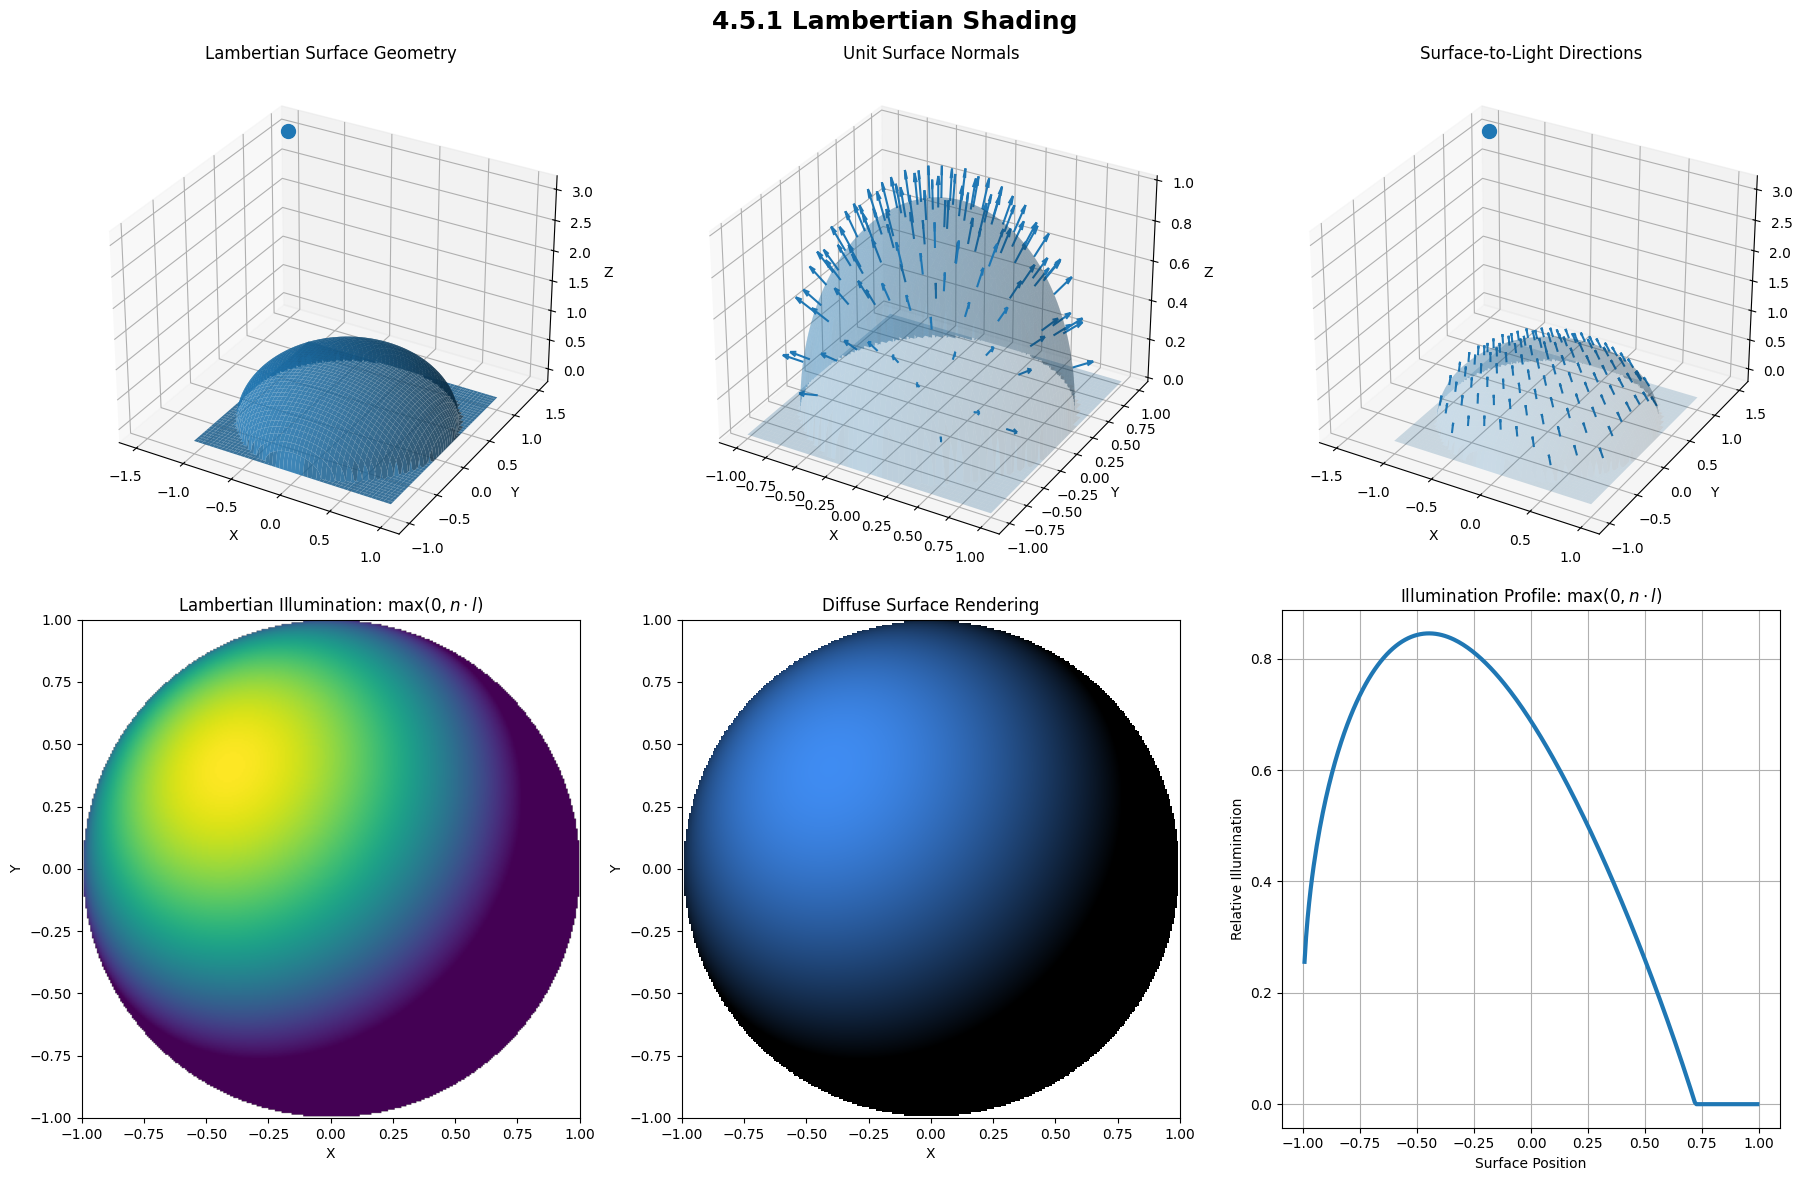

LAMBERTIAN SHADING ANALYSIS

Lambertian equation:
L = kd * I * max(0, n · l)

Surface color kd:
[0.25 0.55 0.95]

Light intensity I:
1.0

Maximum illumination:
0.999979

Minimum illumination:
0.000000

Mean illumination:
0.414053

Maximum rendered RGB:
[0.249995 0.549988 0.94998 ]

Verification:
Illumination is governed by the cosine of the angle between the unit surface normal and unit light direction, with negative values clamped to zero.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 4.5.1 LAMBERTIAN SHADING
#
# L = k_d I max(0, n · l)
#
# n : unit surface normal
# l : unit direction from surface to light
# k_d : diffuse surface color
# I : light intensity
# ==========================================================


# ==========================================================
# Vector Utilities
# ==========================================================

def normalize(v):
    return v / np.linalg.norm(v)


def lambertian_shading(
    normal,
    light_direction,
    diffuse_color,
    light_intensity
):
    normal = normalize(normal)
    light_direction = normalize(light_direction)

    illumination = max(
        0.0,
        np.dot(normal, light_direction)
    )

    color = (
        diffuse_color
        * light_intensity
        * illumination
    )

    return np.clip(color, 0.0, 1.0)


# ==========================================================
# Surface Geometry
# ==========================================================

resolution = 300

x = np.linspace(
    -1.0,
    1.0,
    resolution
)

y = np.linspace(
    -1.0,
    1.0,
    resolution
)

X, Y = np.meshgrid(
    x,
    y
)

inside = (
    X**2 + Y**2 <= 1.0
)

Z = np.zeros_like(X)

Z[inside] = np.sqrt(
    1.0
    - X[inside]**2
    - Y[inside]**2
)


# ==========================================================
# Surface Normals
# ==========================================================

normals = np.zeros(
    (resolution, resolution, 3)
)

normals[:, :, 0] = X
normals[:, :, 1] = Y
normals[:, :, 2] = Z

norm_lengths = np.linalg.norm(
    normals,
    axis=2,
    keepdims=True
)

normals = np.divide(
    normals,
    norm_lengths,
    out=np.zeros_like(normals),
    where=norm_lengths > 0
)


# ==========================================================
# Light Configuration
# ==========================================================

light_position = np.array([
    -1.5,
    1.5,
    3.0
])

surface_points = np.stack(
    [X, Y, Z],
    axis=-1
)

light_vectors = (
    light_position
    - surface_points
)

light_lengths = np.linalg.norm(
    light_vectors,
    axis=2,
    keepdims=True
)

light_directions = np.divide(
    light_vectors,
    light_lengths,
    out=np.zeros_like(light_vectors),
    where=light_lengths > 0
)


# ==========================================================
# Lambertian Illumination
# ==========================================================

dot_products = np.sum(
    normals * light_directions,
    axis=2
)

illumination = np.maximum(
    0.0,
    dot_products
)

illumination[~inside] = np.nan


# ==========================================================
# Surface Color and Light Intensity
# ==========================================================

diffuse_color = np.array([
    0.25,
    0.55,
    0.95
])

light_intensity = 1.0

lambert_color = (
    illumination[:, :, None]
    * diffuse_color
    * light_intensity
)

lambert_color = np.clip(
    lambert_color,
    0.0,
    1.0
)

lambert_color[~inside] = np.nan


# ==========================================================
# Analytical Cross-Section
# ==========================================================

center_row = resolution // 2

cross_section = illumination[
    center_row,
    :
]

valid_x = x[
    ~np.isnan(cross_section)
]

valid_illumination = cross_section[
    ~np.isnan(cross_section)
]


# ==========================================================
# Visualization
# Three Subplots per Row
# ==========================================================

fig = plt.figure(
    figsize=(18, 12)
)


# ==========================================================
# 1. Surface Geometry
# ==========================================================

ax1 = plt.subplot(
    2, 3, 1,
    projection="3d"
)

ax1.plot_surface(
    X,
    Y,
    Z,
    alpha=0.85
)

ax1.scatter(
    *light_position,
    s=100
)

ax1.set_title(
    "Lambertian Surface Geometry"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")


# ==========================================================
# 2. Surface Normals
# ==========================================================

ax2 = plt.subplot(
    2, 3, 2,
    projection="3d"
)

sample = 25

for i in range(
    0,
    resolution,
    sample
):

    for j in range(
        0,
        resolution,
        sample
    ):

        if inside[i, j]:

            p = surface_points[i, j]

            n = normals[i, j]

            ax2.quiver(
                p[0],
                p[1],
                p[2],
                n[0],
                n[1],
                n[2],
                length=0.15,
                normalize=True
            )

ax2.plot_surface(
    X,
    Y,
    Z,
    alpha=0.25
)

ax2.set_title(
    "Unit Surface Normals"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")


# ==========================================================
# 3. Light Direction Field
# ==========================================================

ax3 = plt.subplot(
    2, 3, 3,
    projection="3d"
)

for i in range(
    0,
    resolution,
    sample
):

    for j in range(
        0,
        resolution,
        sample
    ):

        if inside[i, j]:

            p = surface_points[i, j]

            l = light_directions[i, j]

            ax3.quiver(
                p[0],
                p[1],
                p[2],
                l[0],
                l[1],
                l[2],
                length=0.12,
                normalize=True
            )

ax3.plot_surface(
    X,
    Y,
    Z,
    alpha=0.20
)

ax3.scatter(
    *light_position,
    s=100
)

ax3.set_title(
    "Surface-to-Light Directions"
)

ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")


# ==========================================================
# 4. Lambertian Illumination
# ==========================================================

ax4 = plt.subplot(
    2, 3, 4
)

ax4.imshow(
    illumination,
    extent=[
        -1,
        1,
        -1,
        1
    ],
    origin="lower"
)

ax4.set_title(
    r"Lambertian Illumination: $\max(0,n\cdot l)$"
)

ax4.set_xlabel("X")
ax4.set_ylabel("Y")


# ==========================================================
# 5. Rendered Surface Color
# ==========================================================

ax5 = plt.subplot(
    2, 3, 5
)

ax5.imshow(
    lambert_color,
    extent=[
        -1,
        1,
        -1,
        1
    ],
    origin="lower"
)

ax5.set_title(
    "Diffuse Surface Rendering"
)

ax5.set_xlabel("X")
ax5.set_ylabel("Y")


# ==========================================================
# 6. Cosine Illumination Profile
# ==========================================================

ax6 = plt.subplot(
    2, 3, 6
)

ax6.plot(
    valid_x,
    valid_illumination,
    linewidth=3
)

ax6.set_title(
    r"Illumination Profile: $\max(0,n\cdot l)$"
)

ax6.set_xlabel(
    "Surface Position"
)

ax6.set_ylabel(
    "Relative Illumination"
)

ax6.grid(True)


# ==========================================================
# Layout
# ==========================================================

plt.suptitle(
    "4.5.1 Lambertian Shading",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ==========================================================
# Numerical Verification
# ==========================================================

print("=" * 70)
print("LAMBERTIAN SHADING ANALYSIS")
print("=" * 70)

print(
    "\nLambertian equation:"
)

print(
    "L = kd * I * max(0, n · l)"
)

print(
    "\nSurface color kd:"
)

print(
    diffuse_color
)

print(
    "\nLight intensity I:"
)

print(
    light_intensity
)

print(
    "\nMaximum illumination:"
)

print(
    f"{np.nanmax(illumination):.6f}"
)

print(
    "\nMinimum illumination:"
)

print(
    f"{np.nanmin(illumination):.6f}"
)

print(
    "\nMean illumination:"
)

print(
    f"{np.nanmean(illumination):.6f}"
)

print(
    "\nMaximum rendered RGB:"
)

print(
    np.round(
        np.nanmax(
            lambert_color,
            axis=(0, 1)
        ),
        6
    )
)

print(
    "\nVerification:"
)

print(
    "Illumination is governed by the cosine of the "
    "angle between the unit surface normal and unit "
    "light direction, with negative values clamped to zero."
)

## **4.5.2 Blinn-Phong Shading**

**Blinn-Phong shading** extends **Lambertian shading** by adding **specular reflection**, which produces visible highlights on shiny surfaces.

Lambertian shading is **view-independent** and produces a matte appearance. Blinn-Phong adds a component that changes with the **view direction**, allowing highlights to move when the camera moves.

---

### **Key Vectors**

- $n$ = **unit surface normal**
- $l$ = **unit direction toward the light**
- $v$ = **unit direction toward the camera**
- $h$ = **half vector**, halfway between $v$ and $l$
- $k_d$ = **diffuse/surface color**
- $k_s$ = **specular color**
- $I$ = **light intensity**
- $p$ = **Phong exponent**, controlling shininess

---

### **1. Compute the Half Vector**

Because $v$ and $l$ are unit vectors:

$$
h=\frac{v+l}{\|v+l\|}
$$

The **half vector $h$** represents the direction halfway between the viewer and the light.

---

### **2. Blinn-Phong Equation**

$$
L=k_d I\max(0,n\cdot l)+k_s I\max(0,n\cdot h)^p
$$

The first term,

$$
k_d I\max(0,n\cdot l)
$$

is the **Lambertian diffuse component**.

The second term,

$$
k_s I\max(0,n\cdot h)^p
$$

is the **specular component** that creates the highlight.

---

### **Role of $p$**

The exponent $p$ controls the apparent **shininess**:

- $p\approx10$ → **broad, soft highlight**
- $p\approx100$ → **moderately shiny**
- $p\approx1000$ → **very glossy**
- $p\approx10,000$ → **nearly mirror-like**

As $p$ increases, the highlight becomes **smaller and sharper**.

---

### **Core Concept**

$$
\boxed{
\text{Blinn-Phong}
=
\text{Diffuse Reflection}
+
\text{Specular Highlight}
}
$$

The **diffuse term** depends on $n\cdot l$, while the **specular term** depends on $n\cdot h$. This allows **Blinn-Phong shading to produce the shiny highlights that Lambertian shading cannot represent**.

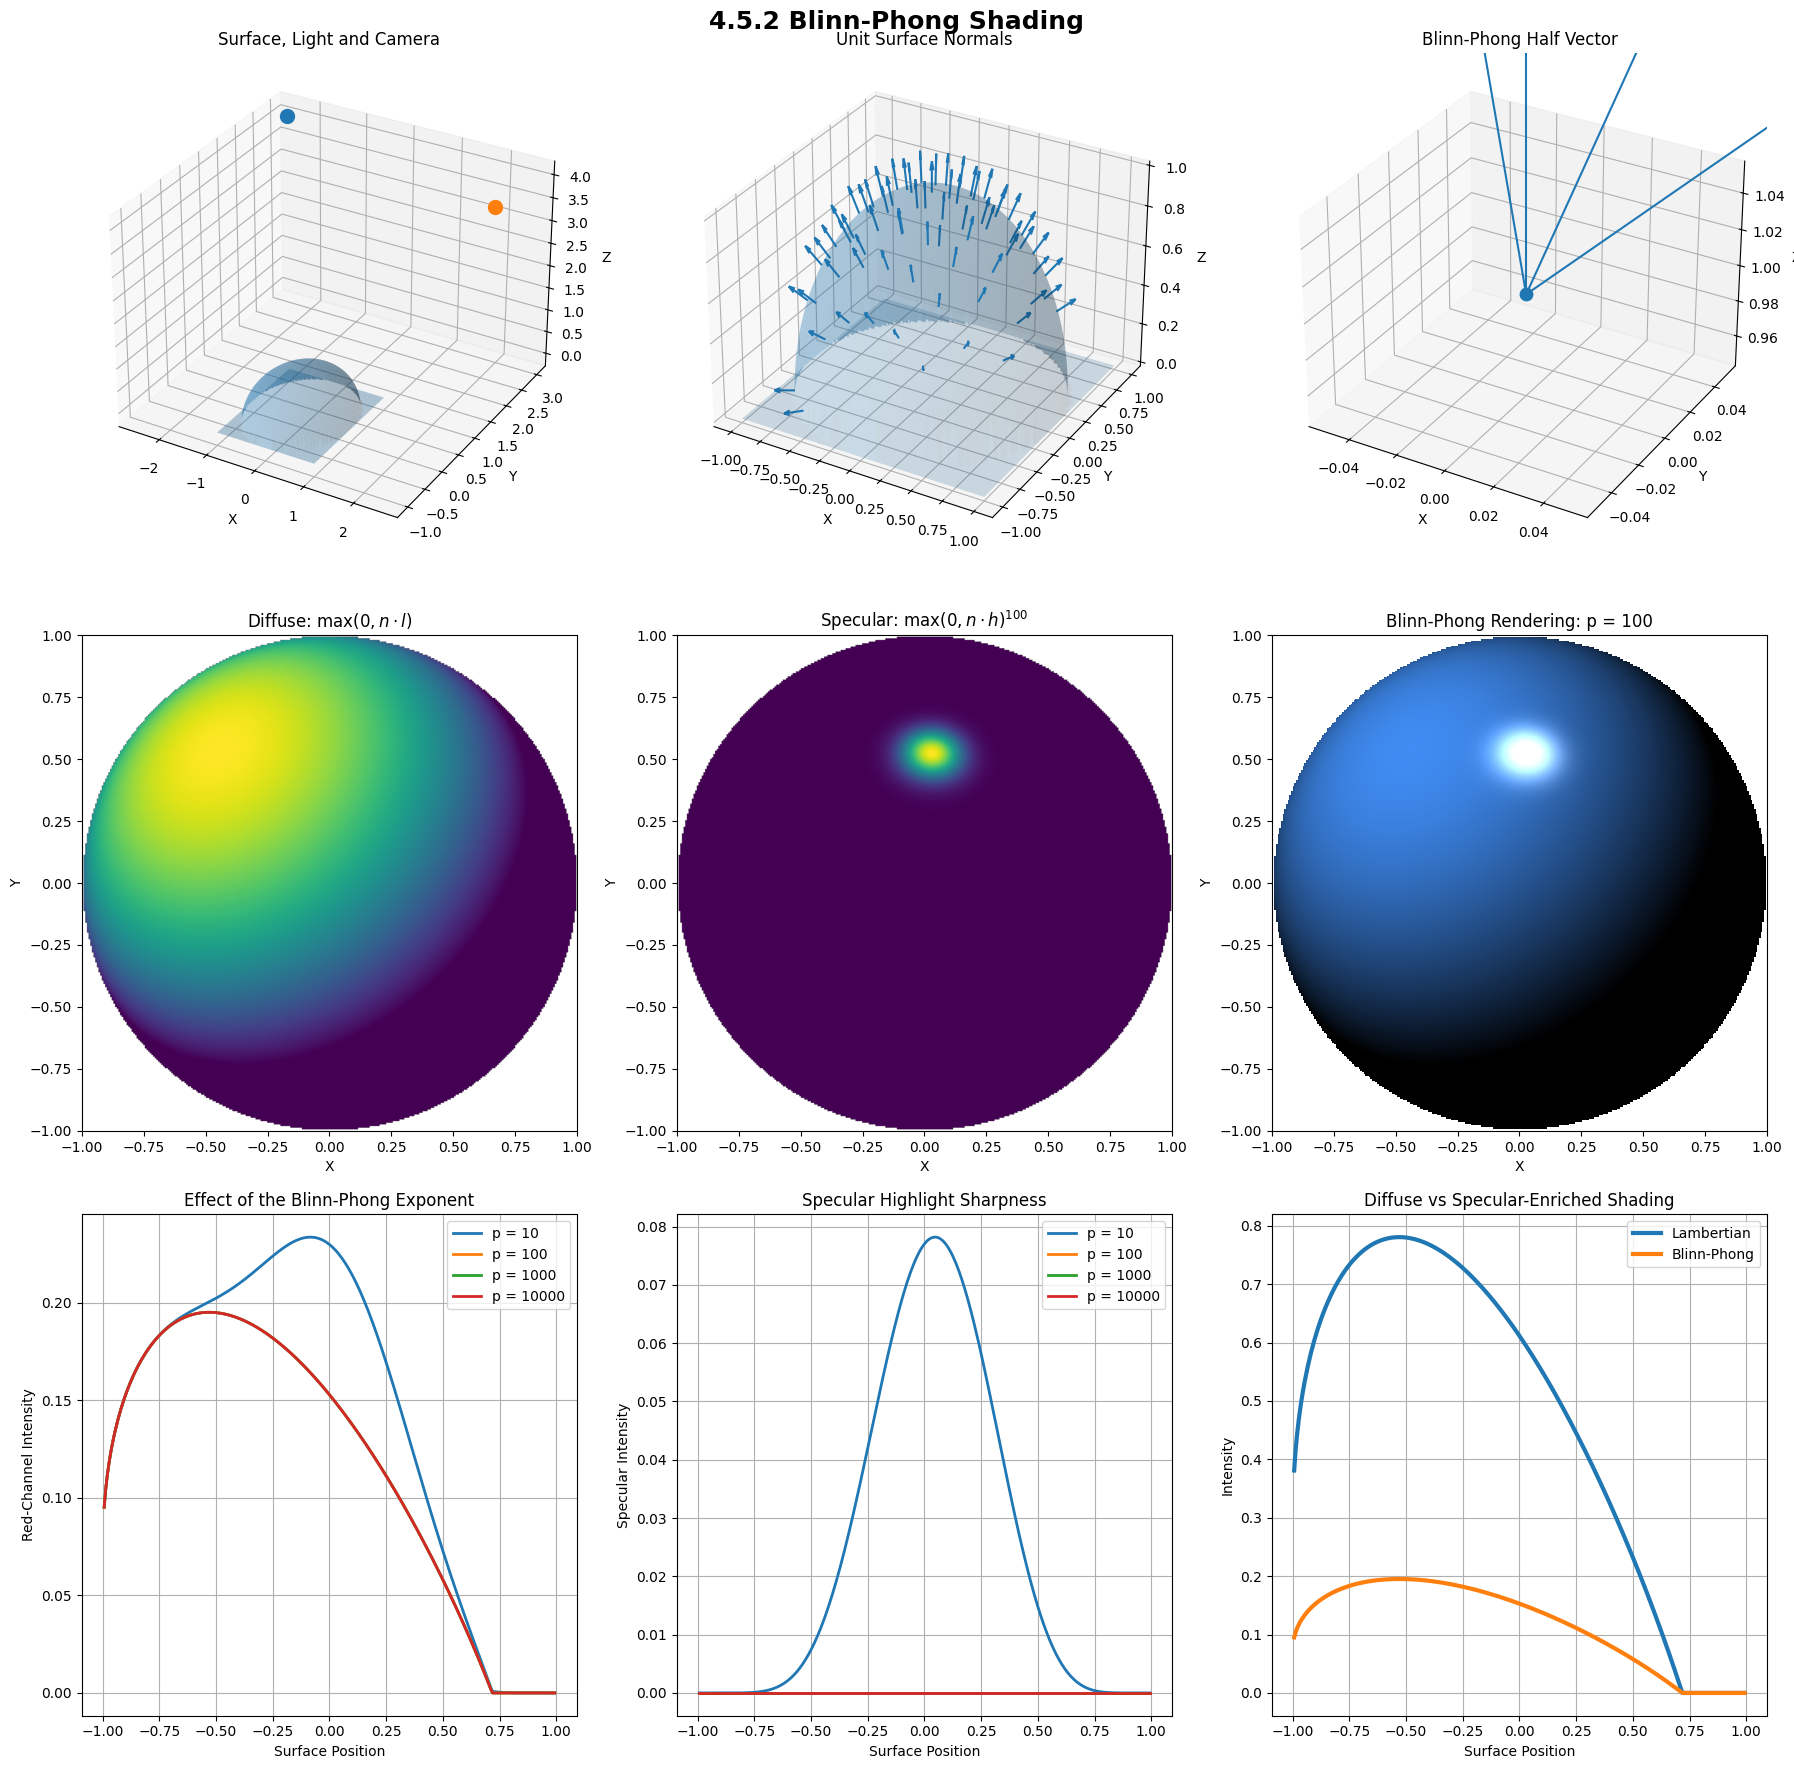

BLINN-PHONG SHADING ANALYSIS

Equation:
L = kd I max(0, n·l) + ks I max(0, n·h)^p

Half-vector:
h = normalize(v + l)

Material diffuse coefficient kd:
[0.25 0.55 0.95]

Material specular coefficient ks:
[1. 1. 1.]

Light intensity:
1.0

Shininess exponents:
[10, 100, 1000, 10000]

Maximum diffuse response:
0.999993

Maximum specular responses:
p = 10   : 0.999955
p = 100  : 0.999548
p = 1000 : 0.995489
p = 10000: 0.955795

Interpretation:
The diffuse component remains view-independent, while the specular component depends on the half-vector and becomes increasingly concentrated as p increases.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 4.5.2 BLINN-PHONG SHADING
#
# L = kd I max(0, n·l)
#     + ks I max(0, n·h)^p
#
# h = normalize(v + l)
# ==========================================================


# ==========================================================
# Vector Utilities
# ==========================================================

def normalize(v):
    norm = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.divide(
        v,
        norm,
        out=np.zeros_like(v, dtype=float),
        where=norm > 0
    )


def blinn_phong(
    normals,
    light_directions,
    view_directions,
    kd,
    ks,
    intensity,
    exponent
):
    n = normalize(normals)
    l = normalize(light_directions)
    v = normalize(view_directions)

    h = normalize(l + v)

    diffuse = np.maximum(
        0,
        np.sum(n * l, axis=-1)
    )

    specular = np.maximum(
        0,
        np.sum(n * h, axis=-1)
    ) ** exponent

    color = (
        kd * intensity * diffuse[..., None]
        + ks * intensity * specular[..., None]
    )

    return np.clip(color, 0, 1), diffuse, specular, h


# ==========================================================
# Spherical Surface
# ==========================================================

resolution = 300

x = np.linspace(-1, 1, resolution)
y = np.linspace(-1, 1, resolution)

X, Y = np.meshgrid(x, y)

inside = X**2 + Y**2 <= 1

Z = np.zeros_like(X)

Z[inside] = np.sqrt(
    1 - X[inside]**2 - Y[inside]**2
)

points = np.stack(
    [X, Y, Z],
    axis=-1
)

normals = normalize(points)


# ==========================================================
# Camera and Light
# ==========================================================

camera = np.array([
    2.5,
    2.0,
    4.0
])

light = np.array([
    -2.5,
    3.0,
    4.0
])

light_vectors = (
    light - points
)

view_vectors = (
    camera - points
)

light_directions = normalize(
    light_vectors
)

view_directions = normalize(
    view_vectors
)


# ==========================================================
# Material and Illumination
# ==========================================================

kd = np.array([
    0.25,
    0.55,
    0.95
])

ks = np.array([
    1.0,
    1.0,
    1.0
])

intensity = 1.0

exponents = [
    10,
    100,
    1000,
    10000
]

renderings = []
diffuse_maps = []
specular_maps = []

for p in exponents:

    color, diffuse, specular, h = blinn_phong(
        normals,
        light_directions,
        view_directions,
        kd,
        ks,
        intensity,
        p
    )

    color[~inside] = np.nan
    diffuse[~inside] = np.nan
    specular[~inside] = np.nan

    renderings.append(color)
    diffuse_maps.append(diffuse)
    specular_maps.append(specular)


# ==========================================================
# Reference Half Vector
# ==========================================================

reference_h = normalize(
    light_directions
    + view_directions
)


# ==========================================================
# Visualization
# Three Subplots per Row
# ==========================================================

fig = plt.figure(
    figsize=(18, 18)
)


# ==========================================================
# 1. Surface and Lighting Geometry
# ==========================================================

ax1 = plt.subplot(
    3, 3, 1,
    projection="3d"
)

ax1.plot_surface(
    X,
    Y,
    Z,
    alpha=0.35
)

ax1.scatter(
    *light,
    s=100
)

ax1.scatter(
    *camera,
    s=100
)

ax1.set_title(
    "Surface, Light and Camera"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")


# ==========================================================
# 2. Surface Normals
# ==========================================================

ax2 = plt.subplot(
    3, 3, 2,
    projection="3d"
)

step = 30

for i in range(
    0,
    resolution,
    step
):

    for j in range(
        0,
        resolution,
        step
    ):

        if inside[i, j]:

            point = points[i, j]
            normal = normals[i, j]

            ax2.quiver(
                *point,
                *normal,
                length=0.15,
                normalize=True
            )

ax2.plot_surface(
    X,
    Y,
    Z,
    alpha=0.2
)

ax2.set_title(
    "Unit Surface Normals"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")


# ==========================================================
# 3. Half-Vector Geometry
# ==========================================================

ax3 = plt.subplot(
    3, 3, 3,
    projection="3d"
)

sample_point = np.array([
    0.0,
    0.0,
    1.0
])

sample_normal = np.array([
    0.0,
    0.0,
    1.0
])

sample_l = normalize(
    light - sample_point
)

sample_v = normalize(
    camera - sample_point
)

sample_h = normalize(
    sample_l + sample_v
)

ax3.quiver(
    *sample_point,
    *sample_normal,
    length=1.0
)

ax3.quiver(
    *sample_point,
    *sample_l,
    length=1.0
)

ax3.quiver(
    *sample_point,
    *sample_v,
    length=1.0
)

ax3.quiver(
    *sample_point,
    *sample_h,
    length=1.0
)

ax3.scatter(
    *sample_point,
    s=80
)

ax3.set_title(
    "Blinn-Phong Half Vector"
)

ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")


# ==========================================================
# 4. Diffuse Component
# ==========================================================

ax4 = plt.subplot(
    3, 3, 4
)

ax4.imshow(
    diffuse_maps[1],
    extent=[
        -1,
        1,
        -1,
        1
    ],
    origin="lower"
)

ax4.set_title(
    r"Diffuse: $\max(0,n\cdot l)$"
)

ax4.set_xlabel("X")
ax4.set_ylabel("Y")


# ==========================================================
# 5. Specular Component
# ==========================================================

ax5 = plt.subplot(
    3, 3, 5
)

ax5.imshow(
    specular_maps[1],
    extent=[
        -1,
        1,
        -1,
        1
    ],
    origin="lower"
)

ax5.set_title(
    r"Specular: $\max(0,n\cdot h)^{100}$"
)

ax5.set_xlabel("X")
ax5.set_ylabel("Y")


# ==========================================================
# 6. Blinn-Phong Rendering
# ==========================================================

ax6 = plt.subplot(
    3, 3, 6
)

ax6.imshow(
    renderings[1],
    extent=[
        -1,
        1,
        -1,
        1
    ],
    origin="lower"
)

ax6.set_title(
    "Blinn-Phong Rendering: p = 100"
)

ax6.set_xlabel("X")
ax6.set_ylabel("Y")


# ==========================================================
# 7. Shininess Comparison
# ==========================================================

ax7 = plt.subplot(
    3, 3, 7
)

center = resolution // 2

for rendering, p in zip(
    renderings,
    exponents
):

    profile = rendering[
        center,
        :,
        0
    ]

    ax7.plot(
        x,
        profile,
        linewidth=2,
        label=f"p = {p}"
    )

ax7.set_title(
    "Effect of the Blinn-Phong Exponent"
)

ax7.set_xlabel(
    "Surface Position"
)

ax7.set_ylabel(
    "Red-Channel Intensity"
)

ax7.legend()
ax7.grid(True)


# ==========================================================
# 8. Specular Highlight Comparison
# ==========================================================

ax8 = plt.subplot(
    3, 3, 8
)

for specular, p in zip(
    specular_maps,
    exponents
):

    profile = specular[
        center,
        :
    ]

    ax8.plot(
        x,
        profile,
        linewidth=2,
        label=f"p = {p}"
    )

ax8.set_title(
    "Specular Highlight Sharpness"
)

ax8.set_xlabel(
    "Surface Position"
)

ax8.set_ylabel(
    "Specular Intensity"
)

ax8.legend()
ax8.grid(True)


# ==========================================================
# 9. Lambertian vs Blinn-Phong
# ==========================================================

ax9 = plt.subplot(
    3, 3, 9
)

lambert_profile = (
    diffuse_maps[1][center, :]
)

blinn_profile = (
    renderings[1][center, :, 0]
)

ax9.plot(
    x,
    lambert_profile,
    linewidth=3,
    label="Lambertian"
)

ax9.plot(
    x,
    blinn_profile,
    linewidth=3,
    label="Blinn-Phong"
)

ax9.set_title(
    "Diffuse vs Specular-Enriched Shading"
)

ax9.set_xlabel(
    "Surface Position"
)

ax9.set_ylabel(
    "Intensity"
)

ax9.legend()
ax9.grid(True)


# ==========================================================
# Layout
# ==========================================================

plt.suptitle(
    "4.5.2 Blinn-Phong Shading",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ==========================================================
# Numerical Verification
# ==========================================================

print("=" * 70)
print("BLINN-PHONG SHADING ANALYSIS")
print("=" * 70)

print(
    "\nEquation:"
)

print(
    "L = kd I max(0, n·l) + ks I max(0, n·h)^p"
)

print(
    "\nHalf-vector:"
)

print(
    "h = normalize(v + l)"
)

print(
    "\nMaterial diffuse coefficient kd:"
)

print(
    kd
)

print(
    "\nMaterial specular coefficient ks:"
)

print(
    ks
)

print(
    "\nLight intensity:"
)

print(
    intensity
)

print(
    "\nShininess exponents:"
)

print(
    exponents
)

print(
    "\nMaximum diffuse response:"
)

print(
    f"{np.nanmax(diffuse_maps[0]):.6f}"
)

print(
    "\nMaximum specular responses:"
)

for p, specular in zip(
    exponents,
    specular_maps
):

    print(
        f"p = {p:<5}: "
        f"{np.nanmax(specular):.6f}"
    )

print(
    "\nInterpretation:"
)

print(
    "The diffuse component remains view-independent, "
    "while the specular component depends on the "
    "half-vector and becomes increasingly concentrated "
    "as p increases."
)

## **4.5.3 Ambient Shading**

**Ambient shading** adds a **constant amount of light** to surfaces so that areas receiving no direct light do not appear completely black.

In the real world, surfaces can receive **indirect light** reflected from other surfaces. Ambient shading approximates this effect using a **simple constant term**.

The ambient contribution does **not depend on surface orientation, light direction, or viewing direction**. It depends only on the surface and the chosen ambient light.

---

### **Key Parameters**

- $k_a$ = **ambient coefficient** or ambient surface color
- $I_a$ = **ambient light intensity**
- $k_d$ = **diffuse coefficient**
- $I$ = **light intensity**
- $n$ = **surface normal**
- $l$ = **light direction**
- $k_s$ = **specular coefficient**
- $h$ = **half vector**
- $p$ = **shininess exponent**

---

### **Full Blinn-Phong Model with Ambient Shading**

$$
L=k_aI_a+k_dI\max(0,n\cdot l)+k_sI\max(0,n\cdot h)^p
$$

The three terms represent:

$$
\boxed{
\text{Ambient}+\text{Diffuse}+\text{Specular}
}
$$

- **Ambient:** $k_aI_a$ → prevents completely black surfaces
- **Diffuse:** $k_dI\max(0,n\cdot l)$ → depends on **light direction**
- **Specular:** $k_sI\max(0,n\cdot h)^p$ → produces **highlights**

---

### **Core Concept**

**Ambient shading is a simple approximation of indirect illumination.** It provides a **baseline amount of light** even when a surface receives no direct illumination.

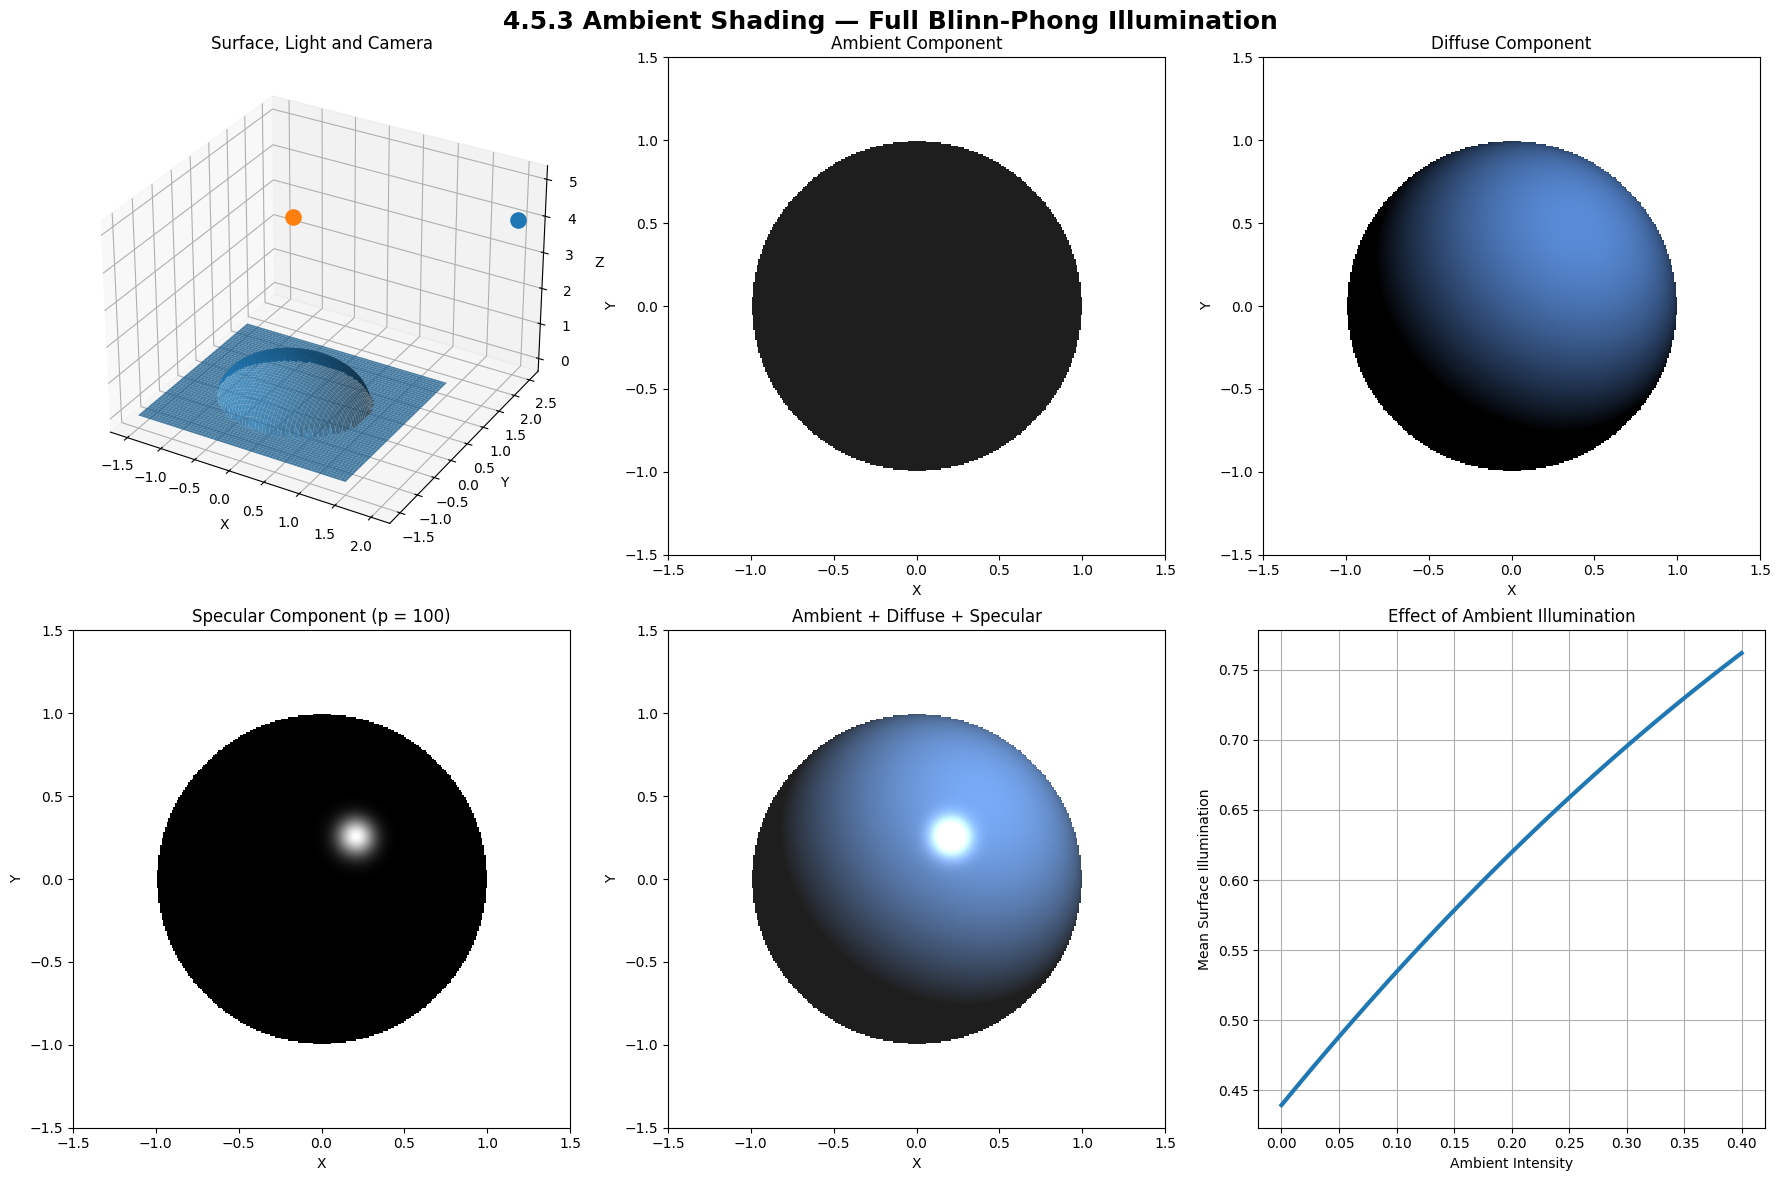

AMBIENT SHADING — BLINN-PHONG VERIFICATION

Ambient coefficient:
[0.12 0.12 0.12]

Diffuse coefficient:
[0.35 0.55 0.85]

Specular coefficient:
[1. 1. 1.]

Ambient intensity:
1.0

Light intensity:
1.0

Shininess exponent:
100

Ambient contribution:
ka × Ia = [0.12 0.12 0.12]

Diffuse range:
0.0000 → 0.8500

Specular range:
0.0000 → 0.9996

Final illumination range:
0.1200 → 1.0000

Model:
L = ka·Ia + kd·I·max(0,n·l) + ks·I·max(0,n·h)^p


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 4.5.3 AMBIENT SHADING
# Full Blinn-Phong model:
#
# L = ka*Ia
#     + kd*I*max(0, n·l)
#     + ks*I*max(0, n·h)^p
#
# Ambient + Diffuse + Specular
# ============================================================

# ------------------------------------------------------------
# Scene
# ------------------------------------------------------------

resolution = 300

x = np.linspace(-1.5, 1.5, resolution)
y = np.linspace(-1.5, 1.5, resolution)

X, Y = np.meshgrid(x, y)

R = 1.0
Z2 = R**2 - X**2 - Y**2

visible = Z2 >= 0
Z = np.zeros_like(X)
Z[visible] = np.sqrt(Z2[visible])

P = np.stack((X, Y, Z), axis=-1)

# ------------------------------------------------------------
# Surface normals
# ------------------------------------------------------------

N = np.zeros_like(P)
N[visible] = P[visible] / R

# ------------------------------------------------------------
# Light and camera
# ------------------------------------------------------------

light_position = np.array([2.0, 2.5, 4.0])
camera_position = np.array([0.0, 0.0, 5.0])

L_vector = light_position - P
L_norm = np.linalg.norm(L_vector, axis=-1, keepdims=True)

L_dir = np.divide(
    L_vector,
    L_norm,
    out=np.zeros_like(L_vector),
    where=L_norm > 0
)

V_vector = camera_position - P
V_norm = np.linalg.norm(V_vector, axis=-1, keepdims=True)

V_dir = np.divide(
    V_vector,
    V_norm,
    out=np.zeros_like(V_vector),
    where=V_norm > 0
)

# ------------------------------------------------------------
# Half vector
# ------------------------------------------------------------

H_vector = L_dir + V_dir
H_norm = np.linalg.norm(H_vector, axis=-1, keepdims=True)

H_dir = np.divide(
    H_vector,
    H_norm,
    out=np.zeros_like(H_vector),
    where=H_norm > 0
)

# ------------------------------------------------------------
# Material and lighting parameters
# ------------------------------------------------------------

ka = np.array([0.12, 0.12, 0.12])
kd = np.array([0.35, 0.55, 0.85])
ks = np.array([1.0, 1.0, 1.0])

Ia = 1.0
I = 1.0
p = 100

# ------------------------------------------------------------
# Lighting components
# ------------------------------------------------------------

N_dot_L = np.sum(N * L_dir, axis=-1)
N_dot_L = np.maximum(N_dot_L, 0)

N_dot_H = np.sum(N * H_dir, axis=-1)
N_dot_H = np.maximum(N_dot_H, 0)

ambient = ka * Ia

diffuse = (
    kd[None, None, :]
    * I
    * N_dot_L[:, :, None]
)

specular = (
    ks[None, None, :]
    * I
    * N_dot_H[:, :, None] ** p
)

# ------------------------------------------------------------
# Full Blinn-Phong illumination
# ------------------------------------------------------------

ambient_image = np.zeros_like(P)
diffuse_image = np.zeros_like(P)
specular_image = np.zeros_like(P)
final_image = np.zeros_like(P)

ambient_image[visible] = ambient

diffuse_image[visible] = diffuse[visible]

specular_image[visible] = specular[visible]

final_image = (
    ambient_image
    + diffuse_image
    + specular_image
)

final_image = np.clip(
    final_image,
    0,
    1
)

# ------------------------------------------------------------
# Mask background
# ------------------------------------------------------------

ambient_display = ambient_image.copy()
diffuse_display = diffuse_image.copy()
specular_display = specular_image.copy()

ambient_display[~visible] = np.nan
diffuse_display[~visible] = np.nan
specular_display[~visible] = np.nan
final_image[~visible] = np.nan

# ============================================================
# Visualization
# Three subplots per row
# ============================================================

fig = plt.figure(figsize=(18, 12))

# ------------------------------------------------------------
# 1. Geometry
# ------------------------------------------------------------

ax1 = plt.subplot(
    2, 3, 1,
    projection="3d"
)

surface = ax1.plot_surface(
    X,
    Y,
    Z,
    rstride=5,
    cstride=5,
    alpha=0.8
)

ax1.scatter(
    *light_position,
    s=120
)

ax1.scatter(
    *camera_position,
    s=120
)

ax1.set_title("Surface, Light and Camera")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# ------------------------------------------------------------
# 2. Ambient Component
# ------------------------------------------------------------

ax2 = plt.subplot(2, 3, 2)

ax2.imshow(
    ambient_display,
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax2.set_title("Ambient Component")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")

# ------------------------------------------------------------
# 3. Diffuse Component
# ------------------------------------------------------------

ax3 = plt.subplot(2, 3, 3)

ax3.imshow(
    diffuse_display,
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax3.set_title("Diffuse Component")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")

# ------------------------------------------------------------
# 4. Specular Component
# ------------------------------------------------------------

ax4 = plt.subplot(2, 3, 4)

ax4.imshow(
    specular_display,
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax4.set_title(
    f"Specular Component (p = {p})"
)

ax4.set_xlabel("X")
ax4.set_ylabel("Y")

# ------------------------------------------------------------
# 5. Full Blinn-Phong Model
# ------------------------------------------------------------

ax5 = plt.subplot(2, 3, 5)

ax5.imshow(
    final_image,
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax5.set_title(
    "Ambient + Diffuse + Specular"
)

ax5.set_xlabel("X")
ax5.set_ylabel("Y")

# ------------------------------------------------------------
# 6. Ambient Influence
# ------------------------------------------------------------

ambient_levels = np.linspace(
    0,
    0.4,
    100
)

surface_response = []

for ambient_level in ambient_levels:

    image = (
        ambient_level
        + N_dot_L
    )

    image = np.clip(
        image,
        0,
        1
    )

    surface_response.append(
        np.mean(
            image[visible]
        )
    )

ax6 = plt.subplot(2, 3, 6)

ax6.plot(
    ambient_levels,
    surface_response,
    linewidth=3
)

ax6.set_xlabel(
    "Ambient Intensity"
)

ax6.set_ylabel(
    "Mean Surface Illumination"
)

ax6.set_title(
    "Effect of Ambient Illumination"
)

ax6.grid(True)

plt.suptitle(
    "4.5.3 Ambient Shading — Full Blinn-Phong Illumination",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ============================================================
# Numerical Verification
# ============================================================

print("=" * 65)
print("AMBIENT SHADING — BLINN-PHONG VERIFICATION")
print("=" * 65)

print("\nAmbient coefficient:")
print(ka)

print("\nDiffuse coefficient:")
print(kd)

print("\nSpecular coefficient:")
print(ks)

print("\nAmbient intensity:")
print(Ia)

print("\nLight intensity:")
print(I)

print("\nShininess exponent:")
print(p)

print("\nAmbient contribution:")
print("ka × Ia =", ambient)

print("\nDiffuse range:")
print(
    f"{diffuse[visible].min():.4f}"
    f" → "
    f"{diffuse[visible].max():.4f}"
)

print("\nSpecular range:")
print(
    f"{specular[visible].min():.4f}"
    f" → "
    f"{specular[visible].max():.4f}"
)

print("\nFinal illumination range:")
print(
    f"{final_image[visible].min():.4f}"
    f" → "
    f"{final_image[visible].max():.4f}"
)

print("\nModel:")
print(
    "L = ka·Ia + kd·I·max(0,n·l)"
    " + ks·I·max(0,n·h)^p"
)

### **4.5.4 Multiple Point Lights**

A scene may contain **more than one point light source**. The contribution from each light can be calculated separately and then **added together**.

This follows the principle of **superposition**:

> **Total illumination = contribution from all individual lights**

For $N$ point lights, the Blinn-Phong model becomes:

$$
L=k_aI_a+\sum_{i=1}^{N}
\left[
k_dI_i\max(0,n\cdot l_i)
+
k_sI_i\max(0,n\cdot h_i)^p
\right]
$$

---

### **Meaning of the Symbols**

- $L$ = final pixel color
- $k_a$ = ambient coefficient/color of the surface
- $I_a$ = ambient light intensity
- $k_d$ = diffuse/surface color
- $k_s$ = specular color
- $I_i$ = intensity of the $i$-th light
- $l_i$ = unit direction from the surface toward the $i$-th light
- $h_i$ = half vector between the viewer direction $v$ and $l_i$
- $n$ = unit surface normal
- $p$ = Phong exponent controlling shininess
- $N$ = total number of point lights
- $i$ = index of the current light source

---

### **Understanding the Equation**

For **each light source**, two lighting contributions are calculated:

$$
k_dI_i\max(0,n\cdot l_i)
$$

**Diffuse contribution** — depends on the angle between the surface normal and the light.

$$
k_sI_i\max(0,n\cdot h_i)^p
$$

**Specular contribution** — produces the **shiny highlight**.

The contributions from all lights are summed:

$$
L=
\text{Ambient}
+
\text{Diffuse from all lights}
+
\text{Specular from all lights}
$$

For example, with three lights:

$$
L=k_aI_a+(D_1+S_1)+(D_2+S_2)+(D_3+S_3)
$$

where $D_i$ is the diffuse contribution and $S_i$ is the specular contribution from light $i$.

---

### **Core Concept**

$$
\boxed{
\text{Multiple-Light Shading}
=
\text{Ambient}
+
\sum(\text{Diffuse}+\text{Specular})
}
$$

This means **adding more point lights does not require a new shading model**; the same **Blinn-Phong calculation is simply repeated for each light and summed**.

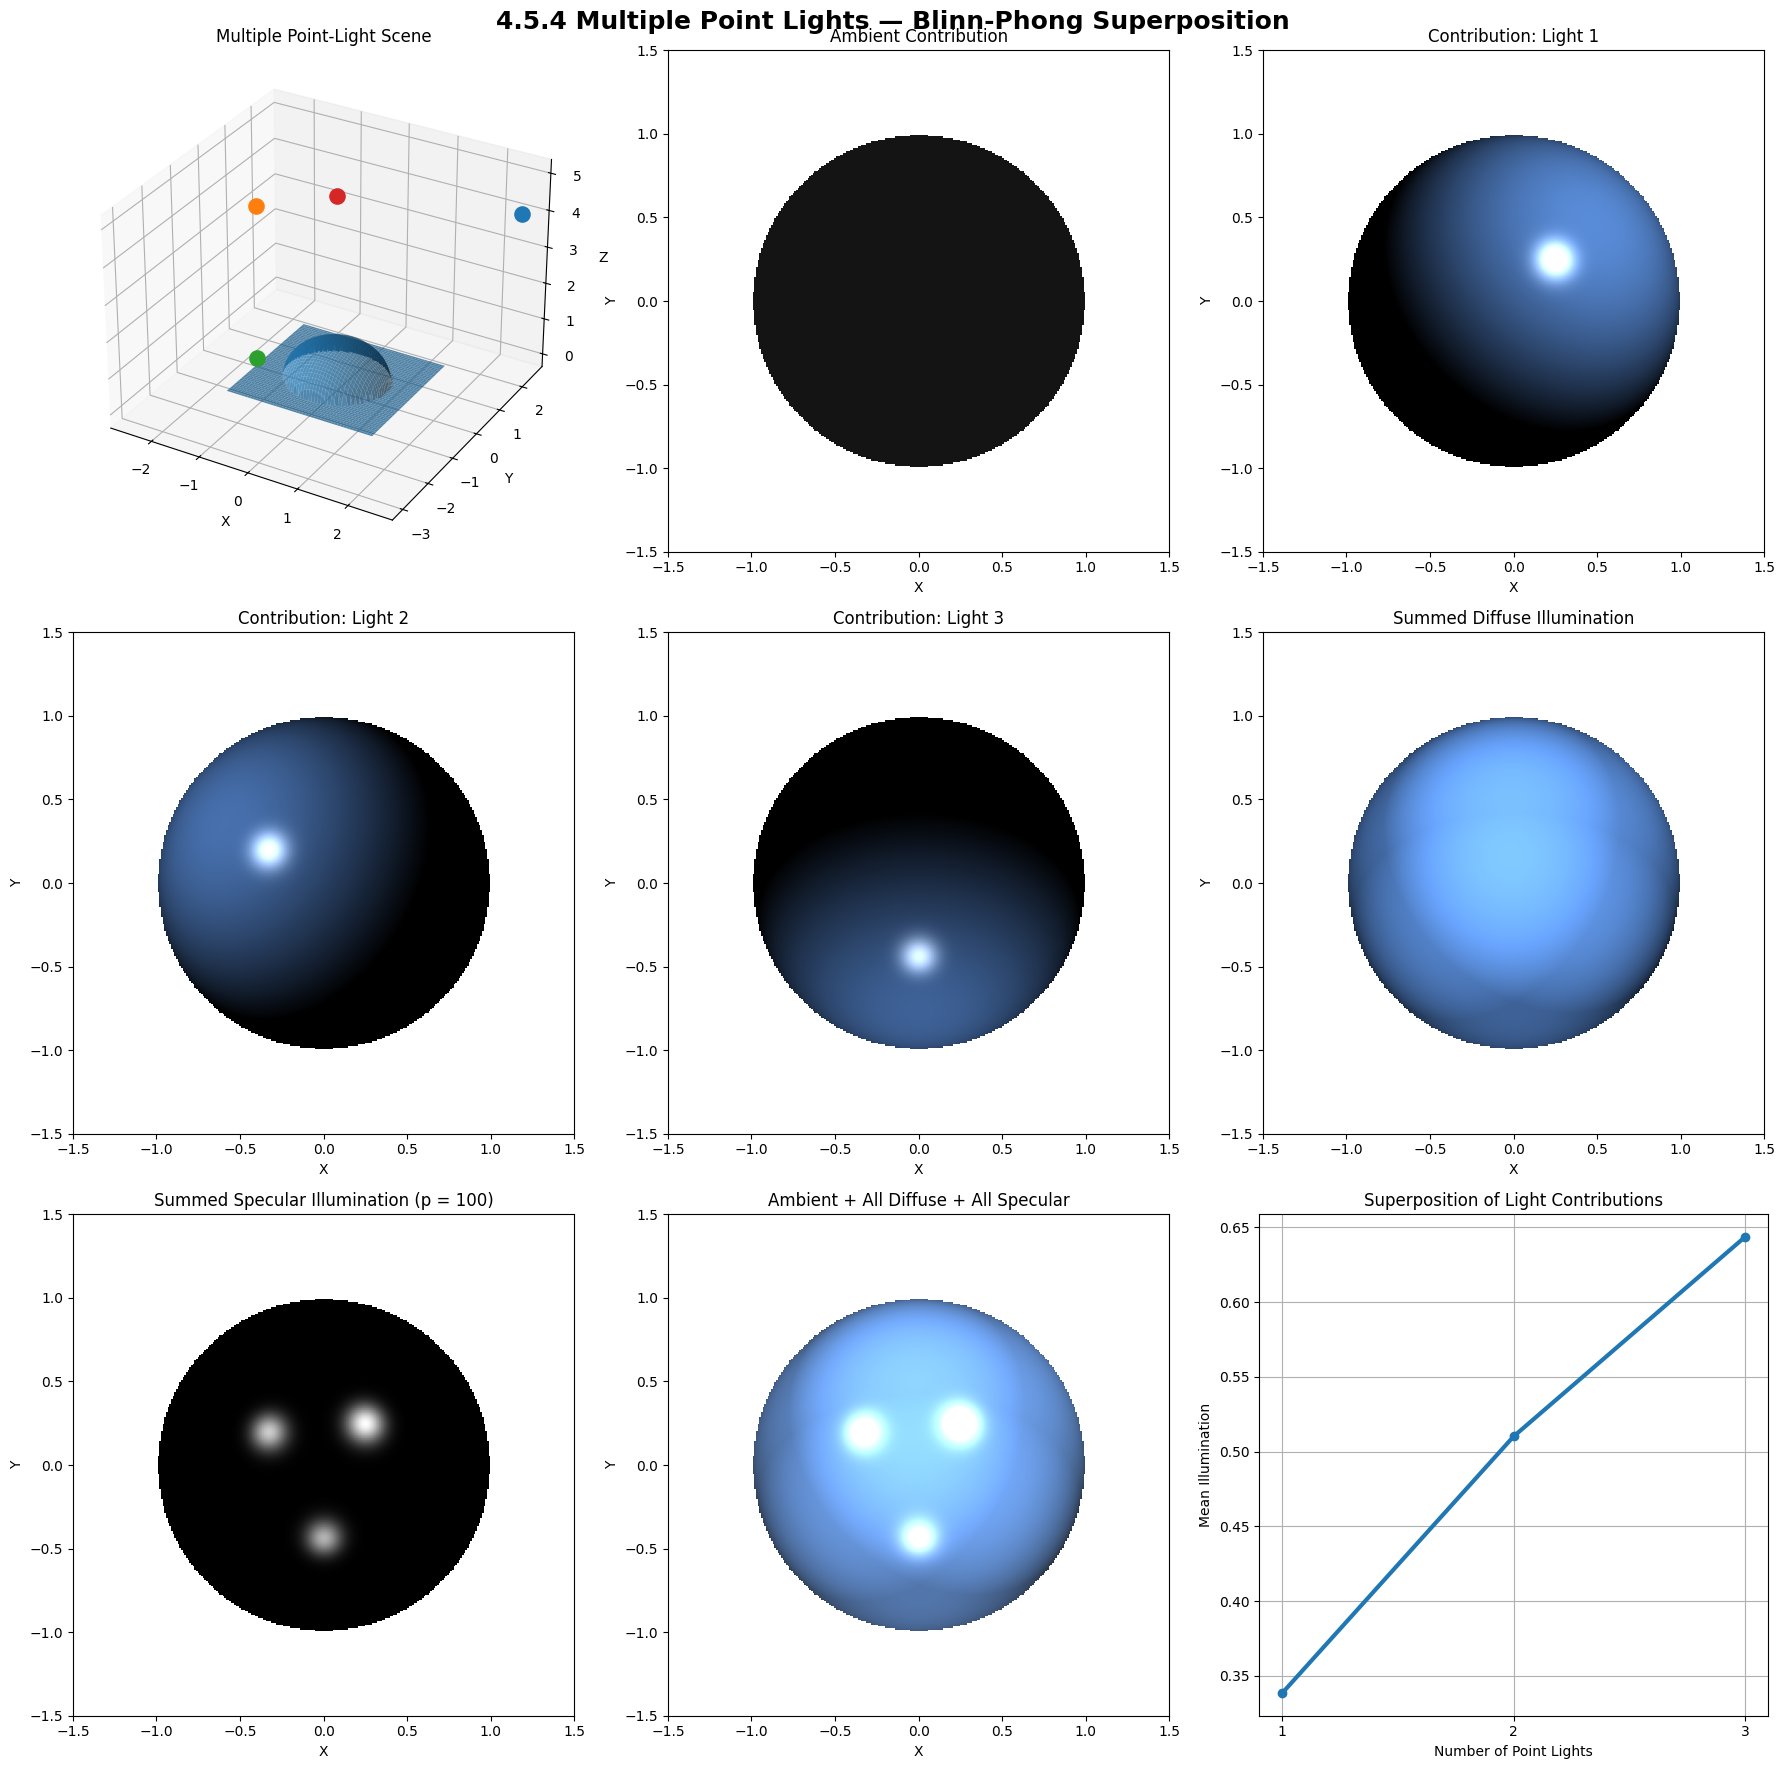

MULTIPLE POINT LIGHTS — BLINN-PHONG VERIFICATION

Number of point lights:
3

Ambient contribution:
ka × Ia = [0.08 0.08 0.08]

Light 1:
Position: [2.5 2.5 4. ]
Intensity: 1.0

Light 2:
Position: [-2.5  1.5  3. ]
Intensity: 0.8

Light 3:
Position: [ 0.  -3.   2.5]
Intensity: 0.7

Diffuse contribution range:
0.0347 → 1.2226

Specular contribution range:
0.0000 → 0.9988

Final illumination range:
0.1147 → 1.0000

Model:
L = ka·Ia + Σ[kd·Ii·max(0,n·li) + ks·Ii·max(0,n·hi)^p]

Superposition:
Total illumination = Ambient + Σ(Diffuse_i + Specular_i)


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 4.5.4 MULTIPLE POINT LIGHTS
#
# L = ka*Ia + Σ[kd*Ii*max(0,n·li)
#                + ks*Ii*max(0,n·hi)^p]
# ============================================================

resolution = 300

x = np.linspace(-1.5, 1.5, resolution)
y = np.linspace(-1.5, 1.5, resolution)

X, Y = np.meshgrid(x, y)

R = 1.0
Z2 = R**2 - X**2 - Y**2

visible = Z2 >= 0

Z = np.zeros_like(X)
Z[visible] = np.sqrt(Z2[visible])

P = np.stack((X, Y, Z), axis=-1)

# ============================================================
# Surface Normals
# ============================================================

N = np.zeros_like(P)
N[visible] = P[visible] / R

# ============================================================
# Camera
# ============================================================

camera_position = np.array([0.0, 0.0, 5.0])

V_vector = camera_position - P
V_norm = np.linalg.norm(
    V_vector,
    axis=-1,
    keepdims=True
)

V = np.divide(
    V_vector,
    V_norm,
    out=np.zeros_like(V_vector),
    where=V_norm > 0
)

# ============================================================
# Multiple Point Lights
# ============================================================

lights = [
    {
        "position": np.array([2.5, 2.5, 4.0]),
        "intensity": 1.0
    },
    {
        "position": np.array([-2.5, 1.5, 3.0]),
        "intensity": 0.8
    },
    {
        "position": np.array([0.0, -3.0, 2.5]),
        "intensity": 0.7
    }
]

# ============================================================
# Material and Ambient Parameters
# ============================================================

ka = np.array([0.08, 0.08, 0.08])
kd = np.array([0.35, 0.55, 0.85])
ks = np.array([1.0, 1.0, 1.0])

Ia = 1.0
p = 100

# ============================================================
# Ambient Contribution
# ============================================================

ambient = ka * Ia

ambient_image = np.zeros_like(P)

ambient_image[visible] = ambient

# ============================================================
# Individual Light Contributions
# ============================================================

diffuse_components = []
specular_components = []
light_images = []

for light in lights:

    position = light["position"]
    intensity = light["intensity"]

    # --------------------------------------------------------
    # Light direction
    # --------------------------------------------------------

    L_vector = position - P

    L_norm = np.linalg.norm(
        L_vector,
        axis=-1,
        keepdims=True
    )

    L = np.divide(
        L_vector,
        L_norm,
        out=np.zeros_like(L_vector),
        where=L_norm > 0
    )

    # --------------------------------------------------------
    # Half vector
    # --------------------------------------------------------

    H_vector = L + V

    H_norm = np.linalg.norm(
        H_vector,
        axis=-1,
        keepdims=True
    )

    H = np.divide(
        H_vector,
        H_norm,
        out=np.zeros_like(H_vector),
        where=H_norm > 0
    )

    # --------------------------------------------------------
    # Diffuse
    # --------------------------------------------------------

    N_dot_L = np.sum(
        N * L,
        axis=-1
    )

    N_dot_L = np.maximum(
        N_dot_L,
        0
    )

    diffuse = (
        kd[None, None, :]
        * intensity
        * N_dot_L[:, :, None]
    )

    # --------------------------------------------------------
    # Specular
    # --------------------------------------------------------

    N_dot_H = np.sum(
        N * H,
        axis=-1
    )

    N_dot_H = np.maximum(
        N_dot_H,
        0
    )

    specular = (
        ks[None, None, :]
        * intensity
        * N_dot_H[:, :, None] ** p
    )

    # --------------------------------------------------------
    # Total contribution from current light
    # --------------------------------------------------------

    light_image = (
        diffuse
        + specular
    )

    diffuse_components.append(
        diffuse
    )

    specular_components.append(
        specular
    )

    light_images.append(
        light_image
    )

# ============================================================
# Superposition of All Point Lights
# ============================================================

diffuse_total = np.sum(
    diffuse_components,
    axis=0
)

specular_total = np.sum(
    specular_components,
    axis=0
)

final_image = (
    ambient_image
    + diffuse_total
    + specular_total
)

final_image = np.clip(
    final_image,
    0,
    1
)

# ============================================================
# Individual Light Visualization
# ============================================================

individual_light_images = []

for image in light_images:

    display = np.clip(
        image,
        0,
        1
    )

    display[~visible] = np.nan

    individual_light_images.append(
        display
    )

ambient_display = ambient_image.copy()
ambient_display[~visible] = np.nan

diffuse_display = diffuse_total.copy()
diffuse_display[~visible] = np.nan

specular_display = specular_total.copy()
specular_display[~visible] = np.nan

final_display = final_image.copy()
final_display[~visible] = np.nan

# ============================================================
# Visualization
# Three Subplots per Row
# ============================================================

fig = plt.figure(
    figsize=(18, 18)
)

# ------------------------------------------------------------
# 1. Scene and Light Positions
# ------------------------------------------------------------

ax1 = plt.subplot(
    3, 3, 1,
    projection="3d"
)

ax1.plot_surface(
    X,
    Y,
    Z,
    rstride=6,
    cstride=6,
    alpha=0.75
)

for light in lights:

    ax1.scatter(
        *light["position"],
        s=120
    )

ax1.scatter(
    *camera_position,
    s=120
)

ax1.set_title(
    "Multiple Point-Light Scene"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

# ------------------------------------------------------------
# 2. Ambient Contribution
# ------------------------------------------------------------

ax2 = plt.subplot(
    3, 3, 2
)

ax2.imshow(
    ambient_display,
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax2.set_title(
    "Ambient Contribution"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")

# ------------------------------------------------------------
# 3. Light 1
# ------------------------------------------------------------

ax3 = plt.subplot(
    3, 3, 3
)

ax3.imshow(
    individual_light_images[0],
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax3.set_title(
    "Contribution: Light 1"
)

ax3.set_xlabel("X")
ax3.set_ylabel("Y")

# ------------------------------------------------------------
# 4. Light 2
# ------------------------------------------------------------

ax4 = plt.subplot(
    3, 3, 4
)

ax4.imshow(
    individual_light_images[1],
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax4.set_title(
    "Contribution: Light 2"
)

ax4.set_xlabel("X")
ax4.set_ylabel("Y")

# ------------------------------------------------------------
# 5. Light 3
# ------------------------------------------------------------

ax5 = plt.subplot(
    3, 3, 5
)

ax5.imshow(
    individual_light_images[2],
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax5.set_title(
    "Contribution: Light 3"
)

ax5.set_xlabel("X")
ax5.set_ylabel("Y")

# ------------------------------------------------------------
# 6. Total Diffuse
# ------------------------------------------------------------

ax6 = plt.subplot(
    3, 3, 6
)

ax6.imshow(
    diffuse_display,
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax6.set_title(
    "Summed Diffuse Illumination"
)

ax6.set_xlabel("X")
ax6.set_ylabel("Y")

# ------------------------------------------------------------
# 7. Total Specular
# ------------------------------------------------------------

ax7 = plt.subplot(
    3, 3, 7
)

ax7.imshow(
    specular_display,
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax7.set_title(
    f"Summed Specular Illumination (p = {p})"
)

ax7.set_xlabel("X")
ax7.set_ylabel("Y")

# ------------------------------------------------------------
# 8. Full Multiple-Light Model
# ------------------------------------------------------------

ax8 = plt.subplot(
    3, 3, 8
)

ax8.imshow(
    final_display,
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin="lower"
)

ax8.set_title(
    "Ambient + All Diffuse + All Specular"
)

ax8.set_xlabel("X")
ax8.set_ylabel("Y")

# ------------------------------------------------------------
# 9. Superposition Analysis
# ------------------------------------------------------------

light_count = np.arange(
    1,
    len(lights) + 1
)

mean_illumination = []

for k in light_count:

    partial = (
        ambient_image
        + np.sum(
            light_images[:k],
            axis=0
        )
    )

    partial = np.clip(
        partial,
        0,
        1
    )

    mean_illumination.append(
        np.mean(
            partial[visible]
        )
    )

ax9 = plt.subplot(
    3, 3, 9
)

ax9.plot(
    light_count,
    mean_illumination,
    marker="o",
    linewidth=3
)

ax9.set_xlabel(
    "Number of Point Lights"
)

ax9.set_ylabel(
    "Mean Illumination"
)

ax9.set_title(
    "Superposition of Light Contributions"
)

ax9.set_xticks(
    light_count
)

ax9.grid(True)

plt.suptitle(
    "4.5.4 Multiple Point Lights — Blinn-Phong Superposition",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ============================================================
# Numerical Verification
# ============================================================

print("=" * 70)
print("MULTIPLE POINT LIGHTS — BLINN-PHONG VERIFICATION")
print("=" * 70)

print("\nNumber of point lights:")
print(len(lights))

print("\nAmbient contribution:")
print("ka × Ia =", ambient)

for i, light in enumerate(lights, start=1):

    print(
        f"\nLight {i}:"
    )

    print(
        "Position:",
        light["position"]
    )

    print(
        "Intensity:",
        light["intensity"]
    )

print("\nDiffuse contribution range:")
print(
    f"{diffuse_total[visible].min():.4f}"
    f" → "
    f"{diffuse_total[visible].max():.4f}"
)

print("\nSpecular contribution range:")
print(
    f"{specular_total[visible].min():.4f}"
    f" → "
    f"{specular_total[visible].max():.4f}"
)

print("\nFinal illumination range:")
print(
    f"{final_image[visible].min():.4f}"
    f" → "
    f"{final_image[visible].max():.4f}"
)

print("\nModel:")
print(
    "L = ka·Ia + Σ[kd·Ii·max(0,n·li)"
    " + ks·Ii·max(0,n·hi)^p]"
)

print("\nSuperposition:")
print(
    "Total illumination = "
    "Ambient + Σ(Diffuse_i + Specular_i)"
)

## **4.7 Shadows**

Once a basic ray tracer can generate viewing rays, find intersections, and shade surfaces, **shadows** can be added by determining whether a light source is **blocked by another object**.

Suppose a ray hits a surface at point $p$. Let $l$ be the direction from $p$ toward the light.

We send a new ray from $p$ in direction $l$:

$$
p+tl
$$

This is called a **shadow ray**.

---

### **Meaning of the Symbols**

- $p$ = point on the surface being shaded
- $l$ = direction from the surface toward the light
- $t$ = ray parameter
- $p+tl$ = shadow ray
- $\epsilon$ = small positive value used to avoid **numerical self-intersection**

---

### **Determining Whether a Point Is in Shadow**

If the shadow ray intersects another object **before reaching the light**, the light is blocked:

$$
\text{Object hit}\Rightarrow\text{point is in shadow}
$$

If the shadow ray does not hit an object:

$$
\text{No object hit}\Rightarrow\text{point is illuminated}
$$

Therefore:

```text
surface point p
      ↓
generate shadow ray p + tl
      ↓
does it hit another object?
   ↙             ↘
 yes              no
  ↓                ↓
shadow          illuminated

### **Why Use $\epsilon$?**

A naive implementation tests:

$$
t\in[0,\infty)
$$

However, because of **floating-point numerical errors**, the shadow ray can incorrectly intersect the **same surface from which it originated**.

To avoid this, start the intersection interval slightly away from the surface:

$$
t\in[\epsilon,\infty)
$$

where

$$
\epsilon>0
$$

is a **small positive constant**.

The shadow ray can therefore be written conceptually as:

$$
p+\epsilon l+tl
$$

or, equivalently, the ray begins at

$$
p+\epsilon l
$$

---

### **Shadow-Ray Shading Algorithm**

A simplified version of the ray-color procedure is:

```text
function raycolor(ray e + td, real t0, real t1)

    if scene hits ray in [t0, t1] then
        compute intersection point p
        compute surface normal n

        c = ambient component

        if shadow ray p + sl does NOT hit an object
           for s ∈ [ε, ∞) then

            compute half vector h

            c = c
                + diffuse component
                + specular component

        return c

    else
        return background color

### **Important Point**

The **ambient component is added whether the point is in shadow or not**.

If the point is **illuminated**, we add the diffuse and specular contributions:

$$
L=k_aI_a+k_dI\max(0,n\cdot l)+k_sI\max(0,n\cdot h)^p
$$

If the point is **in shadow**, the direct-light contributions are omitted, leaving approximately:

$$
L=k_aI_a
$$

Thus, in this simple model:

$$
\boxed{
\text{Shadow}
=
\text{light blocked}
\Rightarrow
\text{no direct diffuse/specular illumination}
}
$$

---

### **Multiple Light Sources**

With **multiple lights**, a separate shadow ray is tested for each light.

For every light $i$:

$$
\text{Generate shadow ray}
\rightarrow
\text{Test visibility}
\rightarrow
\text{Add light contribution if visible}
$$

This connects directly with **Section 4.5.4 Multiple Point Lights**: each light contributes **only when it is visible from the surface point**.

---

### **Viewing Ray vs. Shadow Ray**

| Ray | Purpose | Origin | Direction |
|---|---|---|---|
| **Viewing ray** | Finds the visible surface | Camera/viewpoint | Toward image pixel |
| **Shadow ray** | Determines whether light reaches the surface | Surface point $p$ | Toward light $l$ |

### **Core Concept**

$$
\boxed{
\text{Viewing ray determines visibility;}
\quad
\text{shadow ray determines illumination.}
}
$$

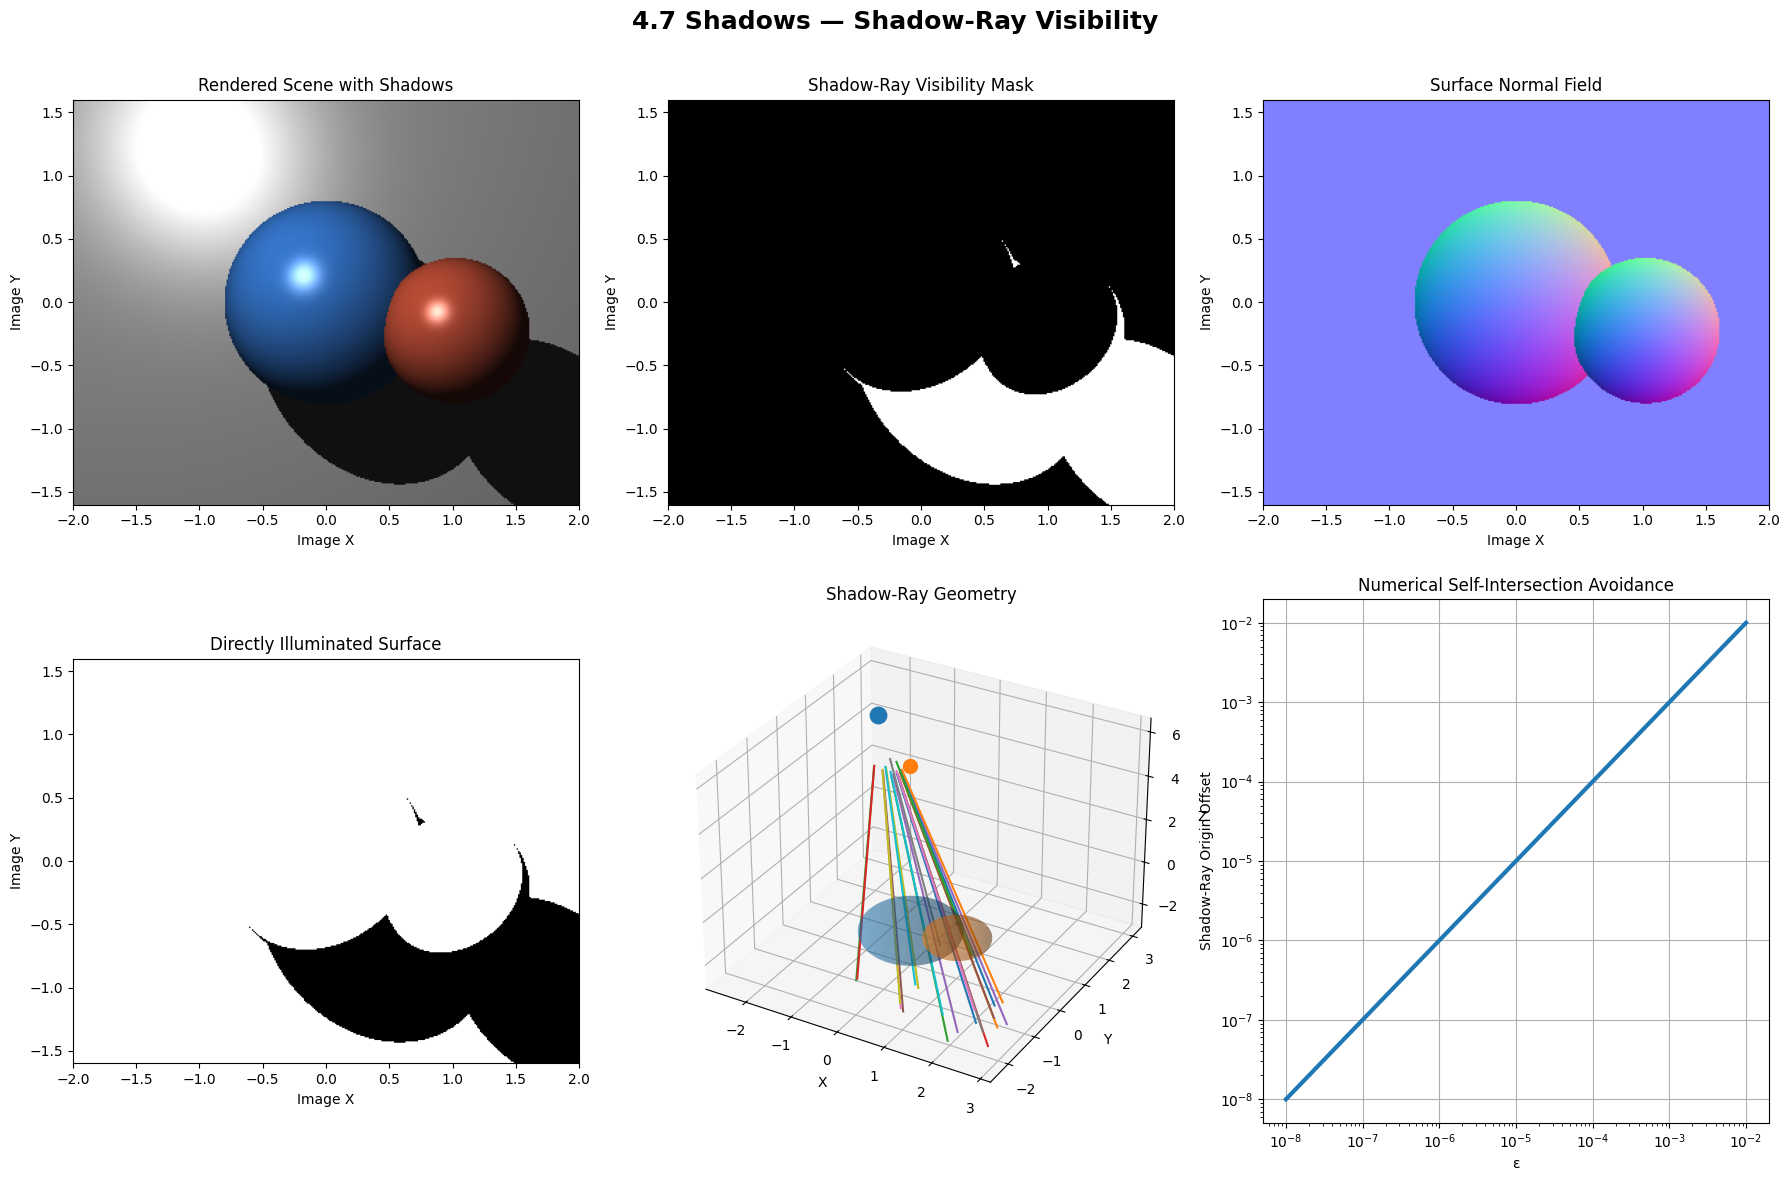

4.7 SHADOW-RAY VERIFICATION

Image resolution:
360 × 300

Number of visible surface pixels:
108000

Number of shadowed surface pixels:
16657

Number of directly illuminated pixels:
91343

Shadowed surface:
15.42%

Epsilon:
0.0001

Lighting model:
Shadowed:    L = ka × Ia
Illuminated: L = ka × Ia + kd × I × max(0,n·l) + ks × I × max(0,n·h)^p

Ray relationship:
Viewing ray → determines visible surface
Shadow ray → determines light visibility


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 4.7 SHADOWS
#
# Viewing ray:
#     r(t) = e + t d
#
# Shadow ray:
#     r(s) = p + s l
#
# A point is illuminated only when no object blocks the
# segment between the surface point and the light source.
# ============================================================

# ------------------------------------------------------------
# Image and Camera
# ------------------------------------------------------------

width = 360
height = 300

x = np.linspace(-2.0, 2.0, width)
y = np.linspace(-1.6, 1.6, height)

X, Y = np.meshgrid(x, y)

camera = np.array([0.0, 0.0, 6.0])

pixel_points = np.stack(
    (X, Y, np.zeros_like(X)),
    axis=-1
)

# ============================================================
# Scene Geometry
# ============================================================

objects = [
    {
        "center": np.array([0.0, 0.0, -1.5]),
        "radius": 1.0,
        "color": np.array([0.25, 0.55, 0.95])
    },
    {
        "center": np.array([1.15, -0.25, -0.8]),
        "radius": 0.65,
        "color": np.array([0.85, 0.35, 0.25])
    }
]

# Ground plane:
# z = -2.5

ground_z = -2.5
ground_color = np.array([0.65, 0.65, 0.65])

# ------------------------------------------------------------
# Lighting
# ------------------------------------------------------------

light_position = np.array(
    [-2.5, 3.0, 4.0]
)

light_intensity = 1.0

ka = 0.10
kd = 0.75
ks = 0.65

shininess = 80

epsilon = 1e-4

# ============================================================
# Ray-Sphere Intersection
# ============================================================

def ray_sphere_intersection(
    origin,
    direction,
    center,
    radius,
    t_min,
    t_max
):

    oc = origin - center

    A = np.dot(
        direction,
        direction
    )

    B = 2.0 * np.dot(
        oc,
        direction
    )

    C = (
        np.dot(oc, oc)
        - radius ** 2
    )

    discriminant = (
        B ** 2
        - 4.0 * A * C
    )

    if discriminant < 0:
        return None

    root = np.sqrt(
        discriminant
    )

    t1 = (
        -B - root
    ) / (2.0 * A)

    t2 = (
        -B + root
    ) / (2.0 * A)

    if t_min <= t1 <= t_max:
        return t1

    if t_min <= t2 <= t_max:
        return t2

    return None


# ============================================================
# Ray-Scene Intersection
# ============================================================

def scene_intersection(
    origin,
    direction,
    t_min=epsilon,
    t_max=np.inf
):

    closest_t = t_max
    hit_object = None

    for obj in objects:

        t = ray_sphere_intersection(
            origin,
            direction,
            obj["center"],
            obj["radius"],
            t_min,
            closest_t
        )

        if t is not None:

            closest_t = t
            hit_object = obj

    # --------------------------------------------------------
    # Ground plane intersection
    # --------------------------------------------------------

    if abs(direction[2]) > 1e-12:

        t_plane = (
            ground_z - origin[2]
        ) / direction[2]

        if (
            t_min <= t_plane <= closest_t
        ):

            point = (
                origin
                + t_plane * direction
            )

            return (
                t_plane,
                point,
                np.array([0.0, 0.0, 1.0]),
                ground_color
            )

    if hit_object is None:
        return None

    point = (
        origin
        + closest_t * direction
    )

    normal = (
        point
        - hit_object["center"]
    ) / hit_object["radius"]

    return (
        closest_t,
        point,
        normal,
        hit_object["color"]
    )


# ============================================================
# Shadow-Ray Test
# ============================================================

def is_shadowed(
    point,
    light_position
):

    to_light = (
        light_position
        - point
    )

    distance_to_light = np.linalg.norm(
        to_light
    )

    light_direction = (
        to_light
        / distance_to_light
    )

    shadow_origin = (
        point
        + epsilon * light_direction
    )

    hit = scene_intersection(
        shadow_origin,
        light_direction,
        t_min=epsilon,
        t_max=distance_to_light - epsilon
    )

    return hit is not None


# ============================================================
# Blinn-Phong Shading
# ============================================================

def shade(
    point,
    normal,
    surface_color,
    light_position
):

    view_direction = (
        camera - point
    )

    view_direction /= np.linalg.norm(
        view_direction
    )

    to_light = (
        light_position - point
    )

    distance_to_light = np.linalg.norm(
        to_light
    )

    light_direction = (
        to_light
        / distance_to_light
    )

    # --------------------------------------------------------
    # Ambient
    # --------------------------------------------------------

    ambient = (
        ka
        * surface_color
    )

    # --------------------------------------------------------
    # Shadow visibility
    # --------------------------------------------------------

    shadow = is_shadowed(
        point,
        light_position
    )

    if shadow:

        return ambient, True

    # --------------------------------------------------------
    # Diffuse
    # --------------------------------------------------------

    diffuse_factor = max(
        0.0,
        np.dot(
            normal,
            light_direction
        )
    )

    diffuse = (
        kd
        * surface_color
        * light_intensity
        * diffuse_factor
    )

    # --------------------------------------------------------
    # Half vector
    # --------------------------------------------------------

    half_vector = (
        light_direction
        + view_direction
    )

    half_vector /= np.linalg.norm(
        half_vector
    )

    # --------------------------------------------------------
    # Specular
    # --------------------------------------------------------

    specular_factor = max(
        0.0,
        np.dot(
            normal,
            half_vector
        )
    ) ** shininess

    specular = (
        ks
        * light_intensity
        * specular_factor
    )

    return (
        ambient
        + diffuse
        + specular,
        False
    )


# ============================================================
# Primary Ray Generation and Rendering
# ============================================================

image = np.zeros(
    (height, width, 3)
)

shadow_mask = np.zeros(
    (height, width),
    dtype=bool
)

hit_mask = np.zeros(
    (height, width),
    dtype=bool
)

surface_points = np.zeros(
    (height, width, 3)
)

surface_normals = np.zeros(
    (height, width, 3)
)

for row in range(height):

    for col in range(width):

        pixel = pixel_points[
            row,
            col
        ]

        direction = (
            pixel
            - camera
        )

        direction /= np.linalg.norm(
            direction
        )

        hit = scene_intersection(
            camera,
            direction,
            t_min=epsilon,
            t_max=np.inf
        )

        if hit is None:

            image[
                row,
                col
            ] = np.array(
                [0.04, 0.06, 0.10]
            )

            continue

        (
            t,
            point,
            normal,
            surface_color
        ) = hit

        hit_mask[
            row,
            col
        ] = True

        surface_points[
            row,
            col
        ] = point

        surface_normals[
            row,
            col
        ] = normal

        color, shadow = shade(
            point,
            normal,
            surface_color,
            light_position
        )

        image[
            row,
            col
        ] = np.clip(
            color,
            0,
            1
        )

        shadow_mask[
            row,
            col
        ] = shadow


# ============================================================
# Shadow-Ray Diagnostics
# ============================================================

visible_surface = hit_mask

shadow_surface = (
    shadow_mask
    & visible_surface
)

illuminated_surface = (
    visible_surface
    & ~shadow_mask
)

# ============================================================
# Visualization
# Three Subplots per Row
# ============================================================

fig = plt.figure(
    figsize=(18, 12)
)

# ------------------------------------------------------------
# 1. Rendered Scene
# ------------------------------------------------------------

ax1 = plt.subplot(
    2, 3, 1
)

ax1.imshow(
    image,
    origin="lower",
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ]
)

ax1.set_title(
    "Rendered Scene with Shadows"
)

ax1.set_xlabel("Image X")
ax1.set_ylabel("Image Y")

# ------------------------------------------------------------
# 2. Shadow Mask
# ------------------------------------------------------------

ax2 = plt.subplot(
    2, 3, 2
)

shadow_display = np.zeros(
    (height, width, 3)
)

shadow_display[
    shadow_surface
] = 1.0

ax2.imshow(
    shadow_display,
    origin="lower",
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ]
)

ax2.set_title(
    "Shadow-Ray Visibility Mask"
)

ax2.set_xlabel("Image X")
ax2.set_ylabel("Image Y")

# ------------------------------------------------------------
# 3. Surface Normals
# ------------------------------------------------------------

ax3 = plt.subplot(
    2, 3, 3
)

normal_display = (
    surface_normals
    + 1.0
) / 2.0

normal_display[
    ~visible_surface
] = 0

ax3.imshow(
    normal_display,
    origin="lower",
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ]
)

ax3.set_title(
    "Surface Normal Field"
)

ax3.set_xlabel("Image X")
ax3.set_ylabel("Image Y")

# ------------------------------------------------------------
# 4. Illuminated Surface
# ------------------------------------------------------------

ax4 = plt.subplot(
    2, 3, 4
)

illumination_display = np.zeros(
    (height, width, 3)
)

illumination_display[
    illuminated_surface
] = 1.0

ax4.imshow(
    illumination_display,
    origin="lower",
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ]
)

ax4.set_title(
    "Directly Illuminated Surface"
)

ax4.set_xlabel("Image X")
ax4.set_ylabel("Image Y")

# ------------------------------------------------------------
# 5. Shadow-Ray Geometry
# ------------------------------------------------------------

ax5 = plt.subplot(
    2, 3, 5,
    projection="3d"
)

u = np.linspace(
    0,
    2 * np.pi,
    60
)

v = np.linspace(
    0,
    np.pi,
    30
)

for obj in objects:

    c = obj["center"]
    r = obj["radius"]

    sx = (
        c[0]
        + r
        * np.outer(
            np.cos(u),
            np.sin(v)
        )
    )

    sy = (
        c[1]
        + r
        * np.outer(
            np.sin(u),
            np.sin(v)
        )
    )

    sz = (
        c[2]
        + r
        * np.outer(
            np.ones_like(u),
            np.cos(v)
        )
    )

    ax5.plot_surface(
        sx,
        sy,
        sz,
        alpha=0.35
    )

ax5.scatter(
    *light_position,
    s=140
)

ax5.scatter(
    *camera,
    s=100
)

# Representative shadow-ray samples

shadow_indices = np.argwhere(
    shadow_surface
)

if len(shadow_indices) > 0:

    step = max(
        1,
        len(shadow_indices) // 20
    )

    for row, col in shadow_indices[::step]:

        p = surface_points[
            row,
            col
        ]

        direction = (
            light_position - p
        )

        distance = np.linalg.norm(
            direction
        )

        direction /= distance

        end = (
            p
            + 0.8 * distance * direction
        )

        ax5.plot(
            [p[0], end[0]],
            [p[1], end[1]],
            [p[2], end[2]],
            linewidth=1.5
        )

ax5.set_title(
    "Shadow-Ray Geometry"
)

ax5.set_xlabel("X")
ax5.set_ylabel("Y")
ax5.set_zlabel("Z")

# ------------------------------------------------------------
# 6. Effect of Epsilon
# ------------------------------------------------------------

epsilon_values = np.logspace(
    -8,
    -2,
    100
)

# The theoretical purpose of epsilon:
# move the shadow-ray origin away from the surface.

offset_distances = (
    epsilon_values
)

ax6 = plt.subplot(
    2, 3, 6
)

ax6.loglog(
    epsilon_values,
    offset_distances,
    linewidth=3
)

ax6.set_xlabel(
    "ε"
)

ax6.set_ylabel(
    "Shadow-Ray Origin Offset"
)

ax6.set_title(
    "Numerical Self-Intersection Avoidance"
)

ax6.grid(True)

plt.suptitle(
    "4.7 Shadows — Shadow-Ray Visibility",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ============================================================
# Numerical Verification
# ============================================================

print("=" * 70)
print("4.7 SHADOW-RAY VERIFICATION")
print("=" * 70)

print("\nImage resolution:")
print(
    f"{width} × {height}"
)

print("\nNumber of visible surface pixels:")
print(
    np.sum(visible_surface)
)

print("\nNumber of shadowed surface pixels:")
print(
    np.sum(shadow_surface)
)

print("\nNumber of directly illuminated pixels:")
print(
    np.sum(illuminated_surface)
)

shadow_percentage = (
    100
    * np.sum(shadow_surface)
    / max(
        1,
        np.sum(visible_surface)
    )
)

print(
    "\nShadowed surface:"
)

print(
    f"{shadow_percentage:.2f}%"
)

print("\nEpsilon:")
print(
    epsilon
)

print("\nLighting model:")
print(
    "Shadowed:    L = ka × Ia"
)

print(
    "Illuminated: "
    "L = ka × Ia + kd × I × max(0,n·l)"
    " + ks × I × max(0,n·h)^p"
)

print("\nRay relationship:")
print(
    "Viewing ray → determines visible surface"
)

print(
    "Shadow ray → determines light visibility"
)

## **4.8 Ideal Specular Reflection**

**Ideal specular reflection** represents **perfect mirror reflection**. When a viewing ray reaches a reflective surface, instead of stopping at the surface, we generate a new **reflection ray** to determine what the mirror reflects.

---

### **Reflection Geometry**

Let:

- $d$ = direction of the incoming viewing ray, pointing **toward the surface**
- $n$ = **unit surface normal**
- $r$ = direction of the reflected ray
- $p$ = surface intersection point

The reflection direction is:

$$
r=d-2(d\cdot n)n
$$

---

### **How the Equation Works**

First calculate:

$$
d\cdot n
$$

This measures how much of $d$ lies along the **surface normal**.

Then:

$$
2(d\cdot n)n
$$

gives the normal-direction component that must be **removed twice** to reverse the direction appropriately.

Therefore:

$$
r=d-2(d\cdot n)n
$$

The resulting $r$ points away from the surface in the **mirror-reflection direction**.

---

### **Reflection Ray**

After finding the intersection point $p$, the reflection ray is:

$$
p+sr
$$

where $s$ is the ray parameter.

To avoid numerical self-intersection, use:

$$
s\in[\epsilon,\infty)
$$

where $\epsilon$ is a **small positive value**.

This is the same numerical precaution used for **shadow rays** in Section 4.7.

---

### **Recursive Reflection**

The reflected ray can itself hit another object. Therefore, the ray tracer can call `raycolor` again:

```text
c = c + km * raycolor(p + sr, ε, ∞)

where:

- $c$ = current pixel color
- $k_m$ = **mirror-reflection/specular RGB color**
- $p$ = reflection point
- $r$ = reflection direction
- $s$ = reflection-ray parameter
- $\epsilon$ = small positive offset
- `raycolor(...)` = traces the reflected ray and returns its color

Conceptually:

$$
\boxed{
\text{Surface Hit}
\rightarrow
\text{Compute }r
\rightarrow
\text{Trace Reflection Ray}
\rightarrow
\text{Add Reflected Color}
}
$$

### **Why $k_m$ Is Important**

The reflection coefficient $k_m$ controls **how much reflected color contributes**.

For example:

- $k_m=(0,0,0)$ → **no mirror reflection**
- **larger $k_m$** → **stronger reflection**
- **different RGB values** → reflection can affect colors differently

This allows materials to have **colored reflections**. For example, a material could reflect **red/green light more strongly than blue**.

---

### **Recursion Problem**

Reflection can produce another reflection, which can produce another reflection:

$$
\text{Ray}
\rightarrow
\text{Reflection}
\rightarrow
\text{Reflection}
\rightarrow
\text{Reflection}
\rightarrow
\cdots
$$

Without a stopping condition, the recursive ray tracer could continue **indefinitely**.

Therefore, introduce a **maximum recursion depth**:

```text
if recursion_depth < maximum_depth
    trace reflection ray
else
    stop reflection

It is also more efficient to generate a reflection ray only when:

$$
k_m\neq0
$$

because a **black reflection coefficient** means that the surface contributes **no reflected light**.

### **Core Concept**

$$
\boxed{
\text{Ideal Specular Reflection}
=
\text{Reflection Direction}
+
\text{Recursive Ray Tracing}
}
$$

The essential mathematical operation is:

$$
r=d-2(d\cdot n)n
$$

and the essential rendering operation is:

$$
\boxed{
\text{Trace }p+sr
\text{ and add its reflected color}
}
$$

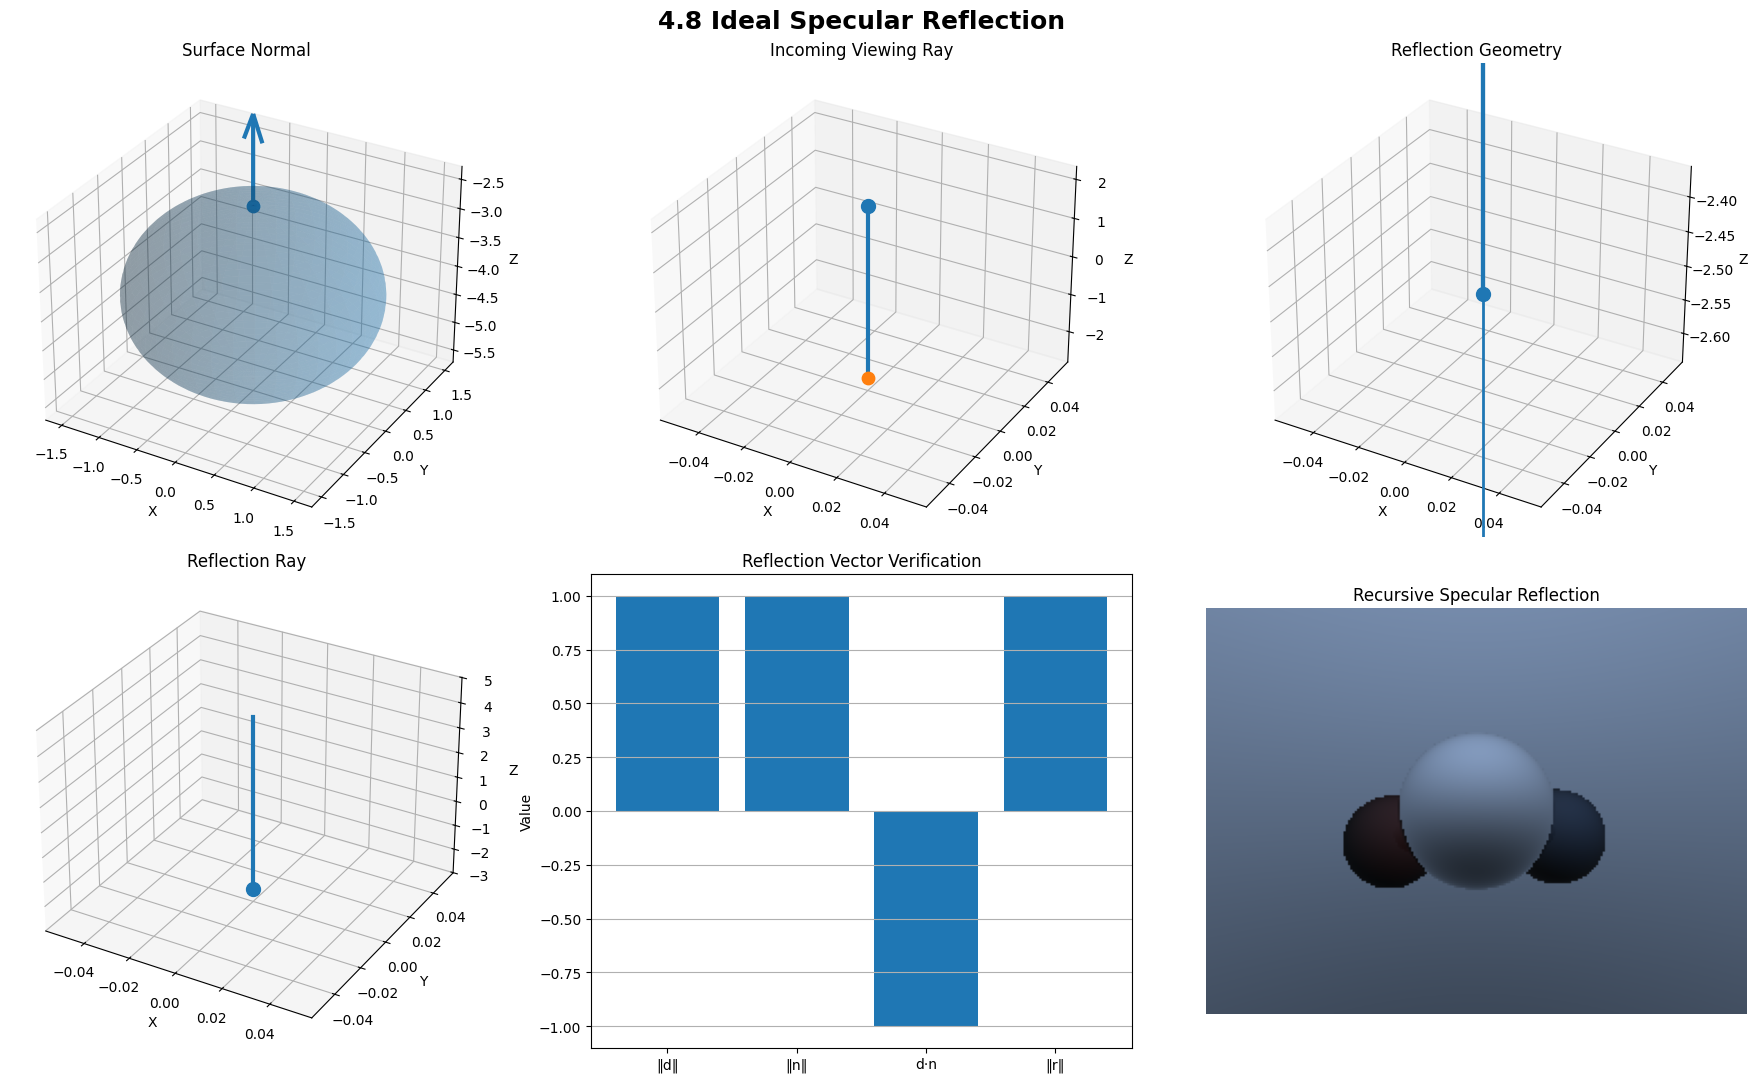

IDEAL SPECULAR REFLECTION

Incoming direction d:
[ 0.  0. -1.]

Surface normal n:
[0. 0. 1.]

Reflection direction r:
[0. 0. 1.]

Vector magnitudes:
||d|| = 1.000000
||n|| = 1.000000
||r|| = 1.000000

d · n:
-1.000000

Reflection equation:
r = d - 2(d · n)n

Maximum recursion depth:
3

Reflection ray:
p + εr + sr

Conclusion:
The reflected direction is normalized and follows the ideal mirror-reflection equation.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 4.8 IDEAL SPECULAR REFLECTION
#
# Reflection equation:
#
#       r = d - 2(d · n)n
#
# Reflection ray:
#
#       p(s) = p + s r
#
# The implementation demonstrates:
#   1. Surface geometry
#   2. Incoming viewing ray
#   3. Surface normal
#   4. Reflection direction
#   5. Reflection ray
#   6. Ray-sphere intersection
#   7. Recursive reflection
#   8. Reflected image
# ==========================================================


# ==========================================================
# VECTOR UTILITIES
# ==========================================================

def normalize(v):

    norm = np.linalg.norm(v)

    if norm == 0:
        return v

    return v / norm


def reflect(d, n):

    return d - 2 * np.dot(d, n) * n


# ==========================================================
# RAY-SPHERE INTERSECTION
# ==========================================================

def ray_sphere_intersection(
    origin,
    direction,
    center,
    radius,
    t_min=1e-4,
    t_max=np.inf
):

    oc = origin - center

    A = np.dot(direction, direction)

    B = 2 * np.dot(
        direction,
        oc
    )

    C = (
        np.dot(oc, oc)
        - radius ** 2
    )

    discriminant = (
        B ** 2
        - 4 * A * C
    )

    if discriminant < 0:

        return None

    sqrt_d = np.sqrt(discriminant)

    t1 = (
        -B - sqrt_d
    ) / (2 * A)

    t2 = (
        -B + sqrt_d
    ) / (2 * A)

    candidates = [
        t
        for t in (t1, t2)
        if t_min <= t <= t_max
    ]

    if not candidates:

        return None

    return min(candidates)


# ==========================================================
# SCENE
# ==========================================================

objects = [

    {
        "center": np.array([0.0, 0.0, -4.0]),
        "radius": 1.5,
        "color": np.array([0.75, 0.75, 0.78]),
        "reflection": np.array([0.9, 0.9, 0.9])
    },

    {
        "center": np.array([-2.2, -0.8, -6.0]),
        "radius": 1.2,
        "color": np.array([0.75, 0.25, 0.25]),
        "reflection": np.array([0.15, 0.15, 0.15])
    },

    {
        "center": np.array([2.2, -0.7, -6.5]),
        "radius": 1.3,
        "color": np.array([0.25, 0.45, 0.8]),
        "reflection": np.array([0.2, 0.2, 0.2])
    }
]


# ==========================================================
# LIGHT SOURCE
# ==========================================================

light_position = np.array([
    4.0,
    5.0,
    2.0
])

light_intensity = 1.0


# ==========================================================
# CAMERA
# ==========================================================

camera = np.array([
    0.0,
    0.0,
    2.0
])

image_width = 240
image_height = 180

focal_length = 1.5

max_depth = 3

epsilon = 1e-4


# ==========================================================
# SCENE INTERSECTION
# ==========================================================

def closest_intersection(
    origin,
    direction,
    t_min=epsilon,
    t_max=np.inf
):

    closest_t = t_max
    hit_object = None

    for obj in objects:

        t = ray_sphere_intersection(
            origin,
            direction,
            obj["center"],
            obj["radius"],
            t_min,
            closest_t
        )

        if t is not None:

            closest_t = t
            hit_object = obj

    if hit_object is None:

        return None

    point = (
        origin
        + closest_t * direction
    )

    normal = normalize(
        point
        - hit_object["center"]
    )

    return (
        closest_t,
        point,
        normal,
        hit_object
    )


# ==========================================================
# LOCAL DIFFUSE ILLUMINATION
# ==========================================================

def diffuse_lighting(
    point,
    normal,
    surface_color
):

    light_vector = (
        light_position
        - point
    )

    light_distance = np.linalg.norm(
        light_vector
    )

    light_direction = normalize(
        light_vector
    )

    intensity = max(
        0.0,
        np.dot(
            normal,
            light_direction
        )
    )

    attenuation = 1.0 / (
        1.0
        + 0.05 * light_distance ** 2
    )

    return (
        surface_color
        * light_intensity
        * intensity
        * attenuation
    )


# ==========================================================
# BACKGROUND
# ==========================================================

def background_color(direction):

    t = 0.5 * (
        direction[1] + 1.0
    )

    return (
        (1 - t)
        * np.array([0.15, 0.18, 0.22])
        +
        t
        * np.array([0.55, 0.65, 0.80])
    )


# ==========================================================
# RECURSIVE RAY COLOR
# ==========================================================

def ray_color(
    origin,
    direction,
    depth
):

    hit = closest_intersection(
        origin,
        direction
    )

    if hit is None:

        return background_color(
            direction
        )

    t, point, normal, obj = hit

    # ------------------------------------------------------
    # Local surface illumination
    # ------------------------------------------------------

    local_color = diffuse_lighting(
        point,
        normal,
        obj["color"]
    )

    # ------------------------------------------------------
    # Reflection termination
    # ------------------------------------------------------

    if (
        depth >= max_depth
        or
        np.max(obj["reflection"]) <= 0
    ):

        return local_color

    # ------------------------------------------------------
    # Reflection direction
    #
    # r = d - 2(d · n)n
    # ------------------------------------------------------

    reflection_direction = normalize(
        reflect(
            direction,
            normal
        )
    )

    # ------------------------------------------------------
    # Offset ray origin to avoid self-intersection
    # ------------------------------------------------------

    reflection_origin = (
        point
        + epsilon
        * reflection_direction
    )

    # ------------------------------------------------------
    # Recursive reflection
    # ------------------------------------------------------

    reflected_color = ray_color(
        reflection_origin,
        reflection_direction,
        depth + 1
    )

    return (
        local_color
        * (1 - obj["reflection"])
        +
        reflected_color
        * obj["reflection"]
    )


# ==========================================================
# RENDER IMAGE
# ==========================================================

image = np.zeros(
    (
        image_height,
        image_width,
        3
    )
)


aspect_ratio = (
    image_width
    / image_height
)


for y in range(
    image_height
):

    for x in range(
        image_width
    ):

        u = (
            (x + 0.5)
            / image_width
            * 2
            - 1
        )

        v = (
            (y + 0.5)
            / image_height
            * 2
            - 1
        )

        u *= aspect_ratio

        pixel_point = np.array([
            u,
            v,
            camera[2]
            - focal_length
        ])

        direction = normalize(
            pixel_point
            - camera
        )

        image[
            image_height - 1 - y,
            x
        ] = ray_color(
            camera,
            direction,
            0
        )


image = np.clip(
    image,
    0,
    1
)


# ==========================================================
# SELECT A REPRESENTATIVE SURFACE
# ==========================================================

target = objects[0]

surface_point = np.array([
    0.0,
    0.0,
    -2.5
])

surface_normal = normalize(
    surface_point
    - target["center"]
)

incoming_direction = normalize(
    surface_point
    - camera
)

reflection_direction = normalize(
    reflect(
        incoming_direction,
        surface_normal
    )
)

reflection_origin = (
    surface_point
    + epsilon
    * reflection_direction
)


# ==========================================================
# REFLECTION INTERSECTION
# ==========================================================

reflection_hit = closest_intersection(
    reflection_origin,
    reflection_direction
)


if reflection_hit is not None:

    reflection_t = reflection_hit[0]

    reflection_point = reflection_hit[1]

else:

    reflection_t = None
    reflection_point = None


# ==========================================================
# VISUALIZATION
# ==========================================================

fig = plt.figure(
    figsize=(18, 11)
)


# ==========================================================
# 1. SURFACE AND NORMAL
# ==========================================================

ax1 = plt.subplot(
    2,
    3,
    1,
    projection="3d"
)

sphere_center = target["center"]
radius = target["radius"]

phi = np.linspace(
    0,
    np.pi,
    50
)

theta = np.linspace(
    0,
    2 * np.pi,
    80
)

sx = (
    sphere_center[0]
    + radius
    * np.outer(
        np.sin(phi),
        np.cos(theta)
    )
)

sy = (
    sphere_center[1]
    + radius
    * np.outer(
        np.sin(phi),
        np.sin(theta)
    )
)

sz = (
    sphere_center[2]
    + radius
    * np.outer(
        np.cos(phi),
        np.ones_like(theta)
    )
)

ax1.plot_surface(
    sx,
    sy,
    sz,
    alpha=0.25
)

ax1.scatter(
    *surface_point,
    s=80
)

ax1.quiver(
    *surface_point,
    *surface_normal,
    length=1.5,
    linewidth=3
)

ax1.set_title(
    "Surface Normal"
)

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")


# ==========================================================
# 2. INCOMING VIEWING RAY
# ==========================================================

ax2 = plt.subplot(
    2,
    3,
    2,
    projection="3d"
)

incoming_path = np.array([
    camera,
    surface_point
])

ax2.plot(
    incoming_path[:, 0],
    incoming_path[:, 1],
    incoming_path[:, 2],
    linewidth=3
)

ax2.scatter(
    *camera,
    s=100
)

ax2.scatter(
    *surface_point,
    s=80
)

ax2.set_title(
    "Incoming Viewing Ray"
)

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")


# ==========================================================
# 3. REFLECTION GEOMETRY
# ==========================================================

ax3 = plt.subplot(
    2,
    3,
    3,
    projection="3d"
)

ax3.scatter(
    *surface_point,
    s=100
)

ax3.quiver(
    *surface_point,
    *incoming_direction,
    length=1.5,
    linewidth=2
)

ax3.quiver(
    *surface_point,
    *surface_normal,
    length=1.5,
    linewidth=3
)

ax3.quiver(
    *surface_point,
    *reflection_direction,
    length=2.5,
    linewidth=3
)

ax3.set_title(
    "Reflection Geometry"
)

ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")


# ==========================================================
# 4. REFLECTION RAY
# ==========================================================

ax4 = plt.subplot(
    2,
    3,
    4,
    projection="3d"
)

reflection_end = (
    reflection_origin
    + 7
    * reflection_direction
)

reflection_path = np.array([
    surface_point,
    reflection_end
])

ax4.plot(
    reflection_path[:, 0],
    reflection_path[:, 1],
    reflection_path[:, 2],
    linewidth=3
)

ax4.scatter(
    *surface_point,
    s=100
)

if reflection_point is not None:

    ax4.scatter(
        *reflection_point,
        s=100
    )

ax4.set_title(
    "Reflection Ray"
)

ax4.set_xlabel("X")
ax4.set_ylabel("Y")
ax4.set_zlabel("Z")


# ==========================================================
# 5. NUMERICAL VERIFICATION
# ==========================================================

ax5 = plt.subplot(
    2,
    3,
    5
)

labels = [
    "‖d‖",
    "‖n‖",
    "d·n",
    "‖r‖"
]

values = [
    np.linalg.norm(
        incoming_direction
    ),
    np.linalg.norm(
        surface_normal
    ),
    np.dot(
        incoming_direction,
        surface_normal
    ),
    np.linalg.norm(
        reflection_direction
    )
]

ax5.bar(
    labels,
    values
)

ax5.set_title(
    "Reflection Vector Verification"
)

ax5.set_ylabel(
    "Value"
)

ax5.grid(
    axis="y"
)


# ==========================================================
# 6. RENDERED IMAGE
# ==========================================================

ax6 = plt.subplot(
    2,
    3,
    6
)

ax6.imshow(
    image
)

ax6.set_title(
    "Recursive Specular Reflection"
)

ax6.axis(
    "off"
)


# ==========================================================
# FINAL LAYOUT
# ==========================================================

plt.suptitle(
    "4.8 Ideal Specular Reflection",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ==========================================================
# NUMERICAL RESULTS
# ==========================================================

print("=" * 70)
print("IDEAL SPECULAR REFLECTION")
print("=" * 70)

print("\nIncoming direction d:")
print(
    np.round(
        incoming_direction,
        5
    )
)

print("\nSurface normal n:")
print(
    np.round(
        surface_normal,
        5
    )
)

print("\nReflection direction r:")
print(
    np.round(
        reflection_direction,
        5
    )
)

print("\nVector magnitudes:")
print(
    f"||d|| = "
    f"{np.linalg.norm(incoming_direction):.6f}"
)

print(
    f"||n|| = "
    f"{np.linalg.norm(surface_normal):.6f}"
)

print(
    f"||r|| = "
    f"{np.linalg.norm(reflection_direction):.6f}"
)

print("\nd · n:")
print(
    f"{np.dot(incoming_direction, surface_normal):.6f}"
)

print("\nReflection equation:")
print(
    "r = d - 2(d · n)n"
)

print("\nMaximum recursion depth:")
print(max_depth)

print("\nReflection ray:")
print(
    "p + εr + sr"
)

print("\nConclusion:")

if (
    abs(
        np.linalg.norm(
            reflection_direction
        ) - 1
    ) < 1e-10
):

    print(
        "The reflected direction is normalized "
        "and follows the ideal mirror-reflection equation."
    )

else:

    print(
        "The reflected direction requires normalization."
    )

## **4.9 Historical Notes**

Ray tracing is one of the early techniques developed in **computer graphics**. The basic idea was introduced by **Appel (1968)**, but ray tracing was not widely used initially because computers did not have enough **computational power**.

Later developments made ray tracing increasingly practical:

- **Appel (1968)** — early development of ray tracing.
- **Kay & Greenberg (1979)** — contributed to practical ray-tracing techniques.
- **Whitted (1980)** — demonstrated important extensions such as **recursive reflection and refraction**.
- Later research developed increasingly **efficient ray-tracing implementations**.

Ray tracing was traditionally regarded as an **offline rendering technique** because producing an image could require substantial computation.

With improvements in:

- **processor performance**
- **graphics hardware**
- **acceleration structures**
- **ray-tracing algorithms**

**real-time ray tracing** has become increasingly practical.

### **Key Idea**

$$
\boxed{
\text{Early Ray Tracing}
\rightarrow
\text{High Computational Cost}
\rightarrow
\text{More Computing Power}
\rightarrow
\text{Real-Time Ray Tracing}
}
$$

Ray tracing has therefore evolved from primarily an **offline rendering method** into a technique that can also support **interactive and real-time graphics**.

## **Frequently Asked Questions**

### **1. Why Is There No Perspective Matrix in Ray Tracing?**

In a **z-buffer rendering system**, a perspective matrix is used to transform perspective projection into a form that can be handled by the rendering pipeline.

Ray tracing does **not** need this transformation.

Instead, perspective is produced **directly by generating rays from the viewpoint**. Rays for different pixels spread outward from the eye:

$$
\boxed{
\text{Perspective in Ray Tracing}
=
\text{Rays Fan Outward from the Eye}
}
$$

Therefore, a separate **perspective matrix is unnecessary**.

---

### **2. Can Ray Tracing Be Made Interactive?**

**Yes.**

For sufficiently small scenes and images, modern computers can perform ray tracing **interactively**. More complex scenes and full-screen rendering require significantly more computational power.

The important factor is the increasing performance of:

- **CPUs**
- **GPUs**
- **parallel processors**
- **ray-tracing acceleration structures**

Therefore, ray tracing has progressed from primarily **offline rendering** toward **interactive and real-time rendering**.

---

### **3. Is Ray Tracing Useful in a Hardware Graphics Program?**

**Yes.**

A common application is **picking**.

When a user clicks a pixel in a 3D graphics application, the program needs to determine:

**Which 3D object is visible at this pixel?**

A ray can be generated from the camera through the selected pixel. The **first object intersected by that ray** is the object visible at that location.

$$
\boxed{
\text{Mouse Click}
\rightarrow
\text{Viewing Ray}
\rightarrow
\text{Closest Intersection}
\rightarrow
\text{Selected Object}
}
$$

---

# **Exercises**

### **1. Ray–Sphere Intersection**

Find the ray parameters $t$ for the intersection points between

$$
p(t)=(1,1,1)+t(-1,-1,-1)
$$

and a sphere centered at

$$
c=(0,0,0)
$$

with radius

$$
R=1
$$

Use the **ray-sphere equation** from **Section 4.4.1**.

---

### **2. Ray–Triangle Intersection**

Find the **barycentric coordinates** $\beta,\gamma$ and ray parameter $t$ where

$$
p(t)=(1,1,1)+t(-1,-1,-1)
$$

intersects the triangle with vertices

$$
a=(1,0,0),\qquad b=(0,1,0),\qquad c=(0,0,1)
$$

Use the ray-triangle equation:

$$
e+td=a+\beta(b-a)+\gamma(c-a)
$$

Then verify that the intersection is inside the triangle using:

$$
\beta>0,\qquad \gamma>0,\qquad \beta+\gamma<1
$$

---

### **3. Time Complexity of Ray Tracing**

Estimate the approximate **time complexity of ray tracing** for a **nice, non-adversarial model**.

Separate the analysis into:

### **A. Preprocessing**

Consider the cost of constructing **acceleration structures** such as bounding-volume hierarchies.

### **B. Image Computation**

Consider the cost of tracing rays through the scene and finding intersections.

Then consider a **static scene rendered for multiple frames**. The preprocessing structure can be reused, so the preprocessing cost does not need to be repeated for every frame.

The important distinction is:

$$
\boxed{
\text{Total Cost}
=
\text{Preprocessing}
+
\text{Per-frame Rendering}
}
$$

For a static model:

$$
\boxed{
\text{Multiple Frames}
=
\text{One Preprocessing Cost}
+
\text{Repeated Image-Rendering Costs}
}
$$